In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time


In [2]:
from numba import jit
from numba import njit, prange
from numba.typed import Dict
from numba.core import types
import scipy.sparse as sp
@jit(nopython=True)
def SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters, edges, triangles, fixed_init, t_max, check_interval=100, variance_threshold=1e-4):
    I_runs = []
    S_runs=[]
    times_runs = []
    
    for h in range(iters):
        indddd = fixed_init[h]
        Infected = np.zeros(N)
        Infected[indddd] = 1

        t = 0
        times = [0]
        I = [np.sum(Infected)]
        S=[N-np.sum(Infected)]

        rate_vec = np.zeros(N)

        while t < t_max:
            # Update rate_vec
            rate_vec.fill(0)
            for edge in edges:
                v1, v2 = edge
                if Infected[v1] == 0 and Infected[v2] == 1:
                    rate_vec[v1] += beta1
                elif Infected[v2] == 0 and Infected[v1] == 1:
                    rate_vec[v2] += beta1

            for triangle in triangles:
                n1, n2, n3 = triangle
                if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                    rate_vec[n1] += beta2
                elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                    rate_vec[n2] += beta2
                elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                    rate_vec[n3] += beta2

            rate_vec[Infected == 1] += mu

            total_rate = np.sum(rate_vec)
            if total_rate == 0:
                break

            delay = np.random.exponential(1.0 / total_rate)
            t += delay

            rr = np.random.random()
            cumulative_rate = 0
            for i in range(N):
                cumulative_rate += rate_vec[i] / total_rate
                if rr < cumulative_rate:
                    if Infected[i] == 1:
                        Infected[i] = 0
                    elif Infected[i] == 0:
                        Infected[i] = 1
                    break

            I.append(np.sum(Infected))
            S.append(N-np.sum(Infected))
            times.append(t)

            # Early stopping condition to check for stationarity
            if len(I) > check_interval:
                recent_values = np.array(I[-check_interval:])/N
                variance = np.var(recent_values)
                if variance < variance_threshold:
                    break
        
        I_runs.append(I)
        times_runs.append(times)
        S_runs.append(S)
    return times_runs, I_runs, S_runs





In [3]:
import numpy as np
import numba
from collections import defaultdict
from numba import njit, prange
from numba.typed import Dict
from numba.core import types
import scipy.sparse as sp
import random

def degree_per_node_list(hyperedges, nodes):
    """Optimized degree calculation with pre-allocated arrays"""
    max_order = max(len(edge) for edge in hyperedges)
    node_max = max(nodes)
    
    # Pre-allocate arrays instead of using defaultdicts
    degree_arrays = [np.zeros(node_max + 1, dtype=np.int32) for _ in range(max_order)]
    
    for edge in hyperedges:
        order_index = len(edge) - 1
        for node in edge:
            degree_arrays[order_index][node] += 1
    
    # Convert to dictionaries only for nodes in the list
    return [{node: degree_arrays[i][node] for node in nodes} for i in range(max_order)]

@njit
def perfect_hash_5d(s, i, x, y, z, max_dims):
    """Perfect hash function for 5D states - eliminates collisions"""
    return (s + 
            i * max_dims[0] + 
            x * max_dims[0] * max_dims[1] + 
            y * max_dims[0] * max_dims[1] * max_dims[2] + 
            z * max_dims[0] * max_dims[1] * max_dims[2] * max_dims[3])

@njit
def create_perfect_hash_map(states_array):
    """Create collision-free hash map with dimension bounds"""
    # Calculate max dimensions for perfect hashing
    max_dims = np.zeros(5, dtype=np.int64)
    for i in range(len(states_array)):
        for j in range(5):
            if states_array[i, j] > max_dims[j]:
                max_dims[j] = states_array[i, j]
    
    # Add 1 to include zero values
    max_dims += 1
    
    # Create hash map
    hash_map = numba.typed.Dict.empty(
        key_type=numba.types.int64,
        value_type=numba.types.int64
    )
    
    for i in range(len(states_array)):
        s, ii, x, y, z = states_array[i]
        hash_key = perfect_hash_5d(s, ii, x, y, z, max_dims)
        hash_map[hash_key] = i
    
    return hash_map, max_dims

@njit
def find_state_fast(s, i, x, y, z, hash_map, values_array, max_dims):
    """O(1) state lookup with perfect hashing"""
    if s < 0 or i < 0 or x < 0 or y < 0 or z < 0:
        return 0.0
    
    hash_key = perfect_hash_5d(s, i, x, y, z, max_dims)
    if hash_key in hash_map:
        return values_array[hash_map[hash_key]]
    return 0.0

@njit
def motifs_eff_degree_optimized(S_states, S_values, I_states, I_values, S_hash_map, I_hash_map, S_max_dims, I_max_dims):
    """Heavily optimized motif calculation with early exit and vectorization"""
    # Pre-allocate all variables
    SS = IS = II = 0.0
    SSS = ISS = ISI = SIS = III = 0.0
    ISS2=0.0
    I_S_S = II_S_S = I_S_SS = II_S_SS = 0.0
    I_S_SI = II_S_SI = I_S_I = II_S_I = II_S_II = 0.0
    
    max_s=0
    #print(max_s)
    # Process susceptible nodes
    for idx in range(len(S_states)):
        s, i, x, y, z = S_states[idx]
        if s>max_s: 
            max_s=s
        count = find_state_fast(s, i, x, y, z, S_hash_map, S_values, S_max_dims)
        
        if count < 1e-12:  # Skip negligible values
            continue
        #if count>N
        # Update basic counts
        SS += s * count
        IS += i * count
        SSS += x * count
        SIS += y * count
        ISI += z * count
        # Update complex motif counts
        I_S_S += i * s * count
        II_S_S += z * s * count
        I_S_SS += i * x * count
        II_S_SS += z * x * count
        I_S_SI += i * y * count
        II_S_SI += z * y * count
        
        if i > 0:
            I_S_I += i * (i-1) * count
            
        II_S_I += z * i * count
        if z > 0:
            II_S_II += z * (z-1) * count
    
    # Process infected nodes


    #print('I_S_S',I_S_S,'SS', SS)
    #print(max_s)
    # Calculate normalized frequencies
    


    for idx in range(len(I_states)):
        s, i, x, y, z = I_states[idx]
        count = find_state_fast(s, i, x, y, z, I_hash_map, I_values, I_max_dims)
        
        if count < 1e-12:
            continue

        #ISS += x * count
        
        II += i * count
        III += z * count
        ISS+= x * count

    # Safe division with individual calculations
    threshold_denom = 1e-12
    
    A = I_S_S / SS if SS > threshold_denom else 0.0
    B = II_S_S / SS if SS > threshold_denom else 0.0
    C = I_S_SS / SSS if SSS > threshold_denom else 0.0
    D = II_S_SS / SSS if SSS > threshold_denom else 0.0
    E = I_S_SI / SIS if SIS > threshold_denom else 0.0
    F = II_S_SI / SIS if SIS > threshold_denom else 0.0
    
    E2 = I_S_SI / ISS if ISS > threshold_denom else 0.0
    F2 = II_S_SI / ISS if ISS > threshold_denom else 0.0
    G = I_S_I / IS if IS > threshold_denom else 0.0
    H = II_S_I / IS if IS > threshold_denom else 0.0
    J = II_S_I / ISI if ISI > threshold_denom else 0.0
    K = II_S_II / ISI if ISI > threshold_denom else 0.0

    motifs1 = SS, IS, II, SSS, ISS, SIS, ISI, III 

    motifs2 = A, B, C, D, E, F, E2, F2,  G, H, J, K
    return motifs1,motifs2

@njit
def compute_derivatives_ultra_fast(S_states, S_values, I_states, I_values, 
                                 S_hash_map, I_hash_map, S_max_dims, I_max_dims,
                                 motifs, para):
    """Ultra-optimized derivative computation with perfect hashing"""
    b1, b2, gamma = para
    motifs1, motifs2 = motifs
    A, B, C, D, E, F, E2, F2,  G, H, J, K = motifs2
    
    dS_values = np.zeros_like(S_values)
    dI_values = np.zeros_like(I_values)
    
    # Precompute common terms
    b1_A_plus_b2_B = b1 * A + b2 * B
    b1_C_plus_b2_D = b1 * C + b2 * D
    b1_2E_plus_b2_2F = 2*(b1 * E + b2 *  F)
    b1_plus_b1_G_plus_b2_H = b1 + b1 * G + b2 * H
    b1_E_half_plus_b2_F_half = 0.5*(b1 * E2  + b2 * F2)
    b2_plus_b1_J_plus_b2_K = b2 + b1 * J + b2 *  K
    
    # Process S states with vectorization
    for idx in prange(len(S_states)):
        s, i, x, y, z = S_states[idx]
        S_curr = S_values[idx]
        
        
        I_curr = find_state_fast(s, i, x, y, z, I_hash_map, I_values, I_max_dims)
        
        # Batch neighbor lookups
        S1 = find_state_fast(s + 1, i - 1, x, y, z, S_hash_map, S_values, S_max_dims) if i > 0 else 0.0
        S2 = find_state_fast(s - 1, i + 1, x, y, z, S_hash_map, S_values, S_max_dims) if s > 0 else 0.0
        S3 = find_state_fast(s, i, x + 1, y - 1, z, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        S4 = find_state_fast(s, i, x - 1, y + 1, z, S_hash_map, S_values, S_max_dims) if x > 0 else 0.0
        S5 = find_state_fast(s, i, x, y + 1, z - 1, S_hash_map, S_values, S_max_dims) if z > 0 else 0.0
        S6 = find_state_fast(s, i, x, y - 1, z + 1, S_hash_map, S_values, S_max_dims) if y > 0 else 0.0
        
               # Compute derivative
        dS_values[idx] = (-(b1 * i + b2 * z) * S_curr + gamma * I_curr +
                         (b1_A_plus_b2_B) * ((s + 1) * S1 - s * S_curr) +
                         (b1_C_plus_b2_D) * ((x + 1) * S3 - x * S_curr) +
                         (b1_2E_plus_b2_2F) * ((y + 1) * S5 - y * S_curr) +
                         gamma * (-(i + y + 2 * z) * S_curr + (i + 1) * S2 + (y + 1) * S4 + 2 * (z + 1) * S6))
    # Process I states similarly
    for idx in prange(len(I_states)):
        s, i, x, y, z = I_states[idx]
        I_curr = I_values[idx]
        
        S_curr = find_state_fast(s, i, x, y, z, S_hash_map, S_values, S_max_dims)
        
        # Batch neighbor lookups for I states
        I1 = find_state_fast(s + 1, i - 1, x, y, z, I_hash_map, I_values, I_max_dims) if i > 0 else 0.0
        I2 = find_state_fast(s - 1, i + 1, x, y, z, I_hash_map, I_values, I_max_dims) if s > 0 else 0.0
        I3 = find_state_fast(s, i, x + 1, y - 1, z, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        I4 = find_state_fast(s, i, x - 1, y + 1, z, I_hash_map, I_values, I_max_dims) if x > 0 else 0.0
        I5 = find_state_fast(s, i, x, y + 1, z - 1, I_hash_map, I_values, I_max_dims) if z > 0 else 0.0
        I6 = find_state_fast(s, i, x, y - 1, z + 1, I_hash_map, I_values, I_max_dims) if y > 0 else 0.0
        
        
        dI_values[idx] = ((b1 * i + b2 * z) * S_curr - gamma * I_curr +
                         (b1_plus_b1_G_plus_b2_H) * ((s + 1) * I1 - s * I_curr) +
                         (b1_E_half_plus_b2_F_half) * ((x + 1) * I3 - x * I_curr) +
                         (b2_plus_b1_J_plus_b2_K) * ((y + 1) * I5 - y * I_curr) +
                         gamma * (-(i + y + 2 * z) * I_curr + (i + 1) * I2 + (y + 1) * I4 + 2 * (z + 1) * I6))
    
    
    return dS_values, dI_values

@njit
def adaptive_timestep(S_values, I_values, dS_values, dI_values, dt_current, 
                     tolerance=1e-6, max_dt=0.01, min_dt=1e-8):
    """Adaptive timestep control for numerical stability"""
    # Calculate relative changes
    max_rel_change = 0.0
    
    for i in range(len(S_values)):
        if S_values[i] > tolerance:
            rel_change = abs(dS_values[i] * dt_current / S_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    for i in range(len(I_values)):
        if I_values[i] > tolerance:
            rel_change = abs(dI_values[i] * dt_current / I_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Adjust timestep
    if max_rel_change > 0.1:  # Too fast
        dt_new = max(dt_current * 0.5, min_dt)
    elif max_rel_change < 0.01:  # Too slow
        dt_new = min(dt_current * 1.2, max_dt)
    else:
        dt_new = dt_current
    
    return dt_new

def dict_to_arrays_optimized(state_dict):
    """Optimized dictionary to array conversion"""
    if not state_dict:
        return np.empty((0, 5), dtype=np.int32), np.empty(0, dtype=np.float64)
    
    n_states = len(state_dict)
    states_array = np.empty((n_states, 5), dtype=np.int32)
    values_array = np.empty(n_states, dtype=np.float64)
    
    for i, (state, value) in enumerate(state_dict.items()):
        states_array[i] = state
        values_array[i] = value
    
    return states_array, values_array

def X_si_xyz_from_degree_list_fast(degree_node, node_list):
    """Fast state space generation"""
    S_si_xyz = {}
    I_si_xyz = {}
    
    for node in node_list:
        k1 = degree_node[1].get(node, 0)
        k2 = degree_node[2].get(node, 0)
        
        for i in range(k1 + 1):
            s = k1 - i
            for j in range(k2 + 1):
                for j_ in range(j + 1):
                    x = k2 - j
                    y = j - j_
                    z = j_
                    key = (s, i, x, y, z)
                    S_si_xyz[key] = 0
                    I_si_xyz[key] = 0
    
    return S_si_xyz, I_si_xyz


def initial_states_fast(initial_infec, node_list, degree_node, edges_node):
    """Calculate initial states - no changes needed as this runs once"""
    state_node = {
        node: 'I' if node in initial_infec else 'S' 
        for node in node_list
    }
    
    S_si_xyz, I_si_xyz = X_si_xyz_from_degree_list(degree_node, node_list)
    
    for state in S_si_xyz:
        S_si_xyz[state] = 0
    for state in I_si_xyz:
        I_si_xyz[state] = 0
    
    for node in node_list:
        s = i = x = y = z = 0
        
        for neigh in edges_node[node]:
            if len(neigh) == 1:
                v1 = neigh[0]
                if state_node[v1] == 'I':
                    i += 1
                elif state_node[v1] == 'S':
                    s += 1
            elif len(neigh) == 2:
                v1, v2 = neigh[0], neigh[1]
                
                if state_node[v1] == 'S' and state_node[v2] == 'S':
                    x += 1
                elif (state_node[v1] == 'S' and state_node[v2] == 'I') or (state_node[v2] == 'S' and state_node[v1] == 'I'):
                    y += 1
                elif state_node[v1] == 'I' and state_node[v2] == 'I':
                    z += 1
        
        neigh_state = (s, i, x, y, z)
        
        if state_node[node] == 'I':
            I_si_xyz[neigh_state] = I_si_xyz.get(neigh_state, 0) + 1
        elif state_node[node] == 'S':
            S_si_xyz[neigh_state] = S_si_xyz.get(neigh_state, 0) + 1
    
    return state_node, S_si_xyz, I_si_xyz

def X_si_xyz_from_degree_list(degree_node, node_list):
    """
    Given degree information (as from `degree_per_node_list`) and a list of nodes,
    returns dictionaries S_si_xyz and I_si_xyz.
    """
    S_si_xyz = {}
    I_si_xyz = {}

    for node in node_list:
        k1 = degree_node[1][node]  # degree from pairwise (order-2) interactions
        k2 = degree_node[2][node]  # degree from 3-node (order-3) interactions

        for i in range(k1 + 1):
            s = k1 - i
            for j in range(k2 + 1):
                for j_ in range(j + 1):
                    x = k2 - j
                    y = j - j_
                    z = j_
                    key = (s, i, x, y, z)
                    if key not in S_si_xyz:
                        S_si_xyz[key] = 0
                        I_si_xyz[key] = 0

    return S_si_xyz, I_si_xyz

def odeint_effective_degree_HO_ultra_optimized(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=None, complete=True):
    """
    Ultra-optimized version with perfect hashing, adaptive timesteps, and vectorization.
    
    Key optimizations:
    1. Perfect hash functions eliminate collisions
    2. Parallel processing with prange
    3. Adaptive timestep control
    4. Vectorized operations
    5. Early exit conditions
    6. Memory-efficient data structures
    """
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Optimized hyperedge processing
    edges_node = defaultdict(list)
    for edge in hyper_edge_list:
        edge_list = list(edge)
        for node in edge:
            neighbors = [n for n in edge_list if n != node]
            edges_node[int(node)].append(neighbors)
    
    # Convert to regular dict for better performance
    edges_node = dict(edges_node)
    for node in node_list:
        if node not in edges_node:
            edges_node[node] = []
    
    # Optimized degree calculation
    degree_node = degree_per_node_list(hyper_edge_list, node_list)
    
    # Initialize infected nodes
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Calculate initial states using the helper functions
    state_node, S_si_xyz, I_si_xyz = initial_states_fast(initial_infected, node_list, degree_node, edges_node)
    print(len(S_si_xyz))
    print('-------')
    print(len(I_si_xyz))
    # Convert to optimized arrays
    S_states, S_values = dict_to_arrays_optimized(S_si_xyz)
    I_states, I_values = dict_to_arrays_optimized(I_si_xyz)
    
    # Create perfect hash maps
    S_hash_map, S_max_dims = create_perfect_hash_map(S_states)
    I_hash_map, I_max_dims = create_perfect_hash_map(I_states)
    
    # Convert parameters
    para_array = np.array(para, dtype=np.float64)
    
    # Initialize time series
    times = [0.0]
    S_t = [float(N - len(initial_infected))]
    I_t = [float(len(initial_infected))]
    
    # Integration with adaptive timestep
    current_time = 0.0
    dt = dt_initial
    step = 0
    max_steps = steps_ode * 10  # Allow more steps with adaptive dt
    Motifs_time=[]
    print("Starting ultra-optimized integration...")
    
    while current_time < T and step < max_steps:
        # Calculate motifs
        motifs = motifs_eff_degree_optimized(S_states, S_values, I_states, I_values, S_hash_map, I_hash_map, S_max_dims, I_max_dims)

        motifs1, motifs2 = motifs
        
        # Compute derivatives
        dS_values, dI_values = compute_derivatives_ultra_fast(
            S_states, S_values, I_states, I_values,
            S_hash_map, I_hash_map, S_max_dims, I_max_dims,
            motifs, para_array
        )
        
        # Adaptive timestep
        if adaptive_dt and step > 0:
            dt = adaptive_timestep(S_values, I_values, dS_values, dI_values, dt)
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update states
        S_values = S_values + dt * dS_values
        I_values = I_values +  dt * dI_values
        
        current_time += dt
        step += 1
        

        S_total = np.sum(S_values)
        I_total = np.sum(I_values)
        
        times.append(current_time)
        S_t.append(S_total)
        I_t.append(I_total)
        #Motifs_time.append(motifs1)
            # Progress reporting
        if progress_callback:
            progress_callback(current_time / T * 100)
        elif step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% (t={current_time:.3f}, dt={dt:.6f})")
            
            # Early termination checks
        if I_total < 1e-6:  # Infection died out
            print("Infection died out, terminating early")
            break
        if I_total > N * 1.1:  # Numerical instability
            print("Numerical instability detected, terminating")
            return []
    
    print(f"Integration completed in {step} steps")
    return times, S_t, I_t#, Motifs_time

# Backward compatibility wrapper
def odeint_effective_degree_HO_optimized(para, hyper_edge_list, N, initial_infected=None, 
                                       T=15, steps_ode=2000, use_numba=True, use_fast_derivatives=True):
    """Wrapper for backward compatibility"""
    return odeint_effective_degree_HO_ultra_optimized(
        para, hyper_edge_list, N, initial_infected, T, steps_ode, 
        adaptive_dt=use_fast_derivatives
    )

In [17]:
"""
High-Performance Epidemiological Simulation on Hypergraphs
==========================================================

This module implements a Numba-optimized epidemiological simulation using hypergraphs
to model disease spread through higher-order interactions (groups of 2+ individuals).

The model uses a degree-based mean-field approach with JIT compilation for maximum
performance on SIS (Susceptible-Infected-Susceptible) dynamics.

Key Performance Features:
- Numba JIT compilation for critical functions
- Optimized data structures using typed dictionaries and arrays
- Parallel processing where applicable
- Memory-efficient degree-based state tracking
- Adaptive timestep integration with vectorized operations

Author: [Your Name]
Date: [Date]
"""

import numpy as np
import numba
from collections import defaultdict
from numba import njit, prange, types
from numba.typed import Dict, List
import scipy.sparse as sp
import random


# =============================================================================
# NUMBA-OPTIMIZED DEGREE CALCULATIONS
# =============================================================================

@njit
def _count_degrees_fast(edges_array, nodes_array, max_order):
    """
    Numba-optimized degree counting for hyperedges.
    
    Parameters:
    -----------
    edges_array : List[array]
        List of numpy arrays, each containing nodes in a hyperedge
    nodes_array : array
        Array of node IDs to process
    max_order : int
        Maximum hyperedge size
    
    Returns:
    --------
    array
        3D array: degree_counts[order][node] = degree for that order
    """
    node_max = np.max(nodes_array)
    degree_counts = np.zeros((max_order, node_max + 1), dtype=np.int32)
    
    for i in range(len(edges_array)):
        edge = edges_array[i]
        order_index = len(edge) - 1
        if order_index < max_order:
            for j in range(len(edge)):
                node = edge[j]
                degree_counts[order_index][node] += 1
    
    return degree_counts


def degree_per_node_list_optimized(hyperedges, nodes):
    """
    Optimized degree calculation using Numba compilation.
    
    Parameters:
    -----------
    hyperedges : list
        List of hyperedges (each is a list/tuple of node IDs)
    nodes : list
        List of all node IDs
        
    Returns:
    --------
    list of dicts
        Degree information for each hyperedge order
    """
    if not hyperedges:
        return [{}] * 3  # Return empty dicts for orders 0, 1, 2
    
    # Convert to Numba-compatible format
    edges_typed = List()
    max_order = 0
    
    for edge in hyperedges:
        edge_array = np.array(list(edge), dtype=np.int32)
        edges_typed.append(edge_array)
        max_order = max(max_order, len(edge))
    
    nodes_array = np.array(nodes, dtype=np.int32)
    
    # Use Numba-optimized counting
    degree_counts = _count_degrees_fast(edges_typed, nodes_array, max_order)
    
    # Convert back to dictionary format
    result = []
    for order in range(max_order):
        order_dict = {node: int(degree_counts[order][node]) for node in nodes}
        result.append(order_dict)
    
    return result


# =============================================================================
# NUMBA-OPTIMIZED CORE COMPUTATIONS
# =============================================================================

@njit
def compute_derivatives_numba(S_states, S_values, I_states, I_values,
                             I_prob, Z_prob, b1, b2, gamma,
                             dS_out, dI_out):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = S_states[i, 0], S_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]
        
        # Infection rate calculation
        infection_rate = b1 * I_prob * k1 + b2 * Z_prob * k2
        
        # Update derivatives
        dS_out[i] = -infection_rate * S_curr + gamma * I_curr
        dI_out[i] = infection_rate * S_curr - gamma * I_curr


@njit
def calculate_ABCDE_numba(states, S_values):
    """
    Numba-optimized calculation of mathematical constants.
    
    Parameters:
    -----------
    states : array
        State tuples (k1, k2)
    S_values : array
        Susceptible populations for each state
        
    Returns:
    --------
    tuple
        (A, B, C, D, E) constants
    """
    A, B, C, D, E = 0.0, 0.0, 0.0, 0.0, 0.0
    
    for i in range(len(states)):
        k1, k2 = states[i, 0], states[i, 1]
        S_curr = S_values[i]
        
        A += k1 * S_curr
        B += k2 * S_curr  
        C += k1 * k2 * S_curr
        
        if k1 > 0:
            D += k1 * (k1 - 1) * S_curr
        if k2 > 0:
            E += k2 * (k2 - 1) * S_curr
    
    return A, B, C, D, E


@njit
def update_populations_numba(S_values, I_values, dS_values, dI_values, dt):
    """
    Numba-optimized population update with bounds checking.
    
    Parameters:
    -----------
    S_values, I_values : array
        Current population values
    dS_values, dI_values : array
        Derivative values
    dt : float
        Timestep
    """
    for i in prange(len(S_values)):
        # Euler step with non-negativity constraint
        S_new = S_values[i] + dt * dS_values[i]
        I_new = I_values[i] + dt * dI_values[i]
        
        S_values[i] = max(0.0, S_new)
        I_values[i] = max(0.0, I_new)


@njit
def adaptive_timestep_numba(S_values, I_values, dS_values, dI_values, 
                           dt_current, tolerance, max_dt, min_dt):
    """
    Numba-optimized adaptive timestep calculation.
    """
    max_rel_change = 0.0
    
    for i in range(len(S_values)):
        if S_values[i] > tolerance:
            rel_change = abs(dS_values[i] * dt_current / S_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    for i in range(len(I_values)):
        if I_values[i] > tolerance:
            rel_change = abs(dI_values[i] * dt_current / I_values[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Adjust timestep
    if max_rel_change > 0.1:
        return max(dt_current * 0.5, min_dt)
    elif max_rel_change < 0.01:
        return min(dt_current * 1.2, max_dt)
    else:
        return dt_current


@njit 
def compute_motif_derivatives_numba(SI, II, SSI, SII, III,
                                   I_prob, Z_prob, Y_prob,
                                   b1, b2, gamma, C, D, E):
    """
    Numba-compiled motif dynamics computation.
    
    Returns:
    --------
    tuple
        (dSI, dII, dSSI, dSII, dIII) - motif derivatives
    """
    # Pairwise motif dynamics
    dSI = (gamma * 2 * II - (gamma + b1) * SI + 
           (1 - 2 * I_prob) * (b1 * I_prob * D + b2 * Z_prob * C))
    dII = (-2 * gamma * II + b1 * SI + 
           I_prob * (b1 * I_prob * D + b2 * Z_prob * C))
    
    # 3-way motif dynamics  
    dSSI = (gamma * (2 * SII - SSI) + 
            (1 - Z_prob - 2 * Y_prob) * (b1 * I_prob * C + b2 * Z_prob * E))
    dSII = (3 * gamma * III - (2 * gamma + b2) * SII + 
            (Y_prob - Z_prob) * (b1 * I_prob * C + b2 * Z_prob * E))
    dIII = (-3 * gamma * III + b2 * SII + 
            Z_prob * (b1 * I_prob * C + b2 * Z_prob * E))
    
    return dSI, dII, dSSI, dSII, dIII


# =============================================================================
# OPTIMIZED DATA STRUCTURES
# =============================================================================

class OptimizedStateTracker:
    """
    High-performance state tracking using numpy arrays instead of dictionaries.
    
    This class converts the dictionary-based state tracking to array-based
    for maximum Numba compatibility and performance.
    """
    
    def __init__(self, degree_combinations):
        """
        Initialize with all possible degree combinations.
        
        Parameters:
        -----------
        degree_combinations : list of tuples
            All unique (k1, k2) degree combinations in the system
        """
        self.states = np.array(degree_combinations, dtype=np.int32)
        self.n_states = len(degree_combinations)
        
        # Create mapping from (k1, k2) tuple to array index
        self.state_to_idx = {tuple(state): i for i, state in enumerate(self.states)}
        
        # Initialize population arrays
        self.S_values = np.zeros(self.n_states, dtype=np.float64)
        self.I_values = np.zeros(self.n_states, dtype=np.float64)
        
        # Pre-allocate derivative arrays
        self.dS_values = np.zeros(self.n_states, dtype=np.float64)
        self.dI_values = np.zeros(self.n_states, dtype=np.float64)
    
    def set_population(self, k1, k2, S_pop, I_pop):
        """Set population for a specific degree combination."""
        idx = self.state_to_idx.get((k1, k2))
        if idx is not None:
            self.S_values[idx] = S_pop
            self.I_values[idx] = I_pop
    
    def get_total_populations(self):
        """Get total S and I populations."""
        return np.sum(self.S_values), np.sum(self.I_values)
    
    def compute_derivatives(self, I_prob, Z_prob, b1, b2, gamma):
        """Compute derivatives using Numba-optimized function."""
        compute_derivatives_numba(
            self.states, self.S_values, self.states, self.I_values,
            I_prob, Z_prob, b1, b2, gamma,
            self.dS_values, self.dI_values
        )
    
    def update_populations(self, dt):
        """Update populations using computed derivatives."""
        update_populations_numba(
            self.S_values, self.I_values, 
            self.dS_values, self.dI_values, dt
        )
    
    def calculate_constants(self):
        """Calculate mathematical constants A, B, C, D, E."""
        return calculate_ABCDE_numba(self.states, self.S_values)


# =============================================================================
# INITIALIZATION AND SETUP
# =============================================================================

def setup_initial_conditions_optimized(initial_infected, node_list, degree_node):
    """
    Optimized initial condition setup using vectorized operations.
    
    Parameters:
    -----------
    initial_infected : list
        Initially infected node IDs
    node_list : list
        All node IDs
    degree_node : list of dicts
        Degree information
    
    Returns:
    --------
    tuple
        (state_tracker, motifs_init) - optimized state tracking and initial motifs
    """
    # Collect all unique degree combinations
    degree_combinations = set()
    node_degrees = {}
    
    for node in node_list:
        k1 = degree_node[1].get(node, 0) if len(degree_node) > 1 else 0
        k2 = degree_node[2].get(node, 0) if len(degree_node) > 2 else 0
        degree_combo = (k1, k2)
        degree_combinations.add(degree_combo)
        node_degrees[node] = degree_combo
    
    # Initialize optimized state tracker
    state_tracker = OptimizedStateTracker(list(degree_combinations))
    
    # Count initial populations and motifs
    infected_set = set(initial_infected)
    motif_counts = {'SS': 0, 'SI': 0, 'SSS': 0, 'SSI': 0}
    degree_populations = defaultdict(lambda: {'S': 0, 'I': 0})
    
    for node in node_list:
        k1, k2 = node_degrees[node]
        
        if node in infected_set:
            degree_populations[(k1, k2)]['I'] += 1
            motif_counts['SI'] += k1
            motif_counts['SSI'] += k2
        else:
            degree_populations[(k1, k2)]['S'] += 1
            motif_counts['SS'] += k1
            motif_counts['SSS'] += k2
    
    # Set populations in state tracker
    for (k1, k2), pops in degree_populations.items():
        state_tracker.set_population(k1, k2, pops['S'], pops['I'])
    
    motifs_init = [motif_counts['SS'], motif_counts['SI'], 
                   motif_counts['SSS'], motif_counts['SSI']]
    
    return state_tracker, motifs_init


# =============================================================================
# MAIN OPTIMIZED SIMULATION
# =============================================================================

def odeint_effective_degree_HO_numba_optimized(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=None):
    """
    Numba-optimized main simulation with maximum performance.
    
    This version uses:
    - JIT-compiled critical functions
    - Array-based data structures
    - Vectorized operations
    - Optimized memory access patterns
    - Parallel processing where applicable
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma) - model parameters
    hyper_edge_list : list
        Hyperedges defining the network structure
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_t, I_t, Motifs_time) - simulation results
    """
    print("Starting Numba-optimized simulation...")
    
    # Parameter setup
    b1, b2, gamma = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Optimized degree calculation
    print("Computing degrees with Numba optimization...")
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    
    # Ensure we have at least 3 orders (0, 1, 2) for compatibility
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup optimized initial conditions
    print("Initializing optimized state tracking...")
    state_tracker, motifs_init = setup_initial_conditions_optimized(
        initial_infected, node_list, degree_node
    )
    
    SS_0, SI_0, SSS_0, SSI_0 = motifs_init
    print('Adaptative time', adaptive_dt)
    # Pre-allocate all time series arrays for better performance
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    S_t = np.zeros(max_steps + 1)  
    I_t = np.zeros(max_steps + 1)
    SS_t = np.zeros(max_steps + 1)
    SI_t = np.zeros(max_steps + 1)
    II_t = np.zeros(max_steps + 1)
    SSS_t = np.zeros(max_steps + 1)
    SSI_t = np.zeros(max_steps + 1)
    SII_t = np.zeros(max_steps + 1)
    III_t = np.zeros(max_steps + 1)
    
    # Initialize first values
    S_total, I_total = state_tracker.get_total_populations()
    times[0] = 0.0
    S_t[0] = S_total
    I_t[0] = I_total
    SS_t[0] = SS_0
    SI_t[0] = SI_0
    II_t[0] = 0
    SSS_t[0] = SSS_0  
    SSI_t[0] = SSI_0
    SII_t[0] = 0
    III_t[0] = 0
    
    # Constants for motif conservation
    total_links = SS_0 + SI_0
    total_groups = SSS_0 + SSI_0
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    
    print("Starting optimized integration loop...")
    
    # Main integration loop with Numba optimization
    while current_time < T and step < max_steps - 1:
        
        # Calculate mathematical constants using optimized function
        A, B, C, D, E = state_tracker.calculate_constants()
        
        # Compute infection probabilities with safety checks
        I_prob = SI_t[step] / A if A > 1e-12 else 0.0
        Z_prob = SII_t[step] / B if B > 1e-12 else 0.0
        Y_prob = 2 * SSI_t[step] / B if B > 1e-12 else 0.0
        
        # Current motif values
        SI = SI_t[step]
        II = II_t[step]
        SSI = SSI_t[step]
        SII = SII_t[step]
        III = III_t[step]
        
        # Compute motif derivatives using Numba
        dSI, dII, dSSI, dSII, dIII = compute_motif_derivatives_numba(
            SI, II, SSI, SII, III, I_prob, Z_prob, Y_prob,
            b1, b2, gamma, C, D, E
        )
        
        # Compute degree-based population derivatives
        state_tracker.compute_derivatives(I_prob, Z_prob, b1, b2, gamma)
        
        # Adaptive timestep control
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba(
                state_tracker.S_values, state_tracker.I_values,
                state_tracker.dS_values, state_tracker.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker.update_populations(dt)
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store results
        S_total, I_total = state_tracker.get_total_populations()
        times[step] = current_time
        S_t[step] = S_total
        I_t[step] = I_total
        
        # Update motifs
        SI_t[step] = SI_t[step-1] + dt * dSI
        II_t[step] = II_t[step-1] + dt * dII
        SS_t[step] = total_links - II_t[step] - SI_t[step]
        
        SSI_t[step] = SSI_t[step-1] + dt * dSSI
        SII_t[step] = SII_t[step-1] + dt * dSII
        III_t[step] = III_t[step-1] + dt * dIII
        SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]
        
        # Progress reporting
        if progress_callback and step % 100 == 0:
            progress_callback(current_time / T * 100)
        elif step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.3f}, dt={dt:.6f}, step={step})")
        
        # Early termination
        if I_total < 1e-8:
            print("Infection died out, terminating early")
            break
        if I_total > N * 1.2:
            print("Numerical instability detected")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length].copy()
    S_t_final = S_t[:actual_length].copy()
    I_t_final = I_t[:actual_length].copy()
    
    Motifs_time = [
        SS_t[:actual_length].copy(),
        SI_t[:actual_length].copy(),
        II_t[:actual_length].copy(),
        SSS_t[:actual_length].copy(),
        SSI_t[:actual_length].copy(),
        SII_t[:actual_length].copy(),
        III_t[:actual_length].copy()
    ]
    
    print(f"Numba-optimized integration completed in {step} steps")
    print(f"Final populations: S={S_t_final[-1]:.1f}, I={I_t_final[-1]:.1f}")
    
    return times_final, S_t_final, I_t_final, Motifs_time


# =============================================================================
# BACKWARD COMPATIBILITY AND CONVENIENCE FUNCTIONS
# =============================================================================

def odeint_compact_effective_degree_HO_optimized(para, hyper_edge_list, N, 
                                                initial_infected=None, T=15, 
                                                steps_ode=2000, use_numba=True, 
                                                use_fast_derivatives=True):
    """
    Optimized wrapper with automatic Numba usage.
    
    This function automatically uses the Numba-optimized version for
    maximum performance while maintaining backward compatibility.
    """
    if use_numba:
        return odeint_effective_degree_HO_numba_optimized(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives
        )
    else:
        # Fallback to original implementation if needed
        print("Warning: Numba optimization disabled, using slower implementation")
        # Could implement non-Numba fallback here
        return odeint_effective_degree_HO_numba_optimized(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives
        )

In [18]:



N=1000
mu=1
k1=5
k2=3



pairs= np.loadtxt(f'../HO_networks_from_jupyter/Regular/reg_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
triples = np.loadtxt(f'../HO_networks_from_jupyter/Regular/reg_triples_uncorrIK_N{N}_k1{k1}_k2{k2}.txt', dtype=int)
hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

lam1=1.5
lam2=2
T=20


num_inf=50
beta1=lam1*mu/k1
beta2=lam2*mu/k2
para=[beta1,beta2,mu]


print('Compact HO-model')
results_model_reg_compactHO=odeint_compact_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=num_inf, steps_ode=6000)

print('')


print('Guillespie Simulation')
iters=30
num_inf=50
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

results_sim_reg1=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-6)


C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\401862606.py:8: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../HO_networks_from_jupyter/Regular/reg_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\401862606.py:9: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally wor

Compact HO-model
Starting Numba-optimized simulation...
Computing degrees with Numba optimization...
Initializing optimized state tracking...
Adaptative time True
Starting optimized integration loop...
Numba-optimized integration completed in 2253 steps
Final populations: S=405.2, I=594.8

Guillespie Simulation


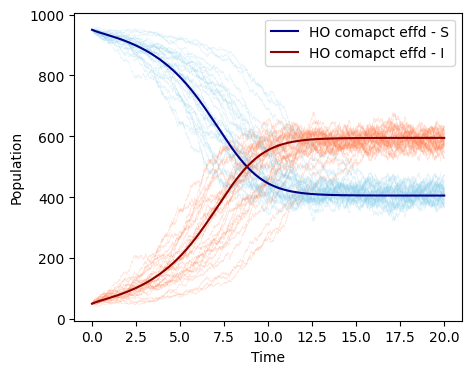

In [19]:
plt.figure(figsize=(5,4))
#results_model_reg_HO
times_runs, I_runs, S_runs =results_sim_reg1


for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,I_sim, color='coral', lw=0.3, alpha=0.2 )

#plt.plot(results_model_reg_HO[0],results_model_reg_HO[1],color='darkblue', ls='--', label='HO effd - S') 
#plt.plot(results_model_reg_HO[0],results_model_reg_HO[2],color='darkred', ls='--', label='HO effd I')

plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[2],color='darkred', label='HO comapct effd - I')

plt.xlabel('Time')
plt.ylabel('Population')

plt.legend(fontsize=10)

In [20]:



N=1000
mu=1
k1=5
k2=3



pairs= np.loadtxt(f'../HO_networks_from_jupyter/Poisson/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
triples=np.loadtxt(f'../HO_networks_from_jupyter/Poisson/poi_triples_uncorrIK_N{N}_k1{k1}_k2{k2}.txt', dtype=int)
hyper_edges=[*pairs, *triples]

hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

lam1=1.5
lam2=2
T=20


num_inf=50
beta1=lam1*mu/k1
beta2=lam2*mu/k2
para=[beta1,beta2,mu]


print('Compact HO-model')
results_model_poi_compactHO=odeint_compact_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=num_inf, steps_ode=6000)

print('')


print('Guillespie Simulation')
iters=30
num_inf=50
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

results_sim_poi=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-6)


C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\2798662056.py:8: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../HO_networks_from_jupyter/Poisson/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\2798662056.py:9: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally w

Compact HO-model
Starting Numba-optimized simulation...
Computing degrees with Numba optimization...
Initializing optimized state tracking...
Adaptative time True
Starting optimized integration loop...
Numba-optimized integration completed in 2608 steps
Final populations: S=398.7, I=601.3

Guillespie Simulation


In [21]:
plt.figure(figsize=(5,4))
results_model_reg_HO
times_runs, I_runs, S_runs =results_sim_poi


for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,I_sim, color='coral', lw=0.3, alpha=0.2 )


plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[2],color='darkred', label='HO comapct effd - I')

plt.xlabel('Time')
plt.ylabel('Population')

plt.legend(fontsize=10)

NameError: name 'results_model_reg_HO' is not defined

<Figure size 500x400 with 0 Axes>

In [22]:



N=1000
mu=1

gam1=2.5
gam2=2.25

gam1str=int(str(gam1).replace('.', ''))
gam2str=int(str(gam2).replace('.', ''))





pairs= np.loadtxt(f'../HO_networks_from_jupyter/Power_Law/powlaw_pairs_uncorrIK_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=int)
triples=np.loadtxt(f'../HO_networks_from_jupyter/Power_Law/powlaw_triples_uncorrIK_N{N}_gam1{gam1str}_gam2{gam2str}.txt', dtype=int)
#Do nothing 
hyper_edges=[*pairs, *triples]

hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

lam1=1.5
lam2=2
T=20


num_inf=50
beta1=lam1*mu/k1
beta2=lam2*mu/k2
para=[beta1,beta2,mu]


print('Compact HO-model')
results_model_pow_compactHO=odeint_compact_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=num_inf, steps_ode=6000)

print('')


print('Guillespie Simulation')
iters=30
num_inf=50
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

results_sim_pow=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-6)


C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\3797866935.py:14: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../HO_networks_from_jupyter/Power_Law/powlaw_pairs_uncorrIK_N{N}_gam1{gam1str}_gam2{gam2str}.txt',dtype=int)
C:\Users\jg3509phd\AppData\Local\Temp\ipykernel_28312\3797866935.py:15: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=f

Compact HO-model
Starting Numba-optimized simulation...
Computing degrees with Numba optimization...
Initializing optimized state tracking...
Adaptative time True
Starting optimized integration loop...
Numba-optimized integration completed in 2422 steps
Final populations: S=465.9, I=534.1

Guillespie Simulation


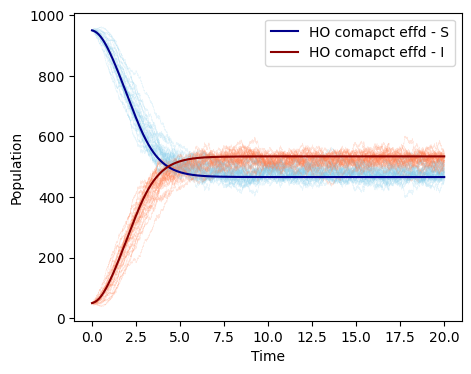

In [23]:
plt.figure(figsize=(5,4))
#results_model_reg_HO
times_runs, I_runs, S_runs =results_sim_pow


for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,I_sim, color='coral', lw=0.3, alpha=0.2 )

plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[2],color='darkred', label='HO comapct effd - I')

plt.xlabel('Time')
plt.ylabel('Population')

plt.legend(fontsize=10)

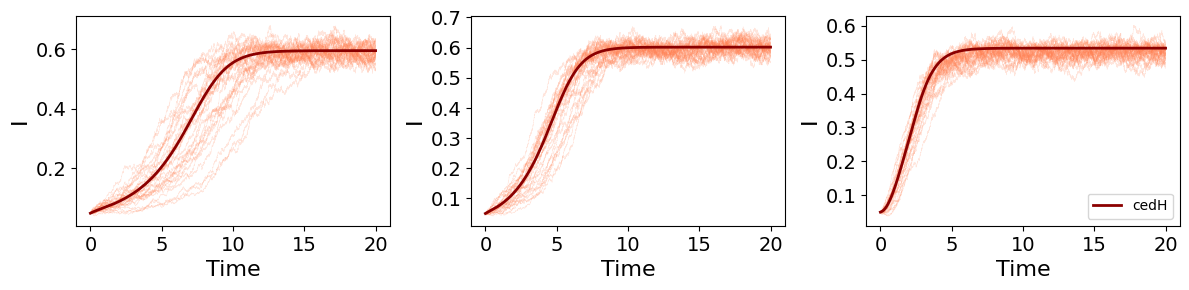

In [24]:
import matplotlib.pyplot as plt
import numpy as np
N=1000
# Create figure
fig = plt.figure(figsize=(12, 3))
#fig.suptitle("Compact HO - effectibe degree model", fontsize=16, y=1.02)
lw_1=2
# ---------------- First subplot ---------------------------------------------------------------------------------------
ax1 = plt.subplot(1, 3, 1)
#I_steady_states_1,I_steady_states_2,HO_effd1,HO_effd2,comp_HOeffd1,comp_HOeffd2 = Regular_result

times_runs, I_runs, S_runs =results_sim_reg1
for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color='coral', lw=0.3, alpha=0.2 )


#plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_reg_compactHO[0],np.array(results_model_reg_compactHO[2])/N,color='darkred', label='cedH',lw=lw_1)

plt.xlabel('Time',fontsize=16)
plt.ylabel('I',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(fontsize=10)

#ax1.set_title(fr"Regular")#,  $ k_1  = $ {k1}, $ k_2  = $ {k2}")

# ---------------- Second subplot --------------------------------------------------------------------------------------
ax2 = plt.subplot(1, 3, 2)
times_runs, I_runs, S_runs =results_sim_poi
for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color='coral', lw=0.3, alpha=0.2 )


#plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_poi_compactHO[0],np.array(results_model_poi_compactHO[2])/N,color='darkred', label='cedH',lw=lw_1)
plt.ylabel('I',fontsize=16)
plt.xlabel('Time',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylabel('Population')

#plt.legend(fontsize=10)
#ax2.set_title(fr"Poisson")#,  $\langle k_1 \rangle =$ {k1}, $\langle k_2 \rangle =$ {k2}")

# ---------------- Fourth subplot --------------------------------------------------------------------------------------
ax4 = plt.subplot(1, 3, 3)
gam1=2.5; gam2=2.25
times_runs, I_runs, S_runs =results_sim_pow
for i in range(len(times_runs)):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color='coral', lw=0.3, alpha=0.2 )



#plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_pow_compactHO[0],np.array(results_model_pow_compactHO[2])/N,color='darkred', label='cedH',lw=lw_1)
plt.ylabel('I',fontsize=16)
plt.xlabel('Time',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylabel('Population')

plt.legend(fontsize=10)
#ax4.set_title(fr"Power Law")#, $\gamma_1 = ${gam1}, $\gamma_2= ${gam2}")

# ---------------- One global legend ----------------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()  # use labels from first plot
#fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.09, 0.5), fontsize=11)

# Adjust layout so legend fits
plt.tight_layout()
plt.savefig('fig1top.svg')
plt.show()

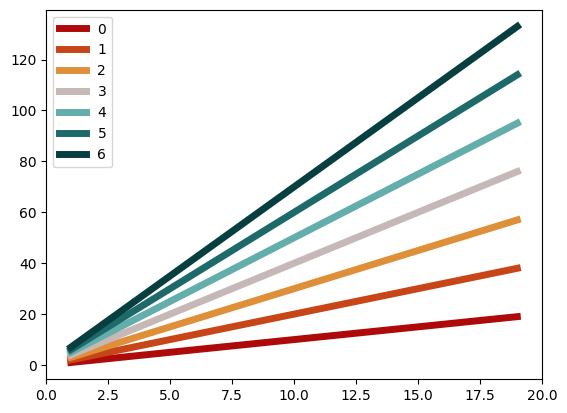

In [25]:
colors_1 = ['#800000', '#a93a0d', '#d58c41', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40'] 
colors_1 = ['#ae0a0a', '#c74517', '#e08f39', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40']


#['#580000', '#974013', '#dba164', '#d6d6d6', '#81bdbb', '#1e6b6a', '#003233']
colors_2 = ['#b35806','#f1a340','#fee0b6','#d8daeb','#998ec3','#542788']
colors_3 = ['#008c5c', '#33b983', '#002f64', '#0050ae', '#9b54f3', '#bf8cfc', '#680000', '#ac0000', '#c85b00', '#f98517']
y=range(1,20)
i=1
for c in colors_1:
    plt.plot(y,np.array(y)*i,color=c, lw=5,label=i-1)
    i+=1

plt.xlim(0,20)
plt.legend()

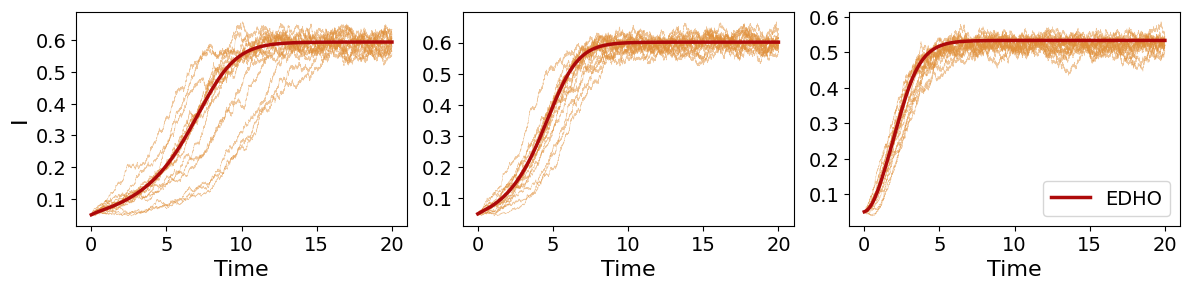

In [26]:
plt.rcParams['font.family'] = 'sans-serif'

import matplotlib.pyplot as plt
import numpy as np
N=1000

color_sim=colors_1[2]
color_model=colors_1[0]
alfa=0.5
lws=0.3
rep=2
# Create figure
fig = plt.figure(figsize=(12, 3))
#fig.suptitle("Compact HO - effectibe degree model", fontsize=16, y=1.02)
lw_1=2.5
# ---------------- First subplot ---------------------------------------------------------------------------------------
ax1 = plt.subplot(1, 3, 1)
#I_steady_states_1,I_steady_states_2,HO_effd1,HO_effd2,comp_HOeffd1,comp_HOeffd2 = Regular_result

times_runs, I_runs, S_runs =results_sim_reg1
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa)


#plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_reg_compactHO[0],np.array(results_model_reg_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)

plt.xlabel('Time',fontsize=16)
plt.ylabel('I',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.legend(fontsize=10)

#ax1.set_title(fr"Regular")#,  $ k_1  = $ {k1}, $ k_2  = $ {k2}")

# ---------------- Second subplot --------------------------------------------------------------------------------------
ax2 = plt.subplot(1, 3, 2)
times_runs, I_runs, S_runs =results_sim_poi
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )


#plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_poi_compactHO[0],np.array(results_model_poi_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)
#plt.ylabel('I',fontsize=16)
plt.xlabel('Time',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylabel('Population')

#plt.legend(fontsize=10)
#ax2.set_title(fr"Poisson")#,  $\langle k_1 \rangle =$ {k1}, $\langle k_2 \rangle =$ {k2}")

# ---------------- Fourth subplot --------------------------------------------------------------------------------------
ax4 = plt.subplot(1, 3, 3)
gam1=2.5; gam2=2.25
times_runs, I_runs, S_runs =results_sim_pow
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )



#plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_pow_compactHO[0],np.array(results_model_pow_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)
#plt.ylabel('I',fontsize=16)
plt.xlabel('Time',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylabel('Population')

plt.legend(fontsize=14)
#ax4.set_title(fr"Power Law")#, $\gamma_1 = ${gam1}, $\gamma_2= ${gam2}")

# ---------------- One global legend ----------------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()  # use labels from first plot
#fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.09, 0.5), fontsize=11)

# Adjust layout so legend fits
plt.tight_layout()
plt.savefig('fig1top.svg')
plt.show()

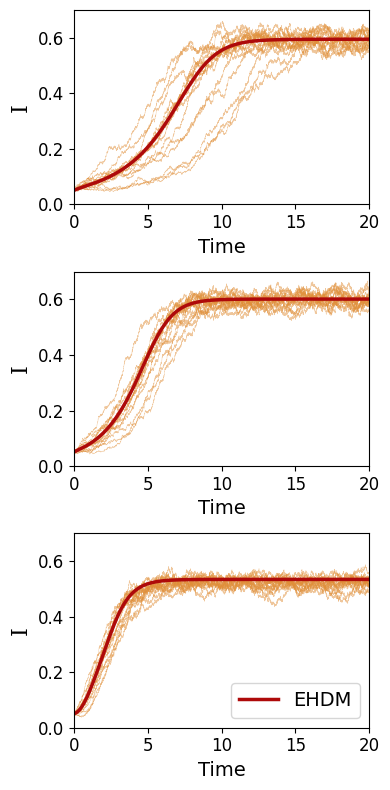

In [30]:
plt.rcParams['font.family'] = 'Segoe UI Variable' 

import matplotlib.pyplot as plt
import numpy as np
N=1000
plt.rcParams['font.family'] = 'sans' 
color_sim=colors_1[2]
color_model=colors_1[0]
alfa=0.5
lws=0.3
rep=2
# Create figure
fig = plt.figure(figsize=(4, 8))
#fig.suptitle("Compact HO - effectibe degree model", fontsize=16, y=1.02)
lw_1=2.5
# ---------------- First subplot ---------------------------------------------------------------------------------------
ax1 = plt.subplot(3, 1, 1)
#I_steady_states_1,I_steady_states_2,HO_effd1,HO_effd2,comp_HOeffd1,comp_HOeffd2 = Regular_result

times_runs, I_runs, S_runs =results_sim_reg1
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa)


#plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_reg_compactHO[0],np.array(results_model_reg_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)

plt.xlabel('Time',fontsize=14)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.legend(fontsize=10)

#ax1.set_title(fr"Regular")#,  $ k_1  = $ {k1}, $ k_2  = $ {k2}")

# ---------------- Second subplot --------------------------------------------------------------------------------------
ax2 = plt.subplot(3, 1, 2)
times_runs, I_runs, S_runs =results_sim_poi
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )


#plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_poi_compactHO[0],np.array(results_model_poi_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlabel('Time',fontsize=14)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#plt.ylabel('Population')

#plt.legend(fontsize=10)
#ax2.set_title(fr"Poisson")#,  $\langle k_1 \rangle =$ {k1}, $\langle k_2 \rangle =$ {k2}")

# ---------------- Fourth subplot --------------------------------------------------------------------------------------
ax4 = plt.subplot(3, 1, 3)
gam1=2.5; gam2=2.25
times_runs, I_runs, S_runs =results_sim_pow
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )



#plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_pow_compactHO[0],np.array(results_model_pow_compactHO[2])/N,color=color_model, label='EHDM',lw=lw_1)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlabel('Time',fontsize=14)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
#plt.ylabel('Population')


#ax4.set_title(fr"Power Law")#, $\gamma_1 = ${gam1}, $\gamma_2= ${gam2}")

# ---------------- One global legend ----------------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()  # use labels from first plot
#fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.09, 0.5), fontsize=11)

# Adjust layout so legend fits
plt.tight_layout()
plt.savefig('fig1top.svg')
plt.show()

In [39]:
sim_pow_1 = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 225.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 279.78, 292.02, 0, 0, 0, 0, 0, 277.04, 264.08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 309.28, 47.18, 0, 0, 0, 349.2, 0, 0, 0, 0, 0, 0, 278.58, 0, 0, 0, 0, 0, 0, 305.6, 0, 0, 0, 0, 0, 259.94, 0, 0, 0, 0, 0, 299.82, 0, 0, 0, 0, 0, 263.02, 294.86, 0, 329.38, 0, 0, 0, 0, 284.0, 0, 0, 0, 0, 0, 0, 0, 0, 270.46, 0, 0, 0, 0, 75.6, 42.46, 0, 325.48, 303.82, 0, 0, 288.66, 0, 0, 0, 0, 0], [0, 281.48, 295.76, 307.92, 0, 278.08, 311.16, 327.9, 293.56, 322.42, 330.84, 310.28, 276.7, 0, 293.48, 285.96, 280.48, 328.98, 362.94, 335.98, 266.3, 329.84, 0, 0, 0, 306.82, 254.08, 0, 325.7, 0, 0, 0, 297.26, 298.66, 0, 265.46, 356.7, 331.24, 317.72, 350.06, 0, 342.3, 349.28, 0, 0, 353.08, 344.0, 0, 293.8, 278.92, 0, 0, 355.74, 0, 0, 316.26, 0, 341.22, 0, 292.62, 339.72, 292.5, 276.8, 339.74, 319.3, 316.0, 0, 0, 0, 272.82, 293.66, 285.64, 287.64, 0, 0, 344.94, 306.1, 325.52, 255.74, 304.84, 299.14, 282.04, 270.68, 0, 0, 0, 0, 315.74, 324.64, 329.48, 0, 317.02, 258.38, 331.34, 344.58, 295.72, 0, 0, 0, 335.08], [0, 358.62, 333.88, 323.1, 307.2, 0, 322.12, 0, 314.48, 334.56, 332.7, 346.7, 0, 306.9, 332.46, 0, 0, 345.36, 352.74, 0, 410.88, 358.34, 0, 0, 0, 338.78, 313.22, 357.22, 0, 341.18, 346.74, 325.58, 317.86, 338.98, 332.88, 0, 0, 378.1, 377.12, 331.34, 0, 340.96, 342.96, 0, 0, 323.62, 310.26, 0, 335.44, 287.24, 359.92, 295.26, 316.62, 0, 344.44, 309.22, 286.18, 0, 340.58, 339.08, 351.42, 281.54, 292.76, 358.42, 345.06, 337.72, 336.82, 363.34, 0, 0, 343.38, 340.94, 0, 0, 336.4, 287.62, 296.08, 317.28, 0, 329.08, 0, 361.52, 346.46, 0, 329.88, 0, 294.46, 355.04, 319.74, 307.72, 301.98, 340.9, 307.5, 318.04, 341.62, 0, 283.86, 317.58, 340.46, 341.54], [348.8, 345.36, 346.26, 351.7, 348.48, 0, 367.32, 328.62, 338.86, 362.0, 325.18, 295.64, 0, 0, 283.3, 379.74, 333.9, 320.58, 347.42, 322.7, 378.64, 340.54, 379.68, 0, 362.68, 306.64, 338.28, 361.06, 311.1, 315.44, 344.34, 362.48, 326.66, 343.5, 0, 343.76, 346.22, 344.56, 0, 313.94, 325.68, 375.5, 283.06, 332.52, 316.02, 369.16, 347.02, 352.32, 372.88, 331.18, 333.94, 344.88, 0, 346.84, 325.04, 365.74, 334.54, 329.94, 374.98, 0, 0, 346.52, 346.2, 356.66, 327.7, 395.22, 0, 392.6, 372.08, 349.26, 346.3, 0, 348.64, 347.14, 355.28, 0, 336.5, 371.32, 351.98, 370.48, 347.62, 358.12, 367.3, 346.92, 0, 354.54, 362.78, 0, 351.02, 341.62, 363.52, 336.82, 346.62, 347.7, 397.28, 306.7, 0, 0, 341.46, 352.88], [329.42, 357.3, 360.94, 359.02, 0, 405.72, 320.56, 395.1, 400.08, 354.84, 319.1, 337.44, 358.1, 340.3, 398.28, 372.0, 335.96, 393.46, 342.66, 381.66, 373.18, 358.14, 338.58, 334.62, 399.86, 345.12, 397.58, 377.46, 0, 308.6, 330.76, 0, 359.96, 0, 359.94, 346.7, 0, 322.24, 380.52, 374.6, 387.74, 0, 388.06, 369.1, 0, 330.9, 336.64, 0, 327.06, 0, 363.88, 381.54, 376.86, 329.84, 352.86, 339.42, 400.9, 0, 331.6, 310.26, 382.18, 370.2, 354.86, 381.54, 0, 348.08, 0, 372.24, 375.62, 396.8, 379.38, 381.72, 362.38, 364.52, 0, 329.32, 379.18, 346.84, 0, 348.98, 340.18, 346.66, 335.98, 359.66, 393.0, 334.54, 372.68, 382.6, 342.5, 402.94, 383.88, 384.5, 373.88, 354.58, 344.3, 0, 386.0, 334.26, 0, 333.4], [401.72, 393.54, 357.08, 375.84, 350.38, 361.26, 354.76, 385.34, 356.76, 398.92, 390.06, 390.64, 412.44, 387.76, 386.6, 338.14, 358.52, 0, 387.44, 356.06, 351.32, 380.54, 371.94, 396.26, 382.52, 356.6, 335.74, 0, 373.84, 412.4, 387.14, 401.56, 0, 379.3, 402.48, 390.66, 0, 395.62, 406.88, 400.14, 0, 394.72, 381.28, 396.5, 0, 367.94, 374.78, 0, 407.72, 391.72, 388.68, 373.86, 332.58, 356.08, 389.38, 364.06, 358.74, 422.88, 368.84, 398.08, 326.42, 400.52, 375.66, 406.28, 413.38, 389.36, 410.96, 381.5, 370.62, 383.48, 381.56, 448.86, 381.2, 0, 386.62, 381.08, 393.94, 396.56, 362.58, 0, 392.64, 381.7, 391.7, 340.04, 384.0, 403.66, 359.6, 382.0, 382.84, 371.42, 416.98, 340.42, 375.6, 330.84, 393.28, 410.12, 386.64, 362.0, 368.48, 404.0], [401.72, 400.08, 352.38, 378.2, 345.68, 429.4, 392.12, 365.54, 399.22, 384.68, 377.24, 389.16, 0, 395.62, 398.18, 379.3, 390.36, 410.66, 391.4, 375.74, 402.32, 382.6, 375.9, 411.98, 0, 351.62, 404.72, 334.78, 0, 361.26, 359.9, 393.92, 384.42, 417.84, 404.06, 381.7, 392.38, 373.3, 407.38, 391.04, 422.8, 420.7, 377.38, 399.48, 406.54, 348.12, 397.22, 412.16, 370.84, 382.92, 381.04, 436.18, 382.32, 376.28, 367.74, 364.8, 379.2, 378.88, 390.46, 383.78, 369.44, 370.88, 409.84, 357.0, 387.5, 390.94, 0, 425.72, 400.22, 398.78, 378.62, 381.2, 389.18, 373.08, 400.52, 356.48, 357.86, 406.68, 391.26, 362.22, 367.16, 412.78, 409.74, 383.96, 355.78, 360.86, 391.3, 0, 371.6, 431.52, 356.72, 0, 372.72, 358.38, 390.9, 405.2, 414.24, 367.2, 419.84, 414.8], [424.3, 387.28, 415.78, 463.42, 409.56, 426.3, 420.92, 370.52, 459.2, 390.0, 396.66, 405.58, 398.16, 348.78, 401.34, 413.22, 387.7, 453.5, 388.0, 415.72, 422.12, 440.36, 433.86, 362.12, 418.22, 389.1, 404.66, 401.5, 410.24, 421.16, 0, 408.52, 386.32, 411.24, 0, 414.3, 416.28, 410.1, 423.66, 440.26, 420.06, 387.9, 386.58, 435.72, 414.86, 394.68, 416.56, 0, 375.34, 0, 399.0, 399.26, 393.1, 400.4, 419.68, 415.22, 401.26, 407.12, 418.42, 452.78, 406.6, 360.54, 405.46, 370.56, 383.74, 384.78, 381.06, 405.78, 406.38, 374.24, 383.18, 406.1, 367.9, 410.88, 431.08, 440.7, 405.36, 422.5, 415.82, 400.0, 373.56, 408.98, 415.96, 418.22, 451.7, 341.84, 436.16, 396.48, 379.82, 382.02, 436.62, 377.14, 431.14, 412.1, 406.74, 377.22, 420.02, 374.12, 391.38, 392.78], [424.66, 430.68, 407.16, 415.28, 400.62, 408.18, 442.58, 423.14, 417.04, 438.74, 421.5, 445.34, 406.92, 407.38, 398.58, 408.52, 419.08, 455.04, 407.38, 410.58, 453.38, 449.5, 446.52, 424.1, 414.62, 371.28, 444.6, 438.8, 416.96, 398.48, 382.0, 400.74, 473.56, 395.92, 441.2, 421.58, 0, 418.0, 461.98, 397.14, 413.28, 411.3, 408.5, 392.26, 421.3, 428.34, 417.54, 349.7, 419.38, 415.96, 440.58, 438.72, 402.52, 421.76, 405.98, 407.98, 414.82, 358.52, 426.14, 391.88, 414.06, 447.64, 407.44, 425.86, 419.08, 407.58, 416.38, 421.6, 413.78, 438.3, 460.1, 423.14, 400.1, 437.4, 382.94, 421.58, 364.6, 465.86, 392.54, 397.74, 400.6, 454.9, 417.74, 422.12, 387.6, 416.12, 404.5, 398.06, 419.92, 0, 454.48, 474.14, 438.12, 419.98, 419.16, 411.08, 412.86, 394.84, 406.8, 418.14], [440.22, 453.66, 378.86, 438.66, 460.4, 444.54, 439.9, 426.24, 417.14, 442.14, 393.92, 444.26, 440.58, 452.62, 424.78, 457.78, 463.22, 406.32, 413.3, 481.06, 482.56, 447.36, 410.92, 455.7, 428.44, 437.52, 457.1, 425.44, 444.34, 427.16, 439.6, 437.72, 0, 414.76, 437.66, 424.84, 435.38, 459.62, 371.84, 406.18, 439.26, 403.2, 436.52, 400.94, 423.18, 404.44, 446.66, 393.9, 458.12, 437.5, 429.16, 441.96, 410.48, 438.88, 435.14, 422.84, 408.8, 414.02, 382.84, 438.12, 413.94, 445.86, 406.02, 404.3, 412.6, 393.54, 414.82, 423.4, 419.38, 419.4, 407.3, 448.9, 406.58, 392.4, 441.8, 439.8, 444.48, 430.54, 414.04, 425.9, 433.12, 458.88, 405.58, 437.96, 421.44, 401.16, 422.36, 426.98, 407.74, 411.04, 455.7, 443.06, 424.12, 420.62, 430.44, 427.88, 423.68, 424.86, 467.56, 438.2], [426.66, 416.5, 435.02, 442.42, 433.46, 460.28, 389.5, 404.9, 446.8, 447.98, 399.02, 460.54, 439.7, 433.74, 410.34, 428.14, 417.08, 473.32, 444.0, 479.32, 437.02, 484.58, 433.62, 454.5, 424.22, 440.0, 470.78, 475.1, 429.78, 436.06, 474.54, 435.28, 406.54, 423.42, 453.36, 427.34, 470.84, 459.38, 427.74, 420.98, 472.34, 428.08, 436.24, 416.42, 431.68, 429.48, 430.66, 439.88, 387.08, 474.38, 462.52, 444.02, 436.86, 452.62, 445.06, 408.94, 434.06, 420.22, 441.66, 481.94, 444.3, 474.56, 449.76, 448.92, 426.76, 481.8, 396.44, 438.54, 450.06, 447.7, 377.32, 426.44, 419.22, 424.16, 406.04, 416.26, 431.34, 436.22, 422.86, 444.9, 442.68, 453.24, 404.18, 454.62, 438.9, 428.5, 441.46, 416.9, 462.28, 443.38, 0, 468.5, 469.5, 467.26, 418.66, 406.18, 439.84, 471.86, 436.3, 451.46], [463.58, 460.1, 409.34, 458.24, 456.26, 476.66, 470.12, 447.54, 444.72, 430.64, 478.6, 446.48, 426.2, 422.76, 431.12, 445.02, 470.64, 454.18, 432.38, 476.12, 473.1, 430.14, 454.2, 464.22, 421.9, 448.26, 438.14, 447.68, 453.56, 458.14, 480.32, 458.32, 461.5, 449.14, 459.6, 402.2, 445.28, 458.78, 440.36, 451.56, 413.24, 441.6, 484.54, 467.6, 410.08, 428.78, 451.64, 418.5, 439.14, 459.16, 447.12, 434.92, 485.4, 462.5, 472.98, 410.32, 443.04, 460.7, 448.2, 424.7, 455.76, 440.22, 478.98, 463.02, 496.8, 432.3, 468.08, 449.96, 434.68, 479.58, 484.08, 458.94, 438.7, 449.66, 439.64, 436.56, 448.38, 430.18, 464.52, 460.16, 460.88, 425.64, 444.78, 483.12, 454.88, 459.22, 454.44, 432.26, 488.8, 444.82, 466.76, 411.88, 473.04, 464.6, 423.06, 474.26, 457.86, 428.52, 461.56, 454.82], [474.54, 436.7, 459.76, 461.72, 456.66, 470.28, 464.46, 469.94, 484.3, 480.6, 433.82, 428.5, 497.14, 481.54, 447.16, 450.4, 468.86, 432.82, 491.02, 454.82, 460.54, 449.92, 456.4, 472.36, 473.28, 449.58, 457.2, 485.28, 447.26, 439.46, 474.4, 468.78, 470.64, 463.92, 443.16, 444.18, 442.08, 474.38, 461.92, 441.04, 433.62, 459.2, 454.0, 462.64, 434.84, 444.9, 431.02, 416.46, 450.6, 479.72, 447.46, 431.12, 467.52, 469.84, 453.22, 439.54, 452.7, 476.4, 426.36, 432.44, 465.98, 479.42, 441.82, 438.38, 446.94, 465.7, 458.42, 507.18, 440.34, 440.8, 460.12, 466.58, 470.86, 469.42, 466.46, 445.26, 446.4, 441.62, 448.72, 430.58, 457.1, 470.0, 486.5, 453.36, 469.06, 458.88, 450.82, 462.42, 449.46, 460.64, 513.6, 473.64, 462.42, 459.2, 457.44, 455.54, 440.3, 433.92, 463.38, 466.3], [470.94, 470.96, 472.66, 473.88, 488.76, 456.42, 448.76, 496.08, 503.44, 506.88, 457.74, 482.22, 467.42, 487.28, 477.82, 499.08, 479.7, 511.86, 462.22, 480.42, 494.6, 486.4, 470.86, 475.0, 466.66, 473.02, 481.46, 498.12, 463.46, 481.26, 489.82, 478.3, 463.32, 496.02, 450.52, 490.26, 468.92, 489.32, 505.68, 457.14, 465.12, 471.64, 467.6, 472.82, 499.72, 472.44, 503.3, 0, 514.96, 474.32, 484.48, 485.24, 441.64, 507.46, 469.6, 495.48, 493.22, 440.42, 464.04, 484.02, 473.6, 475.9, 492.62, 441.74, 435.7, 478.94, 516.36, 450.26, 493.84, 451.76, 507.36, 473.26, 471.54, 457.12, 483.7, 474.6, 510.8, 464.28, 479.26, 456.38, 444.12, 493.72, 480.08, 444.08, 0, 466.16, 476.28, 463.22, 469.64, 452.36, 504.74, 462.12, 475.12, 491.72, 490.88, 515.38, 486.22, 472.76, 484.6, 486.94], [526.36, 497.2, 475.08, 487.38, 473.86, 454.18, 458.52, 480.66, 467.18, 482.24, 448.66, 462.58, 476.04, 493.14, 479.56, 495.48, 488.6, 498.24, 470.02, 501.14, 478.8, 482.36, 476.38, 480.08, 486.78, 457.84, 482.42, 506.56, 450.08, 463.48, 490.24, 484.24, 466.04, 464.34, 493.16, 485.72, 458.68, 469.68, 485.94, 482.04, 454.6, 479.0, 479.06, 474.64, 500.24, 479.0, 505.38, 506.72, 461.02, 498.74, 525.18, 459.76, 487.94, 449.4, 481.08, 449.96, 455.94, 498.48, 525.84, 502.78, 467.44, 485.52, 466.44, 488.54, 499.66, 472.54, 477.8, 464.04, 472.48, 464.96, 482.6, 471.1, 478.98, 475.34, 479.58, 474.88, 477.08, 490.6, 475.3, 488.4, 530.82, 469.88, 474.86, 515.26, 470.42, 470.28, 470.14, 447.06, 460.64, 467.68, 477.76, 474.72, 501.32, 493.42, 486.24, 457.0, 457.56, 490.76, 494.86, 472.56], [495.76, 502.78, 490.2, 480.62, 507.6, 488.26, 482.26, 475.98, 503.18, 500.86, 511.74, 513.62, 473.6, 502.36, 489.48, 504.18, 504.14, 501.72, 496.68, 480.28, 519.08, 503.04, 479.4, 500.6, 498.62, 492.88, 484.42, 477.1, 519.68, 464.78, 471.7, 491.76, 477.72, 521.44, 491.46, 472.98, 477.96, 503.14, 476.24, 524.54, 525.78, 518.38, 453.66, 481.4, 463.78, 506.16, 504.88, 467.02, 506.22, 512.36, 475.0, 483.98, 465.68, 500.84, 495.44, 482.54, 479.88, 485.74, 471.64, 488.22, 463.88, 517.36, 489.32, 477.2, 518.16, 498.92, 498.66, 513.42, 474.88, 477.32, 503.48, 479.12, 487.22, 499.4, 495.26, 468.36, 488.84, 493.66, 0, 510.04, 520.62, 496.7, 469.1, 523.16, 496.7, 518.12, 493.02, 488.94, 506.16, 469.42, 467.78, 495.14, 474.42, 462.96, 502.24, 493.94, 504.72, 478.58, 494.18, 459.56], [481.2, 514.34, 512.9, 456.98, 506.06, 524.6, 488.9, 526.12, 457.26, 485.58, 495.06, 509.76, 456.58, 498.54, 512.08, 478.18, 516.54, 0, 489.8, 527.36, 500.88, 507.32, 505.42, 504.58, 502.5, 484.3, 487.9, 508.38, 494.92, 491.82, 545.86, 496.38, 540.44, 529.5, 513.22, 478.88, 498.96, 476.08, 446.4, 506.18, 452.42, 506.34, 492.58, 535.2, 519.58, 510.1, 527.84, 489.26, 502.56, 504.3, 497.38, 479.86, 477.78, 502.66, 504.68, 497.58, 484.26, 472.46, 482.96, 485.78, 509.82, 511.6, 511.44, 498.38, 493.2, 508.26, 524.6, 505.22, 492.82, 490.4, 514.96, 478.94, 530.9, 490.14, 500.2, 480.46, 473.56, 496.5, 479.4, 511.12, 484.94, 512.56, 489.1, 472.96, 492.02, 487.16, 522.58, 475.78, 509.06, 530.9, 528.86, 502.1, 470.6, 516.9, 476.4, 517.38, 490.7, 495.96, 466.5, 479.54], [507.42, 513.92, 503.32, 495.7, 453.4, 500.88, 503.94, 463.22, 521.48, 477.84, 514.56, 521.6, 477.1, 522.82, 517.1, 501.84, 532.38, 529.72, 516.72, 498.96, 528.9, 467.62, 493.6, 537.98, 0, 531.24, 507.68, 501.42, 478.02, 509.56, 513.2, 528.06, 491.48, 479.28, 540.3, 516.48, 525.26, 496.08, 528.26, 496.18, 499.76, 511.92, 468.3, 493.1, 511.7, 509.94, 492.46, 541.8, 494.94, 509.54, 496.06, 503.3, 481.38, 481.72, 531.7, 524.02, 505.3, 496.98, 480.24, 503.5, 508.86, 482.28, 537.66, 535.92, 484.14, 509.9, 523.6, 517.74, 532.2, 493.64, 503.0, 471.7, 489.1, 520.66, 551.52, 497.36, 508.22, 512.72, 460.22, 476.92, 533.06, 500.56, 529.94, 495.98, 487.02, 501.8, 493.66, 496.04, 476.64, 516.16, 503.66, 493.9, 480.56, 491.4, 516.2, 501.06, 511.56, 500.2, 502.8, 494.42], [497.28, 507.52, 522.64, 467.3, 524.28, 509.76, 544.26, 514.5, 504.96, 524.04, 498.16, 515.28, 530.92, 523.94, 517.88, 502.92, 528.46, 553.14, 531.9, 509.22, 492.94, 507.1, 503.66, 538.54, 514.28, 518.76, 525.2, 503.7, 536.9, 456.68, 541.18, 508.2, 527.48, 517.36, 493.5, 505.8, 522.24, 541.84, 484.26, 487.28, 525.6, 508.8, 487.1, 572.06, 517.8, 522.58, 518.62, 471.02, 530.88, 492.44, 541.1, 494.4, 549.48, 539.0, 520.94, 523.62, 502.24, 523.88, 516.22, 511.44, 522.14, 503.44, 522.22, 491.78, 525.86, 491.54, 528.12, 503.1, 547.98, 543.86, 519.64, 525.8, 477.78, 539.48, 505.0, 513.82, 503.92, 545.26, 507.28, 476.52, 538.72, 505.72, 499.72, 503.4, 518.96, 542.04, 487.56, 514.8, 523.48, 521.82, 470.22, 516.9, 501.04, 514.42, 528.58, 530.82, 502.56, 505.34, 520.88, 507.8], [513.56, 519.2, 571.58, 528.74, 532.96, 552.32, 537.0, 525.02, 553.38, 544.3, 514.32, 513.86, 527.7, 545.54, 567.0, 521.6, 519.94, 512.32, 503.76, 535.32, 536.18, 526.02, 529.6, 515.12, 505.64, 512.64, 504.38, 544.34, 541.8, 522.48, 511.68, 512.26, 552.1, 533.18, 498.52, 541.88, 502.62, 521.12, 495.9, 511.58, 500.76, 498.5, 515.66, 500.1, 538.4, 524.02, 503.3, 518.02, 499.6, 493.22, 540.48, 516.14, 532.86, 503.42, 543.52, 479.24, 509.1, 520.28, 531.6, 516.36, 512.78, 528.12, 516.46, 492.16, 512.34, 518.24, 511.82, 525.54, 506.6, 485.26, 529.64, 508.52, 514.76, 525.6, 538.62, 515.52, 506.36, 483.14, 516.92, 514.7, 547.56, 512.46, 528.76, 521.88, 521.74, 527.12, 511.66, 500.06, 531.56, 457.2, 516.34, 528.82, 527.44, 512.08, 549.02, 516.8, 538.32, 519.74, 509.82, 552.38], [543.28, 542.8, 552.68, 546.06, 501.2, 551.84, 532.2, 565.6, 515.66, 529.18, 515.26, 529.88, 516.02, 531.88, 523.48, 527.94, 530.32, 509.3, 508.78, 536.22, 529.22, 551.34, 527.06, 536.42, 572.66, 510.7, 556.0, 551.02, 520.0, 518.0, 513.02, 529.3, 506.28, 520.52, 552.44, 537.42, 525.12, 543.38, 543.3, 536.62, 527.58, 550.78, 521.88, 551.86, 548.8, 545.02, 530.94, 536.64, 540.5, 546.42, 546.24, 524.28, 523.28, 557.52, 540.7, 532.58, 554.42, 541.3, 547.2, 533.06, 508.62, 546.66, 526.96, 524.2, 506.96, 536.84, 543.88, 537.06, 512.62, 529.36, 532.38, 553.48, 533.22, 534.9, 563.04, 530.02, 510.62, 508.04, 507.4, 562.26, 549.9, 499.46, 489.2, 504.8, 528.4, 520.56, 551.28, 511.24, 532.68, 555.42, 549.28, 516.24, 497.58, 575.16, 543.48, 505.4, 543.78, 527.1, 543.74, 536.94], [550.14, 557.64, 543.74, 545.28, 541.32, 530.84, 508.58, 543.86, 535.66, 528.5, 517.5, 517.62, 571.9, 560.26, 535.36, 533.92, 526.06, 524.18, 551.2, 545.48, 538.92, 517.72, 533.56, 537.56, 553.2, 567.46, 502.72, 517.54, 552.36, 525.76, 583.7, 531.4, 520.88, 534.2, 529.46, 537.16, 511.7, 546.86, 533.24, 508.24, 523.8, 542.36, 541.44, 556.1, 532.58, 551.64, 556.04, 545.36, 534.8, 540.4, 515.34, 502.54, 531.2, 524.56, 555.56, 534.84, 548.18, 496.72, 521.08, 570.3, 515.88, 515.98, 536.0, 551.86, 510.94, 542.38, 517.98, 526.68, 514.1, 517.8, 541.62, 559.26, 507.82, 547.5, 545.02, 541.74, 533.82, 567.14, 533.58, 541.74, 528.9, 543.64, 534.18, 561.44, 523.64, 569.04, 551.92, 506.1, 498.36, 548.52, 537.66, 532.12, 541.78, 545.72, 533.38, 526.26, 533.06, 538.06, 501.54, 584.02], [507.98, 543.1, 556.64, 571.88, 554.86, 525.58, 564.32, 579.18, 541.78, 546.66, 534.56, 547.42, 537.2, 499.6, 547.32, 565.32, 569.08, 550.66, 538.04, 575.34, 578.84, 496.08, 525.46, 564.54, 566.3, 556.88, 509.64, 565.56, 561.46, 571.82, 558.94, 546.32, 581.62, 505.9, 570.08, 543.66, 567.2, 579.3, 548.32, 543.16, 556.18, 575.28, 541.44, 532.88, 542.08, 556.28, 569.44, 557.74, 525.84, 534.46, 547.96, 558.86, 557.9, 515.4, 519.58, 530.06, 577.18, 518.58, 571.78, 557.46, 556.04, 576.5, 550.12, 529.64, 576.26, 548.24, 557.64, 553.58, 472.62, 557.56, 571.6, 534.5, 547.94, 541.24, 572.96, 538.22, 558.5, 530.62, 557.76, 544.38, 534.16, 541.4, 527.8, 516.14, 557.1, 586.54, 533.64, 537.62, 532.78, 575.12, 520.1, 567.94, 512.12, 524.3, 582.04, 546.3, 550.26, 544.72, 589.9, 519.44], [558.34, 558.52, 537.08, 536.36, 510.36, 557.5, 529.6, 540.14, 558.32, 589.74, 567.74, 538.52, 548.7, 542.24, 541.02, 538.04, 558.58, 528.62, 546.04, 548.94, 543.74, 562.78, 569.02, 552.82, 523.18, 543.56, 576.68, 517.3, 540.18, 534.16, 544.7, 557.32, 561.22, 575.16, 566.28, 546.9, 543.12, 561.6, 579.6, 541.44, 546.36, 559.12, 536.02, 575.08, 563.64, 517.64, 521.12, 563.22, 526.86, 540.34, 541.52, 527.86, 566.36, 560.44, 516.18, 566.94, 579.76, 531.62, 558.68, 564.56, 540.3, 536.34, 513.78, 543.8, 574.86, 535.44, 519.34, 541.12, 543.68, 587.2, 566.8, 570.22, 532.28, 557.42, 523.04, 560.32, 572.6, 556.4, 539.4, 537.86, 566.84, 550.16, 570.7, 532.42, 528.14, 542.86, 550.96, 531.88, 536.98, 582.84, 542.26, 537.92, 594.18, 525.94, 543.72, 548.44, 525.46, 557.44, 573.28, 536.88], [524.88, 566.3, 546.7, 546.52, 544.02, 528.44, 551.46, 556.56, 562.16, 554.9, 566.04, 588.9, 538.92, 559.42, 556.76, 537.8, 528.18, 542.36, 571.84, 570.82, 573.78, 552.4, 544.42, 527.6, 556.48, 521.06, 574.3, 585.88, 539.1, 550.08, 573.94, 568.74, 570.2, 586.04, 550.0, 570.84, 540.4, 572.32, 550.56, 565.44, 543.12, 520.48, 571.92, 572.5, 542.98, 586.84, 580.54, 518.34, 578.82, 529.32, 573.8, 543.94, 551.54, 531.28, 559.08, 545.02, 573.5, 543.36, 549.78, 533.6, 555.72, 554.72, 586.08, 531.9, 544.66, 563.16, 575.96, 547.46, 594.7, 542.2, 545.18, 584.7, 564.64, 535.34, 555.06, 572.94, 537.94, 538.48, 539.3, 488.58, 573.02, 545.02, 543.08, 525.18, 550.1, 553.88, 536.04, 554.64, 550.62, 507.34, 531.28, 577.26, 566.98, 536.22, 561.56, 525.3, 552.6, 566.48, 570.44, 540.94], [558.28, 539.9, 545.16, 559.66, 551.32, 567.16, 542.52, 576.58, 576.52, 535.12, 583.74, 579.84, 542.46, 562.9, 583.62, 572.56, 586.78, 579.42, 575.28, 557.04, 600.88, 598.92, 583.84, 560.7, 530.82, 564.68, 602.06, 581.46, 552.64, 585.14, 534.34, 558.3, 561.22, 581.88, 569.94, 556.2, 579.64, 606.02, 557.34, 563.18, 549.64, 576.82, 520.32, 548.46, 565.94, 530.62, 565.06, 554.4, 554.58, 566.72, 556.46, 580.52, 594.34, 535.14, 533.96, 533.76, 586.82, 547.2, 574.88, 588.54, 554.42, 543.1, 558.98, 572.66, 564.9, 551.96, 574.18, 535.92, 570.88, 564.7, 571.94, 539.54, 546.32, 532.98, 560.44, 557.58, 572.52, 596.3, 563.88, 564.78, 549.5, 599.36, 567.4, 555.68, 522.14, 529.96, 557.02, 569.5, 562.64, 547.1, 552.08, 537.76, 571.42, 590.82, 564.8, 562.76, 569.32, 575.3, 554.46, 536.26], [557.6, 564.12, 567.2, 560.8, 583.02, 558.8, 575.8, 548.22, 575.54, 568.18, 569.16, 567.06, 575.66, 556.24, 557.32, 579.28, 547.68, 557.34, 548.36, 566.5, 582.58, 564.18, 564.04, 551.78, 532.42, 544.2, 586.4, 603.88, 566.4, 584.38, 591.42, 581.62, 558.48, 594.04, 575.1, 538.38, 579.86, 561.02, 569.34, 596.14, 569.08, 569.52, 550.78, 582.6, 542.22, 579.52, 575.1, 575.62, 564.62, 611.02, 568.46, 557.48, 559.18, 591.14, 574.8, 560.06, 596.0, 553.08, 588.12, 569.4, 604.5, 580.22, 575.3, 574.48, 580.24, 568.34, 539.1, 573.1, 578.44, 573.3, 596.32, 581.68, 567.92, 567.68, 579.28, 564.88, 554.02, 585.22, 582.54, 574.82, 545.82, 552.42, 586.52, 580.42, 604.96, 545.9, 547.74, 569.72, 586.64, 571.96, 590.96, 560.0, 542.08, 559.94, 559.7, 563.14, 562.4, 526.6, 553.54, 563.58], [581.34, 584.84, 582.6, 564.9, 556.18, 590.06, 579.78, 587.64, 568.66, 604.18, 530.74, 548.5, 605.38, 554.32, 586.34, 563.5, 571.86, 563.54, 576.32, 579.1, 532.94, 591.44, 608.68, 576.46, 565.8, 574.04, 562.44, 563.0, 568.42, 618.14, 583.18, 580.64, 601.14, 577.56, 598.92, 582.76, 559.88, 568.92, 560.18, 590.36, 574.36, 590.0, 571.12, 558.82, 576.62, 586.16, 542.86, 558.86, 583.5, 603.82, 582.28, 578.22, 609.98, 574.6, 564.16, 554.78, 589.24, 589.28, 582.94, 582.34, 589.14, 576.52, 529.26, 586.72, 538.34, 600.36, 558.8, 577.76, 575.2, 580.24, 561.56, 584.66, 565.64, 582.9, 541.98, 567.24, 602.66, 560.56, 545.3, 604.08, 578.94, 558.2, 567.12, 594.66, 570.08, 580.84, 567.94, 579.6, 556.08, 555.88, 577.0, 599.04, 534.04, 603.34, 569.82, 562.5, 589.86, 612.04, 585.76, 577.76], [588.42, 587.94, 602.32, 583.62, 547.38, 548.78, 567.66, 565.98, 608.92, 594.14, 600.76, 602.62, 553.78, 600.4, 586.4, 575.42, 575.08, 560.12, 591.38, 604.0, 589.58, 559.26, 575.3, 585.74, 545.72, 586.32, 572.62, 591.04, 579.58, 583.42, 589.18, 570.86, 617.46, 573.94, 585.1, 568.84, 573.26, 566.42, 587.16, 561.18, 541.52, 584.78, 585.98, 586.72, 587.08, 547.82, 571.78, 587.96, 592.32, 560.92, 605.74, 581.08, 574.62, 593.18, 571.12, 589.88, 589.88, 596.36, 567.44, 575.04, 600.92, 546.54, 552.02, 581.62, 569.8, 579.98, 575.36, 568.18, 600.32, 565.42, 599.12, 580.28, 551.42, 579.02, 546.56, 593.16, 610.76, 590.18, 577.86, 569.16, 579.84, 555.2, 581.3, 590.28, 571.06, 581.12, 562.68, 577.64, 604.06, 610.06, 560.94, 569.94, 579.9, 579.34, 579.2, 598.62, 583.86, 541.72, 625.92, 588.46], [586.2, 605.94, 608.84, 602.02, 583.34, 602.82, 616.46, 606.02, 579.62, 598.18, 589.16, 593.8, 580.74, 564.24, 567.9, 602.92, 592.64, 579.94, 586.96, 625.32, 586.68, 592.88, 573.18, 601.1, 589.64, 572.04, 580.66, 583.84, 583.08, 616.24, 612.2, 616.78, 591.76, 626.06, 584.52, 582.88, 579.48, 599.48, 585.4, 599.64, 564.24, 584.18, 573.64, 614.84, 601.42, 584.0, 584.44, 546.72, 589.86, 595.04, 583.16, 572.42, 568.34, 570.16, 544.78, 576.38, 600.82, 570.54, 602.54, 586.4, 595.96, 607.52, 630.34, 593.98, 579.7, 587.06, 568.2, 588.9, 544.8, 587.98, 617.2, 599.32, 592.9, 583.3, 592.68, 603.84, 567.52, 596.5, 575.74, 581.9, 574.18, 579.54, 591.26, 574.5, 581.04, 577.68, 591.26, 581.24, 595.2, 574.18, 538.58, 566.08, 612.7, 573.8, 602.78, 591.62, 603.48, 593.46, 580.24, 558.9], [585.06, 605.1, 598.72, 579.8, 588.16, 575.26, 588.94, 589.04, 584.9, 605.6, 596.98, 634.42, 563.82, 627.66, 610.34, 597.74, 592.6, 591.68, 556.76, 620.5, 594.84, 596.94, 555.6, 567.76, 582.9, 600.18, 602.22, 586.54, 581.4, 600.32, 576.5, 589.24, 598.54, 579.74, 614.2, 608.26, 615.2, 567.32, 614.78, 613.82, 550.32, 606.24, 590.18, 595.44, 605.5, 594.24, 598.62, 611.26, 591.04, 628.5, 613.8, 580.56, 596.2, 583.2, 569.14, 611.72, 605.56, 603.04, 584.48, 596.0, 597.84, 603.3, 596.9, 620.72, 591.52, 581.64, 591.84, 562.56, 592.72, 587.32, 599.36, 567.4, 599.52, 576.48, 579.78, 618.44, 578.14, 575.8, 601.06, 590.98, 606.3, 599.5, 580.18, 581.8, 593.44, 606.9, 598.2, 597.56, 578.52, 617.36, 597.88, 598.8, 610.36, 598.7, 571.0, 592.38, 576.3, 628.64, 604.76, 591.82], [609.08, 575.92, 607.0, 612.22, 594.44, 593.94, 596.88, 593.52, 600.66, 605.84, 611.18, 581.96, 591.78, 589.36, 634.28, 589.56, 589.26, 588.04, 616.14, 596.16, 622.1, 589.04, 619.06, 582.26, 586.1, 563.9, 539.2, 594.56, 592.44, 615.56, 605.86, 614.74, 590.76, 569.48, 587.82, 624.84, 620.42, 606.92, 616.74, 602.72, 597.54, 589.82, 600.42, 635.48, 612.26, 604.52, 639.4, 611.14, 586.38, 576.54, 614.5, 585.08, 569.22, 549.96, 585.56, 574.16, 624.84, 561.04, 587.42, 585.64, 569.86, 602.34, 600.84, 580.54, 601.64, 573.06, 585.14, 600.2, 592.84, 597.3, 598.5, 585.72, 625.84, 585.26, 608.54, 577.96, 641.62, 607.58, 577.36, 593.98, 636.5, 576.48, 594.92, 607.68, 591.6, 600.8, 593.24, 579.26, 591.76, 613.14, 586.24, 591.38, 604.3, 619.98, 567.5, 580.02, 564.24, 602.72, 571.6, 568.8], [603.54, 585.84, 617.7, 596.02, 614.5, 613.74, 612.12, 589.26, 615.12, 580.1, 546.52, 631.2, 609.84, 616.9, 589.66, 621.76, 641.56, 615.94, 599.66, 614.28, 611.58, 640.98, 615.22, 599.92, 585.7, 591.02, 569.86, 603.66, 603.72, 604.38, 567.68, 589.74, 591.42, 599.06, 618.74, 642.54, 634.56, 580.56, 599.9, 582.74, 627.48, 600.9, 585.08, 599.52, 574.28, 623.9, 600.58, 607.56, 617.98, 583.62, 587.74, 620.04, 583.64, 603.34, 580.92, 606.16, 623.12, 622.46, 621.06, 604.74, 585.74, 617.5, 617.12, 577.9, 610.86, 571.88, 585.98, 613.72, 610.12, 608.52, 599.1, 601.24, 613.7, 607.88, 594.94, 609.32, 593.58, 608.3, 579.86, 615.3, 580.96, 634.14, 604.0, 579.76, 601.56, 614.52, 627.26, 600.74, 585.78, 613.5, 589.54, 607.04, 642.64, 568.1, 600.8, 606.16, 594.72, 609.68, 568.02, 563.58], [583.36, 601.74, 606.7, 587.02, 591.42, 597.26, 614.8, 612.98, 578.24, 605.2, 601.96, 642.62, 598.06, 578.5, 593.74, 592.1, 638.78, 621.84, 620.16, 590.54, 611.34, 608.18, 617.92, 583.4, 619.68, 585.84, 628.76, 599.5, 605.46, 590.38, 601.52, 615.08, 675.3, 640.44, 584.7, 614.64, 613.06, 596.44, 611.34, 600.8, 621.8, 616.5, 629.76, 604.22, 589.82, 623.42, 598.42, 586.34, 629.88, 573.48, 615.38, 622.76, 581.38, 614.94, 606.48, 605.12, 600.46, 611.52, 587.2, 619.46, 605.58, 616.4, 583.98, 603.48, 625.62, 590.22, 635.46, 587.14, 588.58, 607.96, 623.96, 579.8, 588.04, 615.06, 621.72, 601.24, 590.22, 604.1, 601.96, 586.24, 601.48, 586.38, 605.92, 627.12, 611.88, 599.68, 600.6, 623.36, 582.16, 603.52, 594.62, 613.38, 626.6, 599.02, 608.18, 599.62, 583.56, 600.34, 593.4, 607.22], [609.88, 620.32, 598.4, 631.38, 647.7, 605.96, 605.86, 584.02, 580.62, 625.38, 612.98, 597.64, 608.84, 603.4, 616.28, 628.76, 608.14, 609.78, 640.8, 644.46, 622.72, 608.78, 596.48, 604.78, 575.76, 633.86, 606.5, 626.76, 609.16, 572.72, 626.06, 616.66, 618.32, 602.96, 635.1, 632.96, 611.18, 615.18, 616.58, 614.36, 641.36, 618.88, 603.5, 619.8, 630.18, 606.9, 619.72, 610.86, 626.34, 591.86, 640.58, 629.64, 633.52, 579.7, 618.64, 629.98, 610.26, 617.82, 610.7, 629.8, 580.4, 623.9, 636.18, 601.9, 612.34, 579.9, 601.12, 605.64, 622.6, 604.98, 627.26, 615.3, 579.02, 623.66, 629.86, 649.38, 598.3, 624.2, 637.48, 601.34, 608.82, 604.24, 607.68, 620.66, 604.7, 615.44, 637.34, 634.16, 625.44, 614.34, 623.12, 608.7, 614.22, 624.2, 620.94, 646.88, 614.84, 613.76, 588.26, 577.76], [614.64, 581.66, 627.7, 594.82, 633.08, 620.2, 657.0, 603.3, 596.24, 613.08, 659.92, 619.78, 631.76, 622.84, 597.62, 652.2, 612.5, 614.26, 597.56, 638.96, 598.2, 626.88, 569.44, 606.38, 616.22, 627.66, 599.4, 613.32, 614.76, 628.24, 607.86, 602.86, 626.46, 646.42, 604.14, 629.44, 611.16, 611.84, 634.58, 612.52, 599.74, 636.66, 646.98, 653.16, 598.98, 648.22, 614.44, 625.84, 631.58, 634.26, 641.08, 589.34, 633.4, 581.48, 607.8, 625.1, 605.88, 612.42, 593.0, 617.64, 616.22, 608.8, 584.46, 618.42, 646.64, 603.12, 603.9, 621.4, 625.16, 633.76, 632.1, 620.34, 635.96, 630.78, 594.94, 601.08, 632.44, 664.3, 611.46, 601.24, 615.02, 585.18, 617.08, 610.46, 625.98, 603.56, 625.84, 611.46, 625.54, 615.54, 637.8, 638.72, 613.7, 629.6, 592.78, 623.94, 584.54, 608.26, 592.92, 605.36], [634.22, 636.58, 606.3, 624.1, 602.88, 627.76, 616.02, 618.82, 617.54, 599.88, 614.5, 613.28, 593.68, 607.82, 645.08, 611.98, 632.54, 629.46, 615.2, 628.28, 608.36, 604.7, 620.1, 628.74, 619.62, 642.66, 616.7, 617.64, 626.64, 618.5, 603.62, 620.84, 637.12, 633.4, 648.58, 618.1, 611.94, 628.9, 612.24, 581.96, 612.38, 608.38, 647.6, 645.46, 618.76, 614.84, 630.18, 630.22, 671.06, 627.6, 639.52, 578.74, 649.28, 587.84, 629.36, 616.8, 606.34, 638.28, 617.78, 616.5, 624.3, 627.16, 606.68, 621.72, 618.9, 624.7, 629.14, 618.12, 593.26, 630.56, 611.34, 634.94, 624.36, 604.78, 649.72, 614.08, 643.86, 628.96, 623.26, 586.9, 641.06, 636.78, 597.7, 615.9, 608.26, 640.48, 632.6, 610.24, 663.56, 631.94, 613.14, 608.76, 612.14, 634.24, 619.34, 635.46, 625.22, 671.1, 595.96, 617.86], [604.68, 607.86, 608.68, 656.68, 631.74, 625.64, 627.14, 634.76, 590.54, 613.62, 614.48, 600.58, 613.24, 634.28, 605.02, 647.1, 617.44, 610.54, 609.88, 635.0, 636.28, 616.02, 651.14, 627.5, 630.42, 615.08, 637.56, 630.88, 633.86, 649.94, 619.9, 638.74, 610.84, 624.22, 644.42, 604.96, 602.9, 627.62, 592.5, 632.86, 604.6, 623.76, 626.16, 616.46, 617.24, 638.06, 607.56, 639.14, 607.88, 634.24, 647.12, 651.68, 641.68, 636.54, 614.38, 637.28, 639.94, 597.16, 615.7, 626.2, 648.32, 584.56, 628.86, 600.1, 650.08, 604.18, 623.7, 638.5, 606.56, 647.04, 628.62, 607.08, 634.38, 608.54, 623.0, 579.66, 641.06, 616.84, 620.58, 619.84, 621.56, 619.44, 633.26, 638.56, 647.76, 623.4, 629.22, 617.92, 615.3, 631.16, 583.7, 630.24, 594.36, 644.5, 608.9, 628.64, 645.5, 640.92, 652.86, 615.1], [649.32, 617.7, 627.62, 657.92, 603.04, 655.74, 629.0, 582.36, 633.12, 617.96, 624.06, 628.48, 656.44, 637.18, 658.58, 642.6, 633.32, 627.28, 648.2, 617.32, 600.48, 623.62, 632.14, 606.86, 621.4, 625.92, 645.3, 628.86, 625.68, 625.84, 577.36, 641.6, 608.24, 644.5, 641.96, 622.08, 624.16, 642.38, 656.36, 600.5, 595.92, 672.64, 619.96, 587.56, 622.86, 667.24, 645.14, 630.42, 626.9, 617.7, 625.34, 634.92, 579.1, 622.68, 614.26, 621.5, 619.6, 639.7, 623.36, 603.22, 603.56, 625.28, 648.04, 607.3, 598.68, 648.76, 635.84, 623.86, 623.96, 648.06, 633.56, 635.78, 626.42, 623.48, 613.38, 659.34, 628.68, 657.62, 623.58, 606.4, 638.0, 624.74, 624.08, 627.08, 646.2, 639.6, 613.9, 604.14, 626.82, 625.7, 647.58, 614.48, 640.14, 617.04, 628.84, 628.54, 633.5, 634.54, 619.82, 629.8]]
sim_pow_2 = [[0, 0, 33.34, 0, 33.4, 0, 0, 0, 0, 0, 0, 0, 31.82, 0, 30.98, 0, 0, 31.16, 32.08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 36.02, 33.3, 0, 0, 35.4, 0, 0, 34.92, 0, 0, 0, 0, 0, 0, 30.36, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.58, 0, 0, 0, 0, 30.1, 0, 0, 34.1, 0, 37.38, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.76, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.06, 0, 0, 32.2, 0, 0, 31.2, 0, 33.52, 0, 30.7, 0, 0, 0, 0, 0, 0, 0, 0, 31.5, 0, 0, 30.08, 0, 0, 0, 0, 31.52, 37.52, 0, 0, 0, 0, 0, 31.06, 0, 0, 0, 0, 0, 34.14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.92, 0, 0, 0, 0, 0, 0, 0, 31.86, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 33.98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 33.68, 0, 0, 0, 0, 0, 0, 30.2, 0, 32.04, 0, 0, 0, 33.26, 0, 0, 30.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 32.5, 0, 0, 0, 0, 0, 0, 0, 0, 31.32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 31.32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 35.04, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.28, 31.26, 0, 0, 0, 0, 0, 0, 0, 0, 31.22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 31.46, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30.78, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 34.18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 198.92, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 220.38, 214.34, 0, 0, 0, 0, 171.56, 0, 0, 0, 97.68, 0, 0, 0, 0, 159.32, 121.84, 0, 0, 215.12, 0, 0, 0, 0, 0, 238.84, 0, 0, 0, 0, 174.18, 0, 0, 0, 0, 0, 0, 178.18, 0, 0, 107.74, 0, 0, 0, 0, 253.26, 0, 0, 0, 170.68, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 156.66, 161.16], [188.82, 0, 232.22, 198.74, 0, 229.68, 229.56, 221.8, 0, 231.42, 153.18, 202.52, 218.06, 134.9, 0, 246.54, 0, 248.24, 268.28, 239.46, 153.1, 182.46, 223.96, 208.28, 260.62, 168.38, 0, 187.66, 42.72, 0, 246.46, 215.1, 222.02, 247.7, 157.2, 0, 0, 200.38, 0, 147.7, 0, 274.62, 52.94, 198.38, 66.32, 0, 212.74, 0, 213.14, 162.06, 254.46, 70.08, 0, 0, 207.7, 199.54, 0, 0, 0, 0, 147.04, 0, 0, 221.92, 133.6, 0, 0, 0, 80.38, 215.6, 236.66, 0, 220.12, 92.48, 0, 240.92, 216.52, 0, 0, 261.4, 255.52, 267.74, 228.22, 0, 205.18, 87.5, 186.42, 0, 238.22, 173.16, 261.22, 0, 229.4, 195.16, 0, 0, 0, 237.6, 0, 0], [205.26, 251.9, 234.36, 271.2, 242.44, 253.0, 240.16, 282.92, 203.7, 99.14, 275.56, 257.94, 248.44, 234.14, 205.2, 238.72, 241.34, 227.26, 244.74, 264.58, 187.88, 237.96, 253.7, 227.1, 218.32, 234.56, 252.94, 209.24, 256.3, 288.12, 272.96, 246.68, 284.56, 251.84, 266.64, 198.0, 106.46, 303.72, 257.02, 238.06, 198.26, 263.48, 261.7, 273.36, 174.98, 0, 267.2, 259.22, 179.82, 260.3, 273.82, 230.18, 269.34, 234.88, 256.34, 204.68, 176.58, 281.58, 260.4, 265.48, 255.12, 270.64, 274.12, 205.26, 216.14, 273.54, 225.24, 237.1, 245.78, 250.76, 234.48, 262.54, 245.9, 269.36, 250.84, 189.82, 123.04, 153.84, 290.24, 205.2, 268.84, 0, 278.96, 275.94, 256.5, 239.22, 238.18, 202.5, 293.96, 270.16, 208.48, 205.34, 243.08, 207.54, 271.1, 213.82, 188.56, 273.14, 259.9, 232.9], [256.38, 224.38, 216.0, 244.62, 274.4, 293.22, 257.82, 289.52, 265.76, 240.62, 237.86, 258.94, 299.2, 276.44, 251.02, 265.02, 293.46, 287.42, 278.5, 259.72, 266.22, 284.7, 326.58, 304.18, 273.54, 302.4, 297.68, 261.38, 302.94, 334.44, 267.54, 308.14, 300.98, 283.84, 237.96, 316.52, 234.7, 258.34, 254.94, 243.36, 244.18, 258.76, 264.38, 283.76, 305.18, 265.54, 268.92, 175.82, 240.14, 272.34, 262.1, 278.66, 256.9, 269.6, 256.94, 321.36, 310.58, 170.92, 273.22, 284.5, 291.58, 296.14, 259.84, 251.26, 226.7, 267.66, 220.72, 281.14, 275.02, 268.06, 235.94, 242.76, 238.14, 272.46, 287.64, 251.9, 274.42, 225.08, 239.32, 261.3, 318.76, 263.06, 279.96, 266.18, 260.78, 268.72, 200.82, 246.26, 240.94, 198.9, 304.0, 243.88, 266.02, 299.36, 201.24, 244.76, 302.38, 268.38, 290.9, 297.3], [277.38, 301.7, 226.96, 213.04, 288.08, 282.16, 292.72, 299.8, 266.84, 351.74, 285.74, 261.04, 274.56, 290.84, 292.82, 282.86, 300.14, 272.84, 301.58, 251.7, 291.96, 301.88, 295.48, 286.08, 350.2, 265.32, 273.72, 248.38, 312.0, 286.42, 332.42, 321.14, 295.42, 249.34, 334.9, 340.7, 295.04, 244.54, 278.84, 289.18, 285.76, 302.62, 258.94, 211.98, 262.16, 278.46, 276.9, 316.38, 311.12, 275.14, 272.1, 289.58, 283.64, 309.38, 280.96, 263.72, 290.62, 294.58, 292.3, 308.68, 337.1, 261.24, 304.68, 312.0, 265.26, 287.86, 235.12, 293.42, 266.28, 321.24, 281.88, 341.6, 273.06, 305.76, 239.94, 307.96, 236.96, 297.12, 305.38, 325.36, 302.52, 290.42, 282.6, 285.24, 254.36, 276.74, 254.62, 299.8, 299.12, 335.8, 285.94, 327.26, 300.42, 353.3, 328.64, 304.34, 305.64, 283.62, 315.7, 247.9], [298.8, 316.76, 245.94, 351.6, 329.46, 342.12, 272.44, 323.36, 314.96, 296.58, 260.98, 320.1, 344.14, 280.14, 335.9, 230.74, 233.92, 309.22, 298.82, 280.58, 334.42, 317.18, 340.42, 314.78, 331.36, 321.02, 301.38, 345.46, 324.1, 322.18, 325.92, 282.88, 345.7, 289.84, 293.42, 292.38, 316.14, 316.8, 346.78, 267.68, 333.0, 291.66, 294.1, 292.96, 296.86, 274.92, 287.76, 309.26, 283.84, 344.2, 329.06, 284.38, 291.84, 319.38, 307.08, 298.66, 324.96, 303.0, 329.54, 316.98, 308.94, 327.96, 319.62, 310.68, 315.44, 305.86, 258.12, 321.24, 343.14, 311.68, 320.4, 317.84, 312.88, 308.5, 342.0, 339.4, 338.02, 344.34, 294.48, 295.62, 339.72, 333.48, 340.24, 291.48, 300.68, 310.28, 305.58, 311.92, 329.68, 280.1, 293.58, 305.5, 309.22, 279.04, 350.44, 283.0, 265.28, 333.5, 327.4, 266.24], [358.18, 291.06, 355.32, 371.5, 320.38, 365.3, 297.42, 324.96, 256.88, 312.28, 300.66, 312.0, 341.2, 320.14, 339.04, 321.3, 289.44, 335.58, 360.4, 282.78, 306.02, 305.62, 358.14, 328.68, 274.62, 352.56, 365.42, 321.32, 360.78, 365.0, 301.62, 349.16, 350.58, 334.06, 337.2, 300.6, 322.72, 332.06, 337.18, 348.76, 341.2, 352.22, 340.84, 289.66, 335.46, 330.1, 342.66, 370.52, 308.36, 370.5, 342.24, 338.74, 317.02, 319.92, 328.1, 374.42, 322.68, 303.1, 324.62, 290.02, 347.3, 310.46, 326.92, 322.86, 317.36, 327.6, 337.8, 328.88, 282.3, 310.52, 307.84, 283.2, 308.04, 332.84, 304.82, 357.72, 338.22, 346.06, 321.24, 369.58, 357.48, 353.14, 363.86, 319.16, 345.4, 344.06, 361.48, 346.52, 360.8, 334.7, 282.7, 338.28, 340.82, 282.14, 349.52, 339.22, 337.88, 308.82, 329.48, 315.32], [346.2, 392.68, 347.76, 349.82, 392.1, 366.38, 321.36, 339.54, 339.88, 359.4, 302.42, 371.64, 314.02, 291.64, 326.64, 377.92, 343.78, 316.88, 348.52, 354.82, 350.72, 369.22, 370.88, 376.92, 326.8, 321.38, 347.26, 308.58, 375.74, 341.86, 354.64, 332.7, 350.78, 357.48, 321.58, 362.06, 300.84, 358.26, 324.0, 343.96, 398.78, 342.36, 353.32, 363.68, 381.84, 345.8, 313.72, 351.7, 344.44, 299.06, 372.94, 328.1, 329.54, 392.1, 343.56, 348.12, 358.34, 356.36, 320.26, 364.56, 322.36, 364.5, 327.92, 355.3, 349.44, 329.32, 324.34, 348.0, 367.92, 393.0, 362.96, 351.12, 355.82, 376.82, 318.56, 381.16, 359.98, 334.48, 373.78, 363.62, 371.74, 391.7, 355.92, 344.38, 338.9, 347.18, 297.5, 362.04, 350.0, 362.12, 361.94, 390.02, 299.96, 333.0, 367.22, 326.66, 321.36, 357.84, 345.5, 344.46], [339.96, 320.4, 351.24, 372.2, 324.1, 338.74, 319.62, 341.98, 371.14, 413.38, 378.42, 353.6, 389.0, 381.28, 378.36, 355.86, 363.3, 358.56, 342.56, 375.94, 386.78, 398.76, 388.38, 322.54, 384.44, 364.42, 398.08, 335.6, 350.04, 314.64, 352.84, 338.22, 367.64, 381.58, 403.84, 341.16, 341.3, 391.92, 370.9, 353.58, 353.82, 328.7, 388.66, 384.6, 335.4, 350.88, 372.98, 351.08, 410.52, 372.52, 433.66, 351.04, 341.1, 372.82, 357.02, 355.44, 399.78, 356.84, 366.1, 394.14, 337.78, 347.94, 354.26, 383.84, 365.82, 413.58, 378.34, 335.86, 387.12, 343.24, 336.7, 343.88, 346.14, 334.34, 354.18, 356.42, 367.92, 330.66, 370.56, 360.48, 365.0, 349.96, 361.88, 313.18, 335.1, 336.9, 374.46, 327.14, 382.74, 347.14, 385.78, 374.7, 327.8, 385.34, 365.6, 374.82, 421.2, 386.8, 334.5, 348.64], [345.08, 352.9, 379.06, 403.5, 347.68, 401.9, 408.16, 388.38, 341.3, 424.4, 376.54, 384.06, 381.86, 371.5, 401.5, 366.4, 384.04, 352.22, 408.14, 339.1, 363.84, 391.56, 365.76, 398.66, 416.04, 353.9, 372.32, 407.06, 377.94, 372.1, 415.2, 406.62, 357.68, 387.56, 350.94, 393.7, 368.34, 345.12, 334.28, 435.76, 355.28, 393.08, 406.38, 383.54, 358.54, 382.6, 388.06, 383.32, 410.44, 400.54, 364.28, 382.9, 328.04, 404.8, 392.88, 392.44, 395.58, 392.44, 388.76, 382.14, 373.82, 396.74, 365.18, 386.5, 353.4, 372.58, 395.4, 417.96, 401.02, 409.52, 388.6, 410.08, 386.64, 362.62, 402.52, 363.36, 382.34, 357.3, 387.42, 386.18, 365.44, 349.58, 383.34, 378.9, 341.46, 403.22, 365.62, 391.2, 352.64, 351.06, 353.82, 364.1, 335.08, 399.24, 359.74, 396.72, 355.92, 348.98, 402.74, 399.54], [367.6, 410.08, 377.42, 398.9, 403.78, 390.36, 353.98, 393.48, 391.48, 389.92, 374.36, 354.76, 377.86, 392.02, 410.86, 373.84, 387.0, 413.62, 408.26, 397.1, 339.2, 415.58, 413.92, 414.28, 325.34, 446.24, 385.18, 391.82, 371.74, 385.58, 393.2, 388.52, 374.54, 393.68, 376.0, 363.18, 417.7, 374.86, 385.14, 389.2, 422.3, 414.54, 393.44, 409.18, 385.96, 339.2, 381.62, 375.56, 378.34, 415.5, 384.82, 360.08, 373.3, 422.8, 418.88, 390.12, 364.24, 378.86, 401.84, 389.62, 373.56, 417.8, 418.94, 375.86, 373.66, 400.64, 360.78, 379.48, 414.62, 384.0, 408.28, 356.42, 415.92, 401.66, 365.38, 405.92, 387.58, 380.06, 406.24, 414.28, 385.52, 389.26, 389.54, 385.02, 428.5, 397.02, 353.6, 444.42, 417.3, 379.52, 386.66, 380.58, 410.58, 391.52, 396.28, 365.06, 395.0, 403.58, 345.8, 403.78], [419.32, 410.8, 447.1, 432.16, 401.98, 437.46, 376.9, 420.12, 431.42, 405.88, 380.22, 430.6, 420.84, 402.74, 402.8, 397.66, 375.84, 397.64, 410.28, 402.38, 403.62, 404.26, 372.16, 414.86, 423.76, 407.9, 408.98, 374.24, 391.58, 409.9, 399.8, 358.26, 398.04, 431.48, 416.9, 433.94, 410.36, 428.72, 347.72, 395.76, 416.5, 412.2, 414.46, 420.3, 401.58, 393.9, 423.42, 440.42, 444.76, 420.06, 434.04, 444.04, 432.24, 406.08, 403.62, 367.62, 388.28, 411.84, 419.4, 398.96, 411.44, 416.0, 393.4, 419.54, 404.76, 426.9, 398.02, 409.28, 344.52, 390.38, 417.62, 383.36, 400.88, 422.72, 412.08, 415.42, 372.62, 444.0, 428.4, 418.72, 378.84, 410.38, 430.92, 405.56, 361.46, 414.22, 411.66, 416.66, 400.36, 386.64, 382.44, 386.02, 422.72, 429.96, 380.38, 418.48, 451.0, 403.74, 418.88, 433.44], [398.62, 398.68, 431.14, 413.62, 405.26, 454.44, 416.96, 403.32, 410.5, 438.44, 355.46, 432.92, 421.92, 422.96, 419.76, 440.26, 364.38, 431.16, 436.74, 474.44, 433.5, 441.0, 404.4, 409.36, 431.72, 435.88, 455.46, 373.28, 448.96, 436.28, 417.46, 426.22, 424.92, 417.88, 395.94, 410.16, 405.0, 407.36, 381.94, 401.96, 395.88, 408.62, 440.04, 410.88, 407.8, 376.62, 414.26, 442.0, 430.82, 408.64, 405.0, 400.58, 399.3, 422.76, 381.64, 447.66, 401.84, 413.36, 412.5, 430.46, 406.32, 403.44, 407.2, 410.2, 403.2, 460.3, 390.48, 454.14, 407.48, 406.12, 446.54, 436.98, 412.44, 378.92, 433.7, 389.6, 428.88, 402.82, 411.98, 402.84, 426.5, 396.44, 435.16, 367.26, 411.22, 411.04, 410.9, 432.84, 416.6, 423.68, 426.94, 403.16, 425.74, 372.78, 457.24, 392.6, 426.64, 439.2, 413.2, 404.4], [411.96, 434.86, 434.3, 453.02, 380.58, 426.92, 444.82, 421.5, 409.48, 434.42, 410.22, 418.48, 443.82, 440.54, 430.5, 419.66, 455.56, 462.26, 426.02, 403.68, 418.86, 364.1, 414.28, 393.76, 456.38, 425.32, 428.32, 471.1, 482.64, 406.52, 420.94, 433.86, 445.64, 396.18, 380.92, 429.28, 450.24, 449.24, 475.74, 405.76, 460.9, 441.18, 446.54, 427.92, 449.44, 484.68, 426.8, 422.2, 438.82, 422.64, 439.1, 397.86, 421.22, 463.1, 413.5, 434.92, 421.14, 424.1, 421.28, 403.86, 445.02, 430.0, 449.22, 452.16, 467.46, 379.7, 442.34, 420.54, 472.3, 406.88, 424.8, 439.54, 412.26, 424.78, 431.22, 407.2, 425.38, 428.28, 447.36, 511.86, 416.5, 462.92, 456.06, 431.9, 439.38, 446.86, 454.68, 410.22, 403.58, 414.36, 438.16, 426.6, 433.02, 448.58, 483.38, 379.88, 395.62, 398.4, 450.78, 448.12], [484.44, 406.88, 463.32, 479.34, 430.02, 446.9, 435.06, 418.84, 438.26, 403.04, 440.38, 427.9, 421.4, 448.66, 440.16, 427.58, 439.38, 412.66, 440.3, 427.02, 446.0, 462.86, 429.54, 419.58, 444.04, 419.86, 455.2, 440.16, 451.14, 469.0, 425.36, 429.78, 459.14, 440.36, 429.56, 418.68, 441.0, 435.64, 458.4, 405.66, 449.94, 442.54, 427.72, 417.38, 448.46, 410.1, 455.08, 440.16, 452.24, 454.18, 445.34, 412.88, 404.72, 380.06, 433.5, 457.36, 413.04, 453.38, 450.2, 396.84, 433.48, 433.82, 439.66, 441.0, 443.04, 416.34, 437.12, 427.02, 417.96, 447.54, 427.52, 450.12, 424.94, 474.92, 481.98, 440.6, 409.98, 479.9, 413.48, 437.66, 441.06, 436.22, 426.56, 435.14, 416.08, 448.9, 419.44, 419.5, 435.66, 465.36, 450.26, 452.3, 453.94, 434.96, 462.4, 459.88, 432.6, 418.98, 428.32, 456.86], [405.94, 466.58, 467.2, 474.1, 447.9, 487.72, 440.06, 460.02, 424.52, 372.84, 472.5, 445.4, 485.92, 437.3, 427.42, 420.86, 454.46, 441.6, 470.68, 456.78, 450.38, 458.62, 465.98, 448.82, 451.74, 449.24, 428.12, 449.38, 462.26, 455.98, 452.74, 477.98, 453.44, 444.44, 437.82, 473.16, 462.54, 430.66, 457.24, 435.3, 438.26, 445.88, 439.76, 448.9, 441.52, 444.86, 454.94, 455.24, 419.36, 486.8, 457.08, 398.64, 429.44, 440.9, 454.04, 470.32, 490.52, 446.28, 492.28, 450.56, 445.64, 449.6, 487.42, 414.22, 476.56, 481.3, 430.38, 443.1, 477.78, 460.84, 463.12, 454.88, 498.28, 453.6, 435.88, 454.1, 460.78, 452.54, 481.34, 440.28, 446.26, 434.76, 451.76, 451.84, 487.06, 406.82, 415.24, 478.38, 417.3, 446.78, 441.22, 454.46, 434.38, 460.04, 437.22, 477.12, 449.96, 456.52, 462.7, 437.94], [477.88, 435.72, 446.96, 430.28, 454.12, 474.44, 486.6, 426.94, 485.1, 443.9, 451.3, 465.42, 438.56, 485.74, 435.76, 476.36, 468.66, 477.0, 476.6, 484.24, 466.12, 482.46, 449.9, 443.94, 432.54, 436.2, 453.4, 465.62, 486.74, 445.68, 467.16, 454.22, 484.54, 484.26, 469.12, 494.68, 462.66, 423.9, 446.76, 481.62, 440.62, 493.74, 442.94, 410.8, 407.0, 457.04, 487.4, 473.46, 477.98, 455.22, 471.3, 432.54, 495.84, 470.06, 434.5, 417.88, 451.52, 473.24, 421.84, 457.72, 460.06, 407.26, 477.86, 446.4, 498.46, 463.88, 482.46, 466.88, 468.06, 463.84, 449.72, 509.32, 466.92, 447.92, 472.62, 449.88, 478.48, 463.34, 473.74, 466.28, 447.78, 494.8, 472.7, 445.38, 485.04, 458.78, 516.86, 468.02, 503.94, 452.98, 473.96, 463.04, 441.54, 436.86, 471.3, 476.0, 430.98, 483.98, 448.72, 471.36], [459.48, 465.32, 453.1, 482.92, 458.7, 516.56, 424.76, 458.48, 475.14, 451.62, 473.7, 425.66, 506.42, 499.54, 470.9, 440.42, 459.7, 483.32, 488.8, 475.5, 472.66, 463.08, 443.84, 469.08, 470.5, 489.92, 488.06, 483.38, 470.14, 447.82, 469.48, 501.06, 485.76, 475.94, 492.84, 448.54, 465.38, 436.08, 456.1, 451.6, 494.74, 456.1, 441.02, 462.46, 483.34, 495.34, 445.1, 485.16, 481.86, 465.18, 456.48, 495.64, 466.76, 461.26, 480.6, 489.7, 487.32, 457.14, 493.0, 464.2, 485.68, 455.42, 501.26, 483.84, 438.58, 483.16, 417.52, 446.36, 476.6, 476.62, 495.0, 459.88, 509.94, 459.96, 507.64, 493.9, 451.5, 453.78, 434.82, 457.16, 483.46, 453.6, 482.36, 485.38, 462.52, 454.46, 448.06, 470.72, 428.48, 446.16, 480.56, 451.24, 458.92, 483.2, 473.12, 454.54, 427.74, 447.92, 454.28, 489.1], [454.28, 479.36, 439.34, 494.06, 441.9, 476.12, 505.32, 495.32, 471.02, 475.82, 516.28, 452.46, 507.38, 465.82, 467.42, 475.14, 482.58, 479.24, 505.62, 487.28, 479.76, 481.42, 460.68, 481.26, 492.54, 475.66, 488.94, 465.82, 438.74, 508.86, 463.52, 465.58, 509.14, 523.4, 506.58, 494.82, 490.94, 481.46, 496.66, 457.94, 493.54, 506.78, 481.16, 455.12, 466.98, 483.92, 499.66, 463.82, 477.82, 438.62, 505.72, 455.82, 491.18, 502.44, 469.32, 492.48, 491.88, 488.96, 463.62, 482.22, 481.96, 476.72, 483.48, 498.5, 458.96, 517.46, 460.36, 494.06, 478.9, 483.92, 462.56, 494.7, 495.78, 505.16, 436.38, 479.18, 473.1, 486.28, 490.5, 469.52, 478.86, 485.58, 467.16, 512.52, 495.72, 459.54, 460.64, 442.96, 461.28, 535.74, 492.58, 510.08, 496.22, 460.26, 493.18, 490.96, 484.9, 472.94, 472.9, 435.28], [499.8, 463.7, 493.38, 506.4, 490.94, 499.5, 487.8, 496.46, 490.84, 475.9, 511.92, 432.02, 519.98, 492.46, 510.94, 480.46, 490.16, 478.98, 496.82, 500.14, 495.22, 484.86, 496.68, 480.94, 491.16, 485.36, 468.64, 457.9, 459.02, 501.84, 473.78, 489.18, 446.38, 488.28, 481.0, 489.4, 493.54, 463.66, 509.98, 508.24, 508.0, 510.92, 498.68, 498.7, 480.3, 465.24, 507.28, 503.88, 523.16, 499.36, 490.7, 485.94, 493.08, 469.36, 477.26, 494.06, 485.4, 487.5, 456.84, 490.02, 517.22, 499.2, 499.92, 470.56, 484.42, 487.74, 511.22, 472.76, 470.9, 467.66, 499.3, 502.56, 497.3, 515.4, 523.86, 496.26, 505.04, 474.02, 479.48, 532.1, 501.12, 491.56, 483.38, 496.74, 485.28, 531.12, 470.22, 481.82, 525.18, 466.24, 478.98, 491.98, 484.58, 445.42, 503.44, 474.28, 467.8, 478.3, 492.04, 459.36], [499.78, 503.02, 502.54, 468.68, 513.84, 497.06, 508.5, 533.3, 498.4, 482.6, 480.86, 531.8, 495.34, 524.12, 502.36, 470.32, 459.46, 483.94, 472.34, 471.64, 478.74, 513.48, 513.44, 493.38, 521.66, 500.9, 493.3, 471.52, 515.52, 479.88, 473.54, 539.42, 510.5, 549.62, 528.42, 469.98, 469.5, 445.72, 507.68, 496.1, 535.74, 508.16, 481.84, 504.4, 501.46, 431.84, 515.08, 492.9, 500.58, 466.84, 471.32, 507.64, 464.76, 507.56, 468.42, 500.42, 490.52, 507.74, 503.24, 479.92, 510.5, 503.22, 485.72, 515.48, 501.42, 500.7, 476.16, 466.34, 523.74, 467.58, 474.98, 500.72, 485.9, 489.68, 510.88, 520.16, 494.12, 479.86, 496.02, 502.84, 537.8, 482.18, 477.2, 520.66, 513.24, 498.06, 497.24, 510.02, 451.66, 499.68, 497.62, 473.82, 493.48, 486.08, 490.88, 466.04, 500.36, 500.84, 509.7, 473.36], [500.92, 499.62, 493.5, 510.16, 502.06, 524.6, 493.06, 487.42, 503.44, 515.48, 523.88, 526.2, 501.64, 502.64, 511.04, 474.5, 526.04, 513.62, 495.5, 481.74, 485.98, 506.8, 494.36, 501.42, 496.06, 533.24, 513.7, 485.38, 503.18, 482.14, 526.42, 478.42, 509.94, 504.36, 504.02, 563.7, 456.18, 507.6, 496.88, 498.12, 526.94, 511.98, 494.36, 516.64, 504.02, 527.18, 490.1, 487.32, 490.18, 501.9, 510.78, 507.06, 506.66, 529.7, 518.8, 532.9, 505.72, 525.52, 576.44, 530.22, 485.6, 518.5, 488.54, 488.14, 479.92, 518.74, 512.74, 477.12, 497.36, 511.12, 538.46, 518.44, 477.34, 514.7, 515.72, 501.92, 533.26, 500.84, 522.06, 502.18, 532.5, 509.38, 492.0, 483.22, 526.22, 517.58, 495.28, 496.1, 505.88, 503.54, 534.94, 545.5, 506.18, 503.2, 501.54, 484.04, 498.08, 507.04, 518.26, 496.14], [528.64, 506.3, 526.78, 491.26, 520.2, 509.68, 541.22, 529.88, 448.5, 522.98, 515.74, 487.08, 503.1, 511.48, 526.52, 523.52, 527.92, 529.52, 505.7, 504.6, 509.44, 505.32, 522.06, 517.36, 506.24, 453.0, 528.78, 483.98, 461.5, 521.78, 542.06, 544.06, 494.74, 503.94, 519.78, 510.48, 550.48, 493.42, 545.22, 523.5, 481.3, 499.4, 512.64, 503.84, 512.06, 480.08, 508.98, 527.26, 544.4, 514.54, 512.96, 527.56, 499.2, 517.04, 517.24, 516.76, 511.86, 523.14, 522.78, 534.22, 529.6, 514.88, 512.4, 494.0, 550.64, 531.44, 501.38, 482.22, 476.96, 521.06, 507.38, 510.74, 512.32, 516.18, 524.86, 526.5, 513.9, 554.04, 497.8, 517.0, 496.7, 510.62, 530.94, 505.9, 516.22, 485.14, 484.64, 526.12, 529.0, 519.62, 510.8, 496.28, 501.1, 546.8, 522.84, 487.2, 521.62, 515.1, 520.48, 502.8], [512.18, 521.2, 473.38, 527.7, 507.52, 514.32, 552.08, 520.28, 489.92, 505.34, 507.42, 514.18, 502.86, 504.02, 537.22, 520.88, 539.04, 531.26, 512.7, 513.88, 484.08, 496.84, 516.22, 553.44, 529.6, 534.44, 537.08, 529.86, 524.88, 497.74, 496.2, 529.94, 543.7, 521.78, 535.86, 537.84, 525.56, 528.24, 494.5, 520.62, 484.54, 534.76, 510.78, 514.66, 531.98, 521.28, 536.18, 496.56, 499.28, 526.16, 518.7, 504.9, 525.96, 491.04, 519.12, 552.66, 532.6, 521.88, 517.02, 519.68, 517.82, 524.48, 503.84, 520.64, 523.12, 537.6, 531.1, 510.94, 501.28, 507.6, 530.14, 551.24, 516.34, 533.6, 551.82, 488.06, 517.34, 511.68, 496.98, 529.92, 512.0, 478.04, 528.6, 537.26, 535.04, 483.6, 511.98, 517.6, 492.6, 528.46, 536.46, 502.9, 524.44, 523.64, 489.52, 539.82, 511.14, 538.06, 498.56, 488.64], [506.06, 516.88, 504.62, 478.12, 530.18, 537.64, 524.98, 531.0, 538.18, 540.68, 499.62, 544.06, 506.58, 530.2, 519.62, 503.02, 523.12, 523.5, 550.52, 532.66, 520.5, 526.7, 534.24, 535.78, 508.76, 513.74, 555.98, 498.26, 528.58, 540.52, 525.88, 567.92, 515.08, 537.66, 505.04, 523.0, 510.94, 489.58, 531.9, 551.62, 519.7, 507.18, 513.32, 539.66, 540.06, 539.06, 521.46, 501.08, 495.3, 536.96, 541.56, 528.68, 541.32, 514.34, 535.64, 550.14, 519.48, 532.3, 512.02, 532.7, 481.48, 520.54, 566.4, 537.68, 532.12, 536.12, 510.56, 487.76, 545.16, 557.96, 515.2, 500.74, 522.84, 516.3, 523.36, 503.14, 554.12, 524.06, 499.18, 496.04, 532.16, 531.1, 536.58, 542.64, 483.9, 537.72, 560.74, 513.32, 536.74, 536.1, 507.0, 552.16, 537.28, 551.08, 494.94, 509.76, 544.94, 562.1, 561.16, 544.32], [553.78, 549.34, 564.74, 521.74, 492.76, 560.2, 540.08, 535.08, 545.38, 552.56, 510.56, 521.78, 538.46, 563.14, 531.08, 557.1, 487.7, 555.9, 572.06, 538.88, 488.32, 546.3, 531.34, 489.54, 545.72, 532.88, 540.04, 532.58, 518.62, 498.42, 520.32, 541.5, 548.34, 555.76, 568.7, 512.54, 527.86, 539.32, 484.68, 542.04, 551.7, 547.74, 535.62, 491.54, 542.16, 563.66, 533.72, 541.52, 511.72, 491.34, 514.6, 561.5, 524.6, 562.64, 559.52, 521.02, 538.48, 540.42, 523.12, 548.3, 512.32, 514.56, 536.96, 511.6, 526.12, 550.92, 522.68, 521.88, 513.26, 546.8, 513.56, 521.04, 562.32, 523.4, 500.42, 553.0, 508.66, 514.9, 581.0, 546.06, 571.34, 519.5, 555.84, 551.24, 538.9, 538.7, 541.12, 556.42, 535.88, 545.32, 556.08, 555.4, 518.96, 525.44, 530.12, 550.94, 539.6, 527.48, 551.12, 560.7], [556.96, 519.3, 525.48, 527.56, 526.88, 590.16, 551.96, 567.22, 530.82, 511.58, 541.86, 529.86, 572.44, 542.46, 552.98, 563.82, 550.64, 554.72, 560.04, 528.62, 521.14, 553.06, 546.12, 547.52, 534.92, 571.38, 564.3, 558.42, 548.42, 536.16, 528.0, 517.86, 574.62, 542.28, 541.12, 545.1, 548.1, 563.74, 521.12, 554.42, 556.2, 529.42, 551.42, 554.94, 549.1, 536.06, 548.86, 565.62, 540.18, 503.42, 546.8, 555.54, 567.98, 533.36, 539.36, 558.26, 541.92, 570.0, 568.06, 557.96, 528.78, 537.74, 525.3, 539.76, 548.96, 540.82, 542.9, 560.36, 545.12, 524.56, 525.48, 521.52, 558.14, 548.3, 544.1, 535.64, 561.08, 565.22, 530.88, 538.34, 575.72, 520.16, 538.08, 546.08, 555.94, 558.26, 553.8, 597.8, 531.4, 542.14, 570.64, 575.9, 548.7, 536.44, 560.96, 545.52, 512.54, 523.78, 559.4, 529.5], [579.52, 574.96, 544.0, 526.98, 580.08, 522.58, 530.28, 554.46, 562.26, 565.02, 541.42, 551.6, 545.36, 550.3, 550.74, 523.7, 582.06, 587.56, 546.4, 521.92, 544.9, 587.82, 537.82, 577.64, 525.12, 575.36, 556.26, 561.76, 552.98, 507.78, 532.24, 503.16, 537.58, 573.6, 558.56, 591.82, 548.92, 547.32, 550.46, 555.28, 577.84, 551.64, 528.44, 548.22, 527.28, 535.5, 526.02, 542.72, 549.5, 536.3, 523.0, 580.62, 552.62, 530.04, 550.32, 555.14, 537.74, 595.0, 558.52, 566.54, 577.6, 573.34, 555.24, 545.38, 561.28, 538.86, 512.74, 562.54, 542.96, 562.94, 534.58, 528.96, 581.8, 540.86, 536.44, 528.52, 546.96, 531.56, 522.24, 555.06, 557.5, 577.48, 571.42, 604.78, 548.2, 583.64, 529.28, 560.58, 550.24, 564.88, 504.68, 567.74, 590.74, 562.06, 540.74, 550.98, 537.56, 532.52, 556.44, 554.76], [554.84, 596.0, 574.6, 561.84, 537.08, 546.92, 554.42, 535.58, 560.3, 552.56, 568.94, 569.86, 566.22, 577.32, 579.32, 554.98, 549.3, 575.38, 577.52, 547.42, 539.16, 536.32, 614.62, 556.52, 601.18, 557.78, 539.76, 526.28, 520.3, 555.96, 540.4, 578.64, 569.82, 524.18, 543.5, 579.22, 548.64, 571.64, 557.22, 548.72, 556.54, 588.5, 564.82, 556.98, 551.0, 506.0, 554.16, 541.94, 561.4, 558.26, 542.72, 550.44, 576.18, 583.76, 539.66, 561.08, 561.48, 543.24, 561.74, 546.42, 565.96, 550.96, 564.94, 542.68, 560.7, 529.84, 551.26, 553.24, 567.02, 562.96, 529.62, 552.96, 536.04, 591.06, 555.64, 500.64, 549.24, 556.58, 568.9, 518.0, 542.42, 588.3, 571.08, 587.76, 561.44, 546.44, 570.74, 579.66, 540.28, 550.64, 579.78, 556.12, 566.2, 553.32, 581.12, 568.44, 565.94, 535.58, 571.3, 582.46], [592.52, 537.84, 548.12, 566.78, 555.64, 578.28, 572.1, 518.92, 581.02, 568.56, 592.04, 526.7, 537.88, 598.16, 567.48, 567.94, 566.12, 553.96, 584.66, 591.04, 551.56, 594.0, 560.88, 559.62, 565.1, 582.12, 560.22, 571.52, 567.56, 534.7, 527.62, 563.2, 586.54, 555.4, 593.7, 517.6, 558.24, 566.1, 551.08, 535.84, 595.92, 594.46, 586.16, 535.82, 567.84, 555.72, 567.8, 560.94, 600.44, 585.04, 541.98, 559.22, 581.6, 580.42, 554.9, 556.2, 614.26, 608.5, 568.98, 576.8, 570.58, 524.1, 575.12, 524.16, 575.1, 584.32, 537.04, 586.62, 548.52, 582.92, 560.36, 545.16, 557.76, 547.94, 565.86, 586.16, 542.7, 565.66, 533.18, 574.36, 569.76, 553.62, 594.02, 552.34, 548.4, 577.62, 568.08, 600.0, 571.08, 564.52, 532.9, 546.06, 551.5, 516.32, 552.7, 577.5, 541.02, 540.76, 543.3, 558.12], [570.3, 528.62, 593.12, 573.8, 571.56, 583.56, 552.64, 584.98, 578.1, 577.24, 588.02, 570.58, 537.92, 599.82, 564.34, 558.48, 586.62, 561.92, 576.66, 563.82, 572.74, 590.5, 573.02, 575.96, 565.84, 564.38, 568.4, 597.5, 602.54, 543.66, 541.2, 580.62, 559.54, 557.44, 513.38, 574.32, 550.82, 569.16, 499.6, 576.2, 567.2, 563.98, 557.66, 575.0, 540.94, 585.64, 527.52, 582.34, 558.86, 580.66, 584.34, 561.04, 542.2, 570.34, 555.3, 536.4, 586.4, 557.78, 584.8, 574.9, 560.22, 559.3, 606.86, 576.0, 532.22, 588.12, 555.9, 580.64, 613.66, 597.58, 518.76, 553.34, 580.66, 590.68, 605.72, 553.38, 569.98, 503.88, 556.92, 594.52, 583.14, 570.0, 557.74, 593.14, 581.52, 526.7, 593.72, 566.66, 569.96, 571.88, 569.58, 580.66, 547.64, 591.92, 584.38, 609.92, 536.96, 590.02, 565.48, 578.44], [556.96, 575.04, 554.74, 590.16, 584.74, 559.2, 587.48, 561.68, 548.28, 582.06, 557.16, 581.5, 588.36, 575.9, 594.84, 563.04, 612.04, 590.24, 559.9, 569.58, 586.18, 588.8, 572.66, 551.26, 595.94, 566.96, 589.52, 548.24, 568.8, 549.34, 572.72, 568.58, 603.5, 570.3, 590.9, 550.48, 544.56, 594.86, 557.86, 570.22, 584.24, 561.7, 602.9, 556.4, 568.48, 567.84, 539.5, 584.2, 579.3, 559.7, 589.3, 581.38, 549.78, 557.56, 589.62, 562.74, 583.04, 581.74, 600.56, 573.28, 615.78, 594.36, 566.86, 540.28, 550.06, 565.72, 583.14, 556.7, 556.92, 582.38, 594.04, 582.54, 584.02, 552.84, 572.22, 593.74, 536.76, 535.6, 563.38, 561.48, 584.7, 592.64, 565.94, 606.42, 565.22, 575.32, 597.9, 562.96, 606.48, 580.54, 563.3, 576.36, 566.5, 605.58, 598.96, 578.9, 597.7, 604.8, 604.64, 523.02], [610.18, 569.06, 589.58, 592.82, 573.84, 609.6, 609.38, 577.7, 584.64, 590.76, 568.68, 573.1, 598.12, 550.48, 571.82, 571.04, 563.22, 550.94, 559.24, 621.44, 564.98, 567.74, 565.12, 558.58, 604.06, 591.04, 546.22, 633.44, 582.46, 620.5, 584.32, 589.62, 548.94, 607.72, 569.04, 577.12, 537.9, 613.18, 592.58, 513.28, 588.96, 588.56, 577.8, 566.96, 586.16, 581.94, 578.34, 614.18, 585.58, 591.92, 553.36, 566.52, 601.3, 601.96, 580.82, 591.82, 552.14, 581.72, 565.38, 561.42, 571.36, 576.0, 557.88, 595.64, 594.02, 553.94, 578.4, 597.32, 617.18, 605.9, 603.36, 584.9, 574.62, 574.44, 597.74, 590.4, 591.88, 577.36, 583.6, 578.2, 551.1, 577.94, 567.38, 592.08, 584.88, 594.7, 605.96, 575.92, 594.78, 552.66, 573.8, 597.26, 586.48, 568.48, 577.3, 602.22, 535.56, 578.0, 570.62, 568.74], [582.46, 578.34, 602.76, 561.56, 608.88, 558.92, 596.34, 574.0, 570.02, 541.6, 563.94, 556.02, 568.84, 579.12, 565.32, 604.66, 582.44, 565.92, 591.94, 574.06, 584.3, 587.5, 607.98, 602.76, 583.84, 611.38, 606.58, 595.12, 565.52, 571.04, 605.2, 594.76, 590.0, 584.32, 585.5, 577.84, 603.82, 579.8, 587.6, 582.94, 594.58, 560.96, 613.42, 572.64, 584.76, 565.1, 610.82, 602.98, 586.12, 580.9, 587.14, 568.54, 603.76, 584.28, 576.18, 579.7, 578.22, 567.98, 598.62, 567.0, 555.62, 593.88, 611.8, 574.18, 605.58, 593.04, 605.46, 564.62, 585.8, 568.26, 594.44, 599.14, 603.46, 580.34, 602.32, 602.08, 579.2, 558.18, 604.0, 530.02, 557.96, 580.52, 575.98, 572.6, 585.3, 585.04, 621.76, 573.76, 578.92, 597.72, 587.9, 596.9, 594.3, 601.36, 600.76, 542.62, 580.18, 567.0, 587.86, 595.74], [619.48, 592.86, 581.9, 607.02, 596.32, 587.42, 592.54, 572.62, 614.3, 559.98, 594.96, 574.18, 562.0, 590.88, 550.9, 568.2, 546.9, 583.06, 590.18, 601.78, 580.98, 644.68, 604.2, 606.94, 595.34, 580.56, 569.34, 576.72, 587.2, 591.9, 577.22, 617.42, 598.96, 577.06, 606.78, 582.7, 588.38, 576.46, 578.46, 598.22, 576.98, 594.88, 628.44, 577.78, 590.74, 611.42, 610.3, 587.6, 582.04, 577.58, 617.7, 622.36, 602.08, 594.38, 628.36, 597.02, 602.42, 594.74, 595.76, 596.82, 594.52, 617.16, 561.62, 574.08, 587.2, 593.32, 625.92, 577.52, 580.9, 600.94, 613.88, 598.02, 605.06, 590.62, 582.82, 583.92, 587.76, 596.1, 554.02, 573.98, 580.28, 561.32, 553.12, 571.04, 618.06, 602.28, 614.56, 605.64, 566.26, 592.52, 585.42, 610.72, 623.74, 613.36, 531.86, 588.44, 570.52, 576.22, 606.98, 632.14], [605.54, 591.48, 579.28, 581.02, 599.7, 596.78, 601.38, 593.66, 587.46, 592.94, 600.28, 582.5, 588.78, 592.84, 587.28, 564.34, 615.7, 583.82, 583.38, 584.34, 602.46, 585.0, 582.78, 596.38, 599.34, 595.72, 582.94, 600.68, 608.58, 572.6, 559.94, 606.0, 558.58, 613.34, 587.8, 587.26, 601.4, 608.1, 601.22, 593.68, 586.56, 588.88, 587.92, 610.18, 602.04, 613.28, 629.54, 595.78, 617.24, 603.16, 593.62, 616.28, 587.22, 595.64, 588.4, 611.74, 585.1, 551.14, 603.18, 568.58, 614.7, 606.36, 599.94, 586.48, 588.64, 592.5, 604.42, 630.86, 590.94, 629.66, 608.02, 601.48, 619.02, 567.68, 594.54, 581.04, 590.18, 606.0, 589.1, 594.34, 607.74, 590.58, 602.56, 609.02, 553.36, 601.04, 591.64, 592.36, 571.76, 585.06, 566.82, 581.84, 590.34, 624.02, 608.0, 616.34, 608.14, 600.4, 594.62, 567.52], [616.34, 604.82, 602.2, 636.5, 620.08, 599.02, 647.5, 580.86, 589.3, 575.32, 597.3, 610.06, 587.62, 612.64, 604.94, 615.16, 602.36, 594.46, 599.84, 587.6, 620.5, 604.7, 586.76, 611.22, 555.96, 581.46, 623.34, 608.52, 580.38, 631.8, 611.54, 597.54, 616.7, 607.86, 602.06, 608.48, 610.48, 570.24, 613.6, 608.98, 592.22, 608.64, 582.52, 589.82, 625.4, 599.18, 608.92, 585.24, 593.82, 585.42, 603.14, 614.94, 602.68, 580.26, 613.04, 592.28, 612.14, 597.02, 582.36, 624.42, 614.84, 587.98, 628.84, 610.02, 645.68, 561.72, 623.46, 570.24, 626.88, 603.84, 607.92, 580.38, 603.56, 565.98, 624.66, 618.36, 609.92, 604.0, 574.86, 613.32, 602.5, 607.78, 609.84, 637.28, 610.0, 601.46, 604.4, 608.52, 590.74, 619.36, 575.58, 606.54, 603.82, 599.66, 599.1, 583.26, 586.06, 608.92, 614.24, 611.0], [604.28, 617.48, 607.42, 593.66, 576.66, 602.38, 622.32, 607.5, 602.16, 596.74, 613.58, 606.8, 619.22, 580.88, 604.88, 603.9, 591.04, 619.26, 602.88, 621.1, 602.04, 571.24, 627.5, 594.0, 594.4, 597.8, 611.52, 598.1, 604.8, 623.68, 588.46, 622.34, 619.4, 608.22, 585.72, 602.2, 626.36, 595.78, 641.04, 571.9, 596.28, 617.16, 593.44, 602.66, 626.36, 599.1, 609.98, 602.08, 618.26, 609.5, 638.84, 612.6, 586.16, 631.48, 633.3, 632.36, 599.84, 618.78, 591.9, 606.82, 615.06, 583.1, 569.14, 577.8, 608.56, 601.24, 605.74, 607.4, 558.0, 585.44, 624.68, 620.86, 610.16, 623.7, 585.92, 621.0, 621.42, 650.36, 592.6, 591.92, 601.74, 623.52, 591.24, 612.9, 590.1, 610.9, 632.46, 587.58, 604.26, 603.36, 636.66, 586.34, 646.5, 603.74, 621.4, 609.3, 596.3, 589.42, 636.96, 620.36], [607.92, 585.42, 658.28, 596.84, 627.7, 572.12, 666.28, 631.88, 614.14, 624.54, 609.86, 637.1, 626.22, 610.48, 593.2, 639.46, 615.6, 593.76, 625.2, 638.5, 614.64, 608.7, 593.04, 597.92, 608.82, 619.12, 591.0, 650.26, 614.58, 629.46, 618.02, 613.88, 629.92, 619.2, 595.32, 623.12, 584.26, 606.7, 579.98, 605.98, 576.46, 618.76, 625.52, 581.62, 643.76, 612.24, 608.46, 662.0, 575.48, 610.54, 633.42, 583.3, 595.92, 591.4, 583.3, 574.58, 616.2, 605.24, 635.36, 646.54, 635.82, 615.44, 622.98, 626.3, 626.82, 615.4, 612.94, 580.38, 615.58, 618.52, 596.7, 602.68, 598.86, 600.34, 589.22, 635.02, 627.16, 591.32, 600.36, 600.84, 611.74, 626.18, 604.06, 597.0, 615.46, 627.42, 621.94, 632.14, 592.26, 612.34, 620.7, 641.42, 611.54, 619.1, 615.44, 612.96, 579.26, 634.4, 604.1, 590.46], [622.78, 615.54, 630.84, 625.8, 595.44, 616.12, 601.08, 638.84, 613.6, 590.02, 604.34, 613.86, 574.5, 630.8, 641.38, 614.24, 588.94, 604.02, 607.26, 612.72, 610.5, 618.76, 620.02, 581.88, 622.08, 631.02, 644.92, 649.38, 600.22, 652.54, 598.12, 637.96, 632.1, 600.16, 628.1, 632.06, 622.64, 622.42, 623.14, 599.4, 614.42, 562.52, 624.64, 623.26, 602.82, 608.04, 596.02, 610.78, 614.26, 607.94, 616.74, 596.1, 621.16, 638.62, 630.58, 620.52, 609.42, 635.56, 629.02, 648.36, 608.74, 599.72, 592.38, 593.24, 599.2, 603.62, 659.5, 644.2, 622.38, 585.36, 614.72, 627.58, 650.16, 634.48, 656.9, 615.88, 577.8, 632.12, 617.02, 623.84, 637.62, 609.38, 613.8, 613.48, 606.5, 578.18, 611.28, 606.56, 618.08, 606.92, 600.6, 619.9, 629.44, 610.22, 613.28, 612.14, 627.68, 625.28, 612.32, 606.46], [615.32, 626.2, 629.78, 628.02, 623.06, 632.46, 634.06, 595.2, 634.82, 636.3, 602.78, 620.84, 636.38, 596.62, 614.14, 610.74, 633.08, 655.98, 595.76, 588.54, 653.16, 607.9, 631.74, 651.76, 621.38, 613.9, 597.5, 620.4, 611.46, 644.54, 591.12, 625.86, 630.88, 603.96, 615.28, 627.72, 588.82, 620.86, 603.02, 589.56, 632.2, 617.1, 628.9, 597.12, 610.58, 592.18, 624.14, 594.62, 616.22, 616.7, 634.14, 634.64, 634.2, 628.84, 609.12, 607.18, 624.02, 620.58, 582.12, 647.66, 632.1, 591.5, 605.84, 631.06, 598.54, 599.7, 634.58, 618.5, 634.0, 605.18, 603.52, 610.34, 643.62, 624.38, 614.54, 633.34, 662.62, 645.68, 613.02, 613.08, 591.4, 644.08, 635.3, 618.6, 586.36, 600.72, 619.6, 624.98, 605.06, 615.32, 626.48, 607.8, 654.16, 623.46, 617.98, 610.86, 622.9, 630.82, 622.38, 636.86], [639.94, 605.8, 631.24, 607.16, 624.46, 646.52, 622.06, 600.12, 635.22, 639.26, 640.78, 629.5, 594.4, 650.32, 615.54, 623.96, 626.64, 614.9, 609.12, 673.04, 619.18, 607.06, 608.5, 638.3, 637.2, 607.64, 620.2, 644.5, 635.88, 618.5, 613.68, 617.36, 635.36, 642.28, 593.88, 620.2, 644.34, 613.42, 596.28, 643.36, 648.32, 621.1, 628.26, 621.42, 622.1, 617.76, 612.54, 647.74, 613.18, 645.32, 639.26, 605.2, 605.3, 643.98, 656.8, 602.52, 624.74, 627.96, 619.12, 674.42, 610.86, 589.06, 627.56, 607.7, 631.86, 602.44, 604.4, 604.0, 616.42, 631.84, 635.0, 562.72, 624.18, 634.82, 628.6, 635.04, 663.56, 623.82, 662.98, 625.9, 625.62, 625.2, 620.24, 617.7, 621.44, 623.86, 610.66, 637.4, 631.72, 595.76, 626.22, 595.96, 641.24, 619.46, 621.14, 624.24, 650.14, 593.74, 613.58, 680.92], [632.22, 632.74, 646.12, 624.58, 650.26, 617.78, 635.14, 617.76, 624.68, 644.76, 648.08, 623.82, 632.06, 624.58, 655.44, 612.58, 629.9, 573.36, 650.0, 602.02, 632.22, 636.22, 611.1, 599.02, 633.88, 639.2, 630.76, 625.42, 642.82, 624.22, 618.66, 659.88, 612.9, 646.42, 646.08, 620.06, 616.92, 602.26, 616.02, 587.88, 625.4, 638.82, 619.8, 673.34, 652.1, 618.86, 589.74, 630.46, 621.92, 618.74, 589.06, 618.64, 624.34, 658.72, 644.32, 632.24, 613.42, 642.16, 620.52, 623.08, 659.22, 592.42, 653.74, 643.84, 627.84, 610.42, 610.82, 649.78, 636.86, 637.0, 624.84, 617.88, 621.96, 641.84, 642.32, 670.46, 591.78, 600.4, 615.92, 630.7, 636.72, 596.1, 652.18, 656.88, 641.72, 632.92, 618.5, 642.46, 659.1, 650.54, 640.9, 608.38, 612.72, 628.84, 640.48, 644.12, 597.82, 640.98, 623.38, 641.46]]

sim_poi_1 = [[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.478260869565217, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.91304347826087, 9.782608695652174, 10.0, 10.4, 10.0, 10.0, 10.0, 10.91304347826087], [9.666666666666666, 10.0, 10.72, 10.0, 10.652173913043478, 10.0, 10.0, 10.068965517241379, 9.347826086956522, 9.869565217391305, 10.0, 10.0, 10.0, 9.592592592592593, 10.0, 10.0, 11.212121212121213, 10.0, 10.0, 11.241379310344827, 10.0, 10.043478260869565, 10.304347826086957, 11.310344827586206, 10.565217391304348, 10.478260869565217, 10.0, 10.64, 10.0, 11.36], [9.962962962962964, 10.826086956521738, 9.2, 10.0, 10.371428571428572, 10.0, 10.652173913043478, 9.956521739130435, 10.0, 9.516129032258064, 9.52, 11.10344827586207, 10.0, 9.12, 10.0, 10.0, 11.675675675675675, 10.612903225806452, 10.08, 10.08, 9.52, 10.24, 9.52, 9.666666666666666, 10.478260869565217, 10.225806451612904, 9.52, 9.666666666666666, 9.818181818181818, 10.851851851851851], [11.757575757575758, 10.0, 11.12, 10.478260869565217, 10.0, 11.44, 10.484848484848484, 10.612903225806452, 11.28, 7.405405405405405, 10.24, 9.814814814814815, 9.521739130434783, 10.48, 10.0, 10.64, 10.275862068965518, 10.25925925925926, 10.0, 10.043478260869565, 10.0, 10.304347826086957, 10.64, 11.36, 8.806451612903226, 11.516129032258064, 10.32, 9.2, 10.0, 10.89655172413793], [9.448275862068966, 9.878787878787879, 9.379310344827585, 10.657142857142857, 10.96551724137931, 10.756756756756756, 12.108108108108109, 9.84, 10.91304347826087, 8.72, 11.0, 8.96, 9.521739130434783, 8.870967741935484, 11.08108108108108, 10.666666666666666, 9.347826086956522, 10.0, 11.515151515151516, 9.586206896551724, 10.16, 9.28, 10.333333333333334, 10.25925925925926, 9.695652173913043, 10.8, 9.931034482758621, 9.782608695652174, 10.217391304347826, 10.130434782608695], [9.518518518518519, 10.612244897959183, 10.925925925925926, 9.862068965517242, 9.608695652173912, 11.4, 8.897435897435898, 12.419354838709678, 11.457142857142857, 10.555555555555555, 10.72, 8.806451612903226, 11.628571428571428, 11.030303030303031, 9.090909090909092, 10.714285714285714, 9.04, 10.0, 10.314285714285715, 8.23076923076923, 10.344827586206897, 10.25925925925926, 9.051282051282051, 11.818181818181818, 12.0, 10.314285714285715, 10.88, 12.67741935483871, 9.129032258064516, 10.555555555555555], [11.512820512820513, 9.090909090909092, 8.947368421052632, 11.96774193548387, 9.129032258064516, 11.25531914893617, 12.59016393442623, 11.0, 10.806451612903226, 11.45945945945946, 10.56, 9.696969696969697, 10.11111111111111, 11.37037037037037, 9.951219512195122, 11.2, 9.27450980392157, 9.742857142857142, 11.297297297297296, 8.028571428571428, 10.935483870967742, 11.18918918918919, 10.652173913043478, 10.162162162162161, 9.914285714285715, 9.392156862745098, 12.085714285714285, 8.870967741935484, 10.225806451612904, 9.571428571428571], [9.658536585365853, 11.129032258064516, 9.18918918918919, 11.212121212121213, 10.777777777777779, 11.093023255813954, 9.696969696969697, 9.32258064516129, 10.063829787234043, 10.794871794871796, 10.257142857142858, 10.727272727272727, 9.296296296296296, 10.827586206896552, 13.45945945945946, 10.0, 13.658536585365853, 11.55813953488372, 11.325581395348838, 10.787878787878787, 9.52, 9.560975609756097, 8.423728813559322, 9.340425531914894, 10.8, 12.303030303030303, 12.146341463414634, 11.549019607843137, 11.514285714285714, 7.081081081081081], [9.782608695652174, 10.545454545454545, 11.418604651162791, 10.344827586206897, 10.08, 9.790697674418604, 11.0, 10.16, 10.606060606060606, 11.784615384615385, 7.742857142857143, 11.6, 14.702702702702704, 9.365853658536585, 10.89655172413793, 12.063829787234043, 10.485714285714286, 12.319148936170214, 11.744186046511627, 10.54054054054054, 10.767441860465116, 13.063492063492063, 11.114285714285714, 9.121951219512194, 8.91891891891892, 8.551724137931034, 9.636363636363637, 10.019607843137255, 13.13953488372093, 10.977777777777778], [11.511627906976743, 11.755102040816327, 10.0, 10.0, 10.128205128205128, 10.551724137931034, 9.901960784313726, 10.816326530612244, 11.377777777777778, 12.385964912280702, 9.923076923076923, 9.644444444444444, 9.514285714285714, 12.627906976744185, 14.215686274509803, 11.51063829787234, 12.486486486486486, 11.186046511627907, 9.74074074074074, 10.390243902439025, 12.181818181818182, 11.820512820512821, 12.408163265306122, 10.428571428571429, 10.161290322580646, 12.142857142857142, 10.097560975609756, 12.534883720930232, 12.186440677966102, 10.0], [9.609756097560975, 10.830188679245284, 13.36231884057971, 12.634146341463415, 10.361702127659575, 14.105263157894736, 11.72340425531915, 10.92134831460674, 14.86, 12.612244897959183, 10.887323943661972, 9.96923076923077, 11.591836734693878, 13.344262295081966, 9.32258064516129, 12.133333333333333, 12.294117647058824, 9.025316455696203, 11.609756097560975, 11.0, 11.135135135135135, 10.54054054054054, 11.085106382978724, 14.316455696202532, 9.636363636363637, 10.553846153846154, 9.085106382978724, 9.755102040816327, 9.151515151515152, 10.813953488372093], [13.020408163265307, 9.789473684210526, 12.46376811594203, 12.467532467532468, 8.659574468085106, 11.883720930232558, 9.352941176470589, 9.823529411764707, 11.96, 10.64864864864865, 12.337662337662337, 14.044943820224718, 10.11320754716981, 11.512195121951219, 8.756756756756756, 10.73913043478261, 12.275862068965518, 14.054945054945055, 9.411764705882353, 9.685393258426966, 9.222222222222221, 11.859649122807017, 9.056603773584905, 10.68, 9.454545454545455, 11.440677966101696, 13.056603773584905, 13.151898734177216, 10.674418604651162, 9.268292682926829], [12.6, 10.981132075471699, 11.16, 10.4, 10.606060606060606, 9.551020408163266, 10.339622641509434, 8.709090909090909, 12.02127659574468, 10.373134328358208, 9.424657534246576, 9.984126984126984, 5.86, 11.212765957446809, 10.661971830985916, 9.46, 14.133333333333333, 10.878048780487806, 9.853658536585366, 11.037037037037036, 9.072289156626505, 13.698795180722891, 9.028169014084508, 13.279069767441861, 11.64, 10.518072289156626, 14.306666666666667, 12.347826086956522, 10.195121951219512, 8.38], [10.24390243902439, 12.291139240506329, 9.857142857142858, 10.137931034482758, 7.9245283018867925, 11.50909090909091, 13.915254237288135, 12.767123287671232, 11.981818181818182, 9.02, 13.144578313253012, 10.938775510204081, 13.06, 15.137931034482758, 8.89090909090909, 12.074626865671641, 8.775510204081632, 11.2, 7.9, 10.870967741935484, 13.25287356321839, 9.306122448979592, 9.293333333333333, 13.891566265060241, 11.823529411764707, 10.076923076923077, 11.945454545454545, 7.8474576271186445, 12.339622641509434, 12.935064935064934], [13.92, 11.020408163265307, 12.52, 10.222222222222221, 8.411764705882353, 11.2, 10.75268817204301, 12.104477611940299, 9.778947368421052, 9.090909090909092, 8.843137254901961, 12.62, 9.12280701754386, 13.54639175257732, 11.88679245283019, 12.830508474576272, 10.969072164948454, 13.138461538461538, 10.617283950617283, 10.417721518987342, 6.66, 17.58, 10.526315789473685, 9.7, 11.666666666666666, 6.22, 11.16, 11.35135135135135, 10.96, 12.174603174603174], [10.897435897435898, 9.2, 10.845360824742269, 12.175438596491228, 9.604651162790697, 8.66, 15.452054794520548, 14.62, 13.121212121212121, 11.876543209876543, 12.87719298245614, 12.024691358024691, 8.59016393442623, 11.88679245283019, 9.52, 13.12, 10.62, 10.579710144927537, 10.58, 10.066666666666666, 11.28, 9.04, 11.477611940298507, 12.28, 10.14, 12.149425287356323, 11.781609195402298, 7.52, 10.325301204819278, 9.3], [11.6, 11.9, 7.063157894736842, 12.83838383838384, 9.580645161290322, 12.32, 13.86, 13.411764705882353, 7.976470588235294, 10.83157894736842, 9.824561403508772, 6.62, 6.28, 13.4, 8.24, 14.68, 10.82, 12.18, 12.338461538461539, 9.86, 14.12, 7.56701030927835, 9.868686868686869, 14.6, 10.254901960784315, 5.12, 9.67123287671233, 7.60655737704918, 8.12, 11.283950617283951], [6.56, 8.24, 9.253968253968255, 11.573770491803279, 7.82, 10.473684210526315, 9.9, 11.8, 7.08, 7.02, 12.211764705882352, 8.604395604395604, 10.943661971830986, 9.0, 10.553846153846154, 6.82, 14.136842105263158, 10.956043956043956, 10.627906976744185, 12.0, 8.92, 10.1, 16.2, 8.070422535211268, 10.164179104477611, 7.52, 8.117647058823529, 12.553846153846154, 11.101449275362318, 6.4], [7.674698795180723, 12.325301204819278, 11.82, 12.316455696202532, 8.623655913978494, 14.96, 7.8, 15.860759493670885, 11.58, 11.38, 8.94, 13.44, 11.241379310344827, 7.38, 5.24, 18.64, 14.408450704225352, 6.4, 5.66, 9.6, 9.54, 11.129411764705882, 10.7, 12.1, 9.120481927710843, 7.66, 7.64, 11.283018867924529, 13.987341772151899, 11.1], [11.651162790697674, 13.530864197530864, 10.28, 10.08, 11.48, 17.1, 9.06, 15.28, 12.446808510638299, 11.18, 8.18, 11.78, 6.72, 10.209302325581396, 11.5, 13.246753246753247, 12.0, 10.38, 7.26, 7.74, 10.280701754385966, 7.9, 14.54, 11.24, 11.8, 10.86, 10.779220779220779, 11.392156862745098, 13.24705882352941, 11.237113402061855], [11.23076923076923, 11.4, 8.12, 12.295081967213115, 11.843373493975903, 6.92, 11.76, 13.86, 5.94, 14.28, 9.450704225352112, 8.84, 9.84, 8.84, 12.54, 6.46, 16.36, 7.26, 12.46, 8.52, 8.494505494505495, 6.22, 13.04, 10.4, 10.8, 7.28, 13.072289156626505, 7.16, 11.727272727272727, 8.46], [6.0, 8.62, 7.58, 14.575757575757576, 9.16, 10.42, 11.367816091954023, 10.123076923076923, 8.12, 10.3, 10.64, 16.16, 12.404255319148936, 6.76, 12.06, 6.46, 12.893333333333333, 11.18, 10.06, 6.06, 10.56, 9.34, 10.434782608695652, 17.38, 6.14, 9.4, 13.24, 7.14, 4.78, 12.54], [12.48, 8.68, 13.58, 6.0, 12.96, 9.86, 5.78, 6.62, 8.42, 16.66, 14.44, 7.64, 11.02, 13.909090909090908, 5.02, 10.12, 10.58, 6.76, 7.36, 7.94, 13.82, 11.354430379746836, 11.48, 8.14, 10.52, 9.591836734693878, 13.48, 9.86, 9.931034482758621, 7.44], [9.12, 9.2, 11.14, 8.9, 14.02, 7.34, 8.22, 6.12, 5.06, 6.94, 7.74, 10.14, 6.36, 5.12, 193.14, 9.46, 9.96, 10.84, 252.12, 21.86, 18.3, 11.18, 11.18, 7.64, 10.02, 20.04, 8.18, 11.56, 19.12, 4.28], [6.3, 9.18, 11.4, 9.94, 10.753246753246753, 452.6, 8.66, 9.7, 387.1, 12.9, 11.76, 11.44, 15.7, 32.86, 6.66, 6.9, 415.64, 7.02, 5.52, 11.32, 48.84, 431.5, 9.44, 6.46, 5.72, 15.12, 5.88, 385.56, 11.58, 8.58], [469.32, 473.34, 503.08, 6.68, 8.68, 8.84, 5.72, 314.64, 8.64, 463.12, 423.42, 467.52, 401.62, 425.02, 395.06, 8.24, 15.92, 13.32, 7.04, 36.96, 17.62, 431.5, 4.6, 394.82, 10.86, 7.3, 8.6, 16.76, 431.02, 14.38], [429.52, 426.98, 467.58, 460.5, 10.84, 420.46, 528.06, 9.44, 477.14, 6.04, 465.28, 410.9, 437.22, 498.56, 501.22, 457.44, 528.5, 14.24, 8.58, 535.22, 491.94, 13.666666666666666, 7.74, 8.66, 6.32, 468.22, 488.76, 493.34, 444.98, 9.94], [508.98, 18.01010101010101, 474.48, 449.34, 449.0, 450.36, 408.22, 508.68, 488.7, 12.14, 466.0, 432.9, 505.68, 7.04, 485.8, 505.14, 14.18, 474.0, 509.66, 493.78, 458.16, 502.9, 10.32, 11.0, 464.82, 487.88, 526.68, 467.66, 12.32, 461.02], [530.4, 455.86, 513.34, 494.54, 530.06, 479.78, 511.08, 491.14, 477.84, 489.86, 517.54, 488.22, 506.76, 567.08, 475.9, 532.1, 486.72, 475.36, 479.16, 469.62, 511.08, 446.52, 481.8, 528.64, 464.86, 8.16, 511.16, 437.86, 5.4, 492.16], [521.22, 470.2, 515.36, 510.62, 535.86, 545.88, 512.12, 523.5, 509.34, 561.82, 530.94, 524.24, 480.52, 466.66, 490.98, 479.1, 502.64, 485.5, 530.96, 523.24, 503.34, 492.32, 555.96, 503.84, 559.38, 516.1, 537.24, 551.2, 527.08, 542.34], [560.7, 509.1, 541.94, 554.04, 552.5, 538.34, 516.1, 483.14, 13.46, 523.92, 520.18, 517.78, 516.74, 573.42, 472.66, 559.1, 9.8, 511.88, 505.64, 460.22, 540.4, 560.78, 568.98, 525.58, 503.24, 501.98, 506.1, 540.18, 530.14, 527.14], [582.44, 512.84, 506.92, 558.26, 10.963636363636363, 523.56, 598.28, 560.62, 560.48, 533.04, 551.0, 541.92, 599.84, 589.86, 522.34, 498.84, 520.26, 546.52, 559.98, 555.76, 526.7, 507.12, 534.14, 596.44, 560.22, 560.98, 530.78, 514.98, 569.9, 550.48], [592.78, 545.84, 534.6, 552.86, 590.46, 573.48, 580.92, 526.56, 552.22, 556.48, 566.88, 557.58, 564.4, 550.94, 554.1, 542.62, 579.2, 577.82, 516.6, 521.36, 619.04, 558.44, 544.88, 558.3, 501.8, 538.96, 542.5, 561.68, 545.66, 550.56], [590.48, 564.74, 616.62, 575.06, 520.02, 536.4, 545.84, 541.04, 551.82, 517.78, 519.76, 553.6, 546.54, 569.36, 568.38, 508.04, 568.38, 557.62, 562.18, 577.56, 516.74, 550.96, 563.18, 548.7, 496.88, 532.0, 573.12, 578.22, 537.86, 517.78], [556.74, 584.04, 593.62, 602.24, 556.84, 572.02, 561.1, 534.02, 592.22, 563.38, 558.96, 580.26, 575.84, 527.82, 573.38, 533.98, 580.42, 579.9, 623.18, 567.34, 576.74, 612.22, 579.06, 571.72, 589.3, 568.66, 590.54, 577.5, 598.74, 565.62], [599.3, 604.56, 585.06, 584.74, 572.78, 575.16, 538.5, 571.92, 588.24, 584.2, 568.32, 579.82, 596.22, 601.2, 577.18, 572.8, 587.6, 606.68, 591.3, 593.08, 590.18, 588.74, 583.32, 584.22, 541.78, 600.06, 594.84, 561.74, 575.46, 591.6], [591.66, 563.58, 592.94, 588.72, 614.18, 608.68, 618.7, 612.42, 590.8, 582.24, 585.6, 561.58, 590.66, 599.3, 593.32, 584.74, 562.06, 587.34, 579.12, 592.56, 570.66, 590.46, 604.72, 578.04, 595.36, 571.94, 582.52, 579.72, 626.96, 581.76], [634.64, 613.58, 609.1, 588.28, 560.48, 613.3, 601.52, 576.24, 589.92, 607.96, 635.3, 601.26, 603.1, 598.8, 576.34, 604.7, 574.08, 574.02, 645.24, 626.38, 620.9, 560.0, 592.28, 591.9, 608.98, 576.18, 610.16, 589.32, 618.56, 588.94], [615.14, 612.74, 589.72, 619.58, 616.16, 579.34, 567.84, 598.96, 619.28, 603.3, 615.94, 616.74, 608.54, 651.0, 613.88, 575.46, 618.46, 621.0, 593.94, 612.56, 628.1, 574.02, 583.24, 651.58, 596.8, 617.02, 602.04, 587.4, 614.46, 619.9], [606.16, 665.18, 624.38, 639.82, 586.14, 600.12, 599.9, 593.44, 594.12, 601.94, 622.5, 594.16, 639.5, 653.44, 615.0, 599.88, 622.52, 654.88, 598.46, 632.48, 619.96, 639.14, 590.04, 590.82, 605.88, 632.9, 630.82, 597.14, 669.08, 613.22], [604.92, 624.2, 592.26, 623.3, 609.92, 611.56, 639.54, 604.68, 629.08, 619.08, 637.38, 610.84, 572.04, 582.78, 622.52, 627.8, 607.86, 617.52, 602.64, 623.78, 582.6, 611.18, 608.28, 598.1, 609.9, 605.92, 602.62, 639.8, 613.82, 596.48], [612.88, 621.04, 620.48, 636.7, 634.68, 632.04, 625.72, 628.32, 605.72, 647.48, 631.96, 634.3, 640.68, 630.34, 652.4, 615.9, 628.36, 644.84, 630.24, 556.54, 646.44, 615.26, 612.4, 628.02, 586.66, 599.56, 604.98, 618.78, 613.6, 586.24], [599.66, 622.92, 644.16, 661.26, 654.16, 667.22, 599.72, 653.32, 630.86, 654.5, 635.62, 656.94, 634.84, 688.5, 656.56, 658.02, 641.4, 620.04, 648.52, 657.2, 639.56, 628.94, 647.58, 629.92, 620.62, 658.78, 632.18, 670.74, 630.86, 623.6], [605.04, 656.62, 665.26, 616.42, 672.28, 613.48, 640.62, 617.06, 648.4, 632.04, 633.04, 677.38, 617.98, 643.44, 668.28, 623.9, 606.0, 657.36, 670.88, 620.58, 641.28, 652.78, 657.36, 626.38, 640.96, 630.82, 658.26, 640.52, 627.74, 622.42], [643.06, 624.14, 654.52, 620.52, 643.84, 628.42, 635.06, 639.62, 620.36, 629.12, 652.38, 655.08, 652.94, 628.36, 629.88, 660.6, 616.32, 631.02, 665.52, 670.2, 617.48, 617.42, 637.38, 660.86, 656.24, 641.54, 642.9, 631.1, 642.04, 674.1], [638.24, 682.86, 640.54, 675.08, 634.28, 667.3, 635.9, 660.48, 651.92, 651.48, 679.9, 628.78, 669.98, 637.22, 669.52, 615.24, 652.72, 640.76, 675.14, 660.0, 641.26, 634.84, 657.84, 687.9, 657.78, 617.8, 679.98, 647.32, 651.42, 677.32], [665.92, 673.78, 635.96, 642.28, 632.66, 634.84, 630.32, 662.96, 671.14, 658.94, 667.74, 657.3, 639.86, 650.0, 641.46, 655.08, 678.58, 680.12, 671.76, 646.9, 627.98, 689.5, 676.18, 664.88, 648.08, 664.9, 649.3, 658.44, 656.54, 659.92], [652.94, 636.74, 699.28, 665.62, 684.28, 660.66, 653.52, 658.28, 640.54, 631.72, 680.46, 660.84, 690.48, 661.7, 672.0, 649.12, 638.92, 651.92, 656.96, 698.0, 667.96, 680.68, 707.54, 657.88, 650.24, 629.26, 639.76, 689.52, 657.74, 654.76], [697.6, 646.2, 692.36, 610.56, 681.42, 690.66, 682.78, 670.34, 682.66, 693.24, 669.02, 705.82, 681.2, 647.44, 686.48, 644.08, 666.58, 661.26, 672.36, 685.4, 688.46, 643.48, 663.2, 644.42, 656.98, 673.42, 665.1, 683.32, 680.38, 669.24], [684.76, 681.32, 664.96, 679.8, 694.62, 680.52, 652.42, 667.86, 661.06, 703.8, 655.46, 663.06, 634.86, 683.48, 630.72, 679.18, 657.34, 683.7, 658.76, 699.7, 676.32, 638.92, 664.7, 685.28, 662.64, 690.22, 648.56, 694.44, 687.7, 638.36]]
sim_poi_2 =[[37.98, 41.62, 38.38, 38.52, 41.66, 39.86, 37.34, 39.94, 40.52, 38.56, 42.72, 41.34, 34.26, 41.74, 39.4, 42.56, 35.62, 41.78, 31.36, 44.04, 38.0, 39.02, 40.52, 31.88, 39.3, 43.22, 44.32, 34.42, 44.82, 40.32], [37.18, 38.84, 29.02, 41.7, 28.74, 33.52, 33.2, 32.7, 43.5, 33.14, 37.28, 37.7, 40.0, 40.72, 38.92, 38.78, 32.54, 35.1, 37.16, 38.48, 41.42, 42.76, 37.06, 37.8, 31.5, 33.2, 29.2, 38.96, 45.42, 34.98], [31.98, 31.76, 34.64, 34.64, 26.92, 40.42, 30.14, 28.98, 33.96, 43.24, 32.56, 35.0, 33.72, 34.6, 24.58, 37.76, 28.1, 38.92, 32.44, 39.36, 34.06, 36.6, 39.22, 34.2, 32.18, 30.96, 36.96, 37.96, 36.0, 38.9], [33.06, 31.94, 38.48, 26.96, 32.78, 37.3, 37.98, 27.42, 27.46, 35.28, 31.98, 36.28, 30.48, 30.0, 36.3, 37.06, 32.18, 39.48, 30.8, 39.14, 33.68, 33.26, 29.2, 29.88, 31.92, 28.58, 38.02, 32.78, 27.14, 30.06], [36.32, 36.52, 28.94, 31.04, 29.02, 21.74, 29.5, 29.46, 32.34, 38.14, 25.14, 27.82, 35.68, 31.76, 25.38, 34.9, 26.78, 30.34, 29.52, 33.22, 31.7, 32.68, 34.02, 30.42, 32.62, 30.74, 27.42, 27.04, 35.64, 32.12], [27.94, 28.02, 29.98, 36.44, 30.48, 35.42, 35.1, 33.36, 28.24, 33.22, 30.08, 17.94, 30.32, 28.42, 28.82, 24.02, 26.3, 30.76, 25.66, 26.86, 31.68, 30.92, 25.92, 33.76, 32.1, 31.92, 29.24, 27.4, 29.42, 38.4], [26.64, 31.94, 20.38, 29.06, 29.84, 32.72, 28.84, 35.46, 35.32, 24.08, 31.88, 32.06, 28.14, 22.34, 26.3, 27.7, 24.4, 30.24, 29.32, 28.36, 31.46, 24.9, 26.36, 18.78, 27.06, 23.44, 38.5, 28.32, 33.58, 30.08], [26.98, 22.34, 32.14, 18.06, 32.46, 16.94, 20.9, 24.88, 28.04, 22.28, 19.38, 20.82, 27.94, 20.72, 26.7, 30.46, 24.56, 19.14, 29.58, 24.76, 23.52, 28.06, 24.22, 28.58, 24.24, 17.54, 25.7, 21.64, 29.16, 28.96], [24.1, 20.84, 22.14, 24.56, 17.12, 22.16, 27.4, 17.58, 23.34, 20.46, 29.02, 26.86, 19.74, 26.9, 23.08, 27.64, 25.7, 19.26, 29.16, 28.82, 22.12, 24.24, 13.36, 23.86, 25.84, 20.36, 16.2, 24.5, 27.02, 36.7], [17.06, 27.16, 24.78, 14.86, 22.7, 20.86, 16.48, 19.44, 22.84, 17.42, 26.04, 14.7, 19.22, 22.44, 25.5, 13.08, 19.54, 19.6, 28.94, 16.94, 22.56, 15.98, 24.14, 25.5, 20.5, 21.68, 24.36, 21.34, 20.38, 19.7], [23.82, 20.36, 22.9, 20.7, 27.26, 18.66, 20.06, 17.84, 19.34, 20.96, 18.04, 15.46, 23.6, 17.44, 19.28, 22.14, 18.84, 11.18, 21.56, 23.48, 22.0, 22.88, 13.8, 14.56, 18.32, 26.74, 21.34, 18.04, 19.0, 22.84], [22.46, 19.24, 19.12, 13.62, 29.06, 23.7, 19.26, 21.42, 13.26, 20.24, 20.9, 24.42, 16.68, 23.18, 20.72, 17.86, 18.44, 18.44, 12.98, 22.26, 17.12, 10.26, 13.7, 19.2, 21.1, 26.86, 19.86, 23.06, 15.28, 22.36], [20.82, 13.4, 16.92, 15.82, 9.28, 13.68, 16.4, 18.98, 20.46, 24.64, 21.68, 21.18, 19.32, 20.62, 20.38, 25.76, 19.62, 14.88, 20.5, 24.56, 20.06, 22.8, 18.5, 18.0, 24.14, 20.5, 18.58, 14.7, 22.86, 12.46], [18.46, 22.58, 12.56, 20.6, 17.22, 20.98, 23.62, 11.58, 15.06, 18.2, 20.18, 15.8, 19.78, 24.14, 13.04, 17.1, 17.98, 17.88, 23.24, 13.4, 21.76, 13.66, 14.82, 14.24, 16.12, 18.38, 16.02, 19.74, 17.1, 9.64], [12.78, 16.12, 21.0, 17.58, 19.98, 9.76, 18.4, 10.32, 13.8, 16.42, 14.82, 12.68, 10.94, 14.28, 13.34, 13.84, 15.88, 11.56, 9.6, 19.96, 18.72, 18.38, 14.62, 16.38, 19.98, 18.58, 10.52, 16.58, 9.94, 19.4], [14.66, 14.92, 10.06, 18.88, 10.3, 27.02, 12.76, 16.38, 18.16, 15.14, 12.48, 10.98, 16.94, 11.94, 15.14, 17.0, 16.88, 5.76, 11.04, 14.14, 7.14, 10.92, 8.72, 16.18, 20.52, 16.96, 11.88, 22.02, 15.6, 19.72], [9.76, 17.18, 12.0, 12.04, 16.3, 8.14, 9.98, 4.7, 11.26, 10.88, 18.06, 11.3, 17.88, 10.98, 17.66, 10.72, 12.82, 12.76, 15.2, 18.06, 25.38, 13.48, 12.12, 10.26, 16.84, 10.66, 12.34, 15.0, 14.5, 15.22], [6.64, 13.64, 11.12, 11.8, 9.58, 8.0, 12.7, 12.46, 10.74, 12.66, 11.74, 11.14, 22.4, 16.68, 13.78, 12.42, 7.58, 13.72, 23.22, 16.86, 12.18, 13.06, 8.36, 8.36, 14.4, 15.64, 16.1, 15.44, 14.84, 15.36], [7.96, 15.8, 9.02, 14.56, 9.5, 17.7, 9.58, 13.62, 11.64, 12.74, 10.38, 9.88, 5.66, 6.78, 14.3, 15.96, 16.84, 11.56, 8.46, 11.28, 7.08, 11.64, 7.62, 11.28, 11.8, 15.22, 8.38, 10.98, 15.42, 14.78], [7.7, 11.36, 15.8, 15.26, 15.64, 14.78, 14.84, 15.44, 16.96, 11.78, 10.5, 7.16, 11.2, 11.6, 10.12, 8.96, 14.0, 11.84, 11.56, 11.68, 17.66, 12.76, 21.72, 14.2, 8.28, 18.16, 11.36, 9.42, 13.36, 14.6], [6.56, 9.7, 11.3, 14.2, 12.04, 12.52, 13.32, 11.62, 14.28, 8.5, 10.3, 15.28, 13.28, 6.7, 13.26, 9.14, 10.26, 18.32, 23.3, 14.6, 8.96, 15.44, 9.88, 9.8, 15.44, 9.86, 10.78, 7.12, 6.18, 16.92], [13.92, 125.58, 219.02, 156.94, 6.74, 102.9, 12.3, 17.18, 14.22, 18.14, 45.92, 10.66, 12.48, 308.34, 14.64, 19.26, 48.14, 108.52, 9.2, 13.7, 8.78, 14.92, 47.4, 73.3, 23.62, 222.56, 28.58, 18.5, 15.8, 18.52], [285.5, 321.08, 328.58, 426.7, 267.58, 369.46, 315.98, 374.56, 299.38, 364.04, 309.08, 136.14, 6.38, 191.94, 140.74, 313.58, 342.26, 312.48, 264.22, 361.52, 302.4, 198.6, 292.94, 434.48, 368.82, 226.36, 187.96, 336.5, 321.34, 273.36], [377.46, 335.54, 362.84, 396.12, 340.2, 359.54, 367.66, 409.9, 405.66, 380.08, 458.7, 321.76, 413.56, 382.86, 353.98, 333.02, 384.78, 305.1, 312.18, 404.14, 421.56, 397.16, 340.06, 409.82, 367.94, 412.06, 441.1, 321.9, 358.94, 390.18], [410.98, 443.82, 442.22, 398.82, 421.98, 422.38, 418.12, 415.2, 375.7, 445.18, 388.38, 431.4, 454.3, 439.2, 405.62, 410.8, 457.64, 374.54, 432.58, 438.08, 409.92, 449.64, 408.06, 409.2, 409.2, 393.14, 442.04, 455.16, 400.64, 421.7], [412.4, 434.26, 424.18, 405.64, 498.74, 421.26, 482.52, 479.04, 472.1, 444.88, 389.92, 440.52, 412.56, 452.88, 412.74, 424.82, 426.0, 426.34, 508.84, 465.46, 487.68, 475.68, 478.56, 471.44, 463.6, 432.28, 433.62, 451.14, 440.94, 444.36], [451.58, 487.54, 493.92, 507.56, 481.28, 478.06, 477.46, 451.84, 488.9, 488.28, 440.58, 455.66, 493.68, 491.36, 485.32, 445.34, 481.1, 501.42, 466.28, 427.84, 473.08, 455.68, 481.26, 535.44, 452.22, 528.78, 365.34, 518.08, 490.48, 475.5], [426.42, 490.76, 497.06, 462.66, 517.86, 484.52, 439.14, 461.96, 438.12, 514.58, 488.84, 441.66, 506.58, 505.44, 515.74, 481.02, 478.54, 514.88, 522.94, 492.82, 419.22, 463.18, 439.12, 447.1, 488.88, 509.18, 510.78, 470.84, 470.26, 454.88], [458.62, 529.96, 522.62, 538.64, 490.28, 524.18, 488.62, 539.2, 465.52, 507.36, 492.06, 499.52, 458.74, 499.76, 512.18, 517.64, 530.68, 530.34, 487.94, 496.88, 514.86, 458.22, 469.18, 481.78, 488.96, 504.84, 518.1, 469.82, 497.48, 490.74], [489.2, 528.72, 500.7, 555.72, 519.58, 506.92, 532.76, 468.96, 489.54, 475.18, 522.5, 487.62, 499.36, 488.4, 467.16, 457.26, 492.8, 537.86, 525.5, 505.46, 512.54, 572.38, 517.18, 500.62, 511.44, 522.32, 541.06, 471.74, 544.0, 508.8], [546.7, 528.06, 554.88, 528.46, 509.12, 558.86, 537.8, 531.46, 524.04, 516.84, 571.72, 516.46, 479.34, 527.5, 522.76, 528.08, 568.6, 523.44, 505.78, 534.92, 518.7, 535.72, 537.06, 526.3, 529.86, 540.1, 482.68, 571.04, 537.96, 550.48], [551.7, 561.88, 567.34, 523.9, 537.12, 525.16, 565.94, 517.58, 492.64, 581.16, 551.24, 570.0, 552.96, 572.66, 559.8, 554.78, 522.1, 523.24, 542.46, 556.06, 521.3, 516.84, 545.26, 526.52, 595.06, 540.32, 544.4, 523.14, 528.12, 491.1], [541.76, 570.32, 553.16, 585.32, 558.56, 553.68, 479.56, 523.3, 545.14, 535.64, 531.54, 554.1, 538.44, 541.4, 551.46, 515.84, 521.08, 551.2, 523.04, 558.0, 526.72, 572.62, 575.64, 515.48, 542.08, 564.38, 518.22, 503.64, 567.52, 551.72], [560.32, 559.52, 614.74, 577.76, 571.92, 548.1, 497.14, 575.96, 548.7, 585.28, 545.2, 597.44, 559.04, 533.84, 560.78, 549.4, 552.04, 554.52, 553.22, 567.16, 515.18, 575.24, 569.06, 555.04, 526.0, 547.08, 567.48, 527.94, 599.4, 551.52], [579.6, 587.94, 602.82, 520.38, 565.4, 555.74, 552.52, 546.98, 551.7, 576.24, 585.68, 595.74, 585.88, 607.76, 600.54, 547.14, 573.18, 571.72, 551.86, 578.48, 585.86, 599.48, 610.42, 571.48, 597.2, 564.3, 574.44, 558.52, 592.84, 571.72], [591.92, 557.12, 577.38, 589.1, 553.26, 560.9, 581.72, 545.58, 597.18, 579.56, 588.64, 574.74, 565.34, 590.64, 615.52, 579.5, 578.26, 581.86, 577.48, 581.72, 566.44, 608.68, 606.7, 573.54, 604.66, 525.98, 593.48, 578.16, 599.06, 587.88], [614.84, 630.6, 555.94, 609.44, 603.98, 613.14, 593.1, 560.76, 580.26, 578.98, 577.12, 569.9, 550.0, 616.88, 578.7, 616.3, 527.22, 563.08, 615.16, 609.54, 604.58, 574.94, 609.02, 598.5, 600.34, 608.1, 571.08, 580.58, 582.62, 594.9], [595.5, 600.5, 639.28, 660.18, 609.7, 610.5, 563.36, 630.22, 600.86, 584.7, 599.66, 577.46, 606.98, 575.88, 615.74, 551.52, 648.4, 622.32, 596.88, 638.44, 601.4, 614.64, 574.72, 584.22, 592.54, 590.1, 632.9, 592.9, 571.74, 608.28], [628.22, 586.82, 604.4, 589.02, 616.16, 604.38, 614.36, 564.04, 626.88, 615.56, 601.94, 619.02, 586.66, 646.18, 629.28, 593.7, 660.54, 578.44, 593.9, 631.44, 627.66, 581.64, 590.48, 578.98, 623.78, 639.02, 599.96, 568.42, 592.14, 585.74], [634.24, 606.02, 664.28, 643.4, 617.54, 624.96, 598.4, 630.28, 596.86, 612.46, 588.52, 594.32, 596.44, 604.52, 604.88, 606.62, 616.48, 630.94, 583.9, 652.0, 581.56, 603.38, 598.56, 655.02, 582.08, 635.62, 588.56, 630.38, 635.78, 590.4], [592.66, 652.14, 602.46, 611.74, 624.56, 656.76, 611.68, 669.68, 612.66, 625.5, 632.14, 599.4, 632.06, 610.7, 586.98, 614.1, 633.42, 605.92, 580.14, 592.48, 573.54, 620.06, 627.52, 627.82, 628.62, 616.08, 612.08, 656.06, 609.18, 652.88], [655.84, 631.34, 585.34, 626.26, 626.44, 638.0, 621.26, 624.18, 625.48, 614.16, 628.22, 638.72, 581.92, 603.18, 623.92, 638.36, 624.32, 653.82, 654.92, 623.98, 629.36, 629.3, 626.04, 634.9, 630.14, 608.84, 653.28, 618.72, 659.1, 629.04], [624.32, 635.22, 630.98, 651.64, 646.08, 637.0, 625.9, 641.56, 620.38, 606.02, 657.3, 642.94, 650.98, 634.24, 637.36, 655.78, 609.18, 649.06, 645.86, 621.04, 596.86, 634.64, 624.78, 647.98, 638.18, 612.56, 664.06, 646.4, 648.82, 643.46], [611.22, 637.18, 639.76, 632.7, 654.66, 640.78, 635.62, 640.22, 679.78, 683.88, 652.58, 649.56, 652.68, 616.56, 661.22, 593.98, 681.34, 651.08, 626.66, 648.5, 600.98, 658.02, 647.9, 634.08, 642.04, 632.08, 644.08, 627.78, 632.38, 656.6], [646.98, 664.38, 660.92, 658.86, 635.98, 619.16, 647.82, 655.38, 671.22, 642.58, 678.38, 630.14, 645.3, 621.84, 646.04, 658.9, 656.44, 687.16, 660.0, 643.4, 634.1, 628.62, 636.72, 639.7, 643.56, 683.64, 635.14, 630.26, 637.12, 656.1], [621.46, 658.52, 670.3, 634.84, 611.38, 609.04, 671.16, 666.68, 638.48, 662.18, 648.06, 645.68, 652.66, 658.08, 681.54, 662.56, 643.06, 638.38, 652.04, 670.16, 671.58, 679.72, 687.48, 638.26, 685.2, 661.74, 681.56, 638.12, 670.96, 645.94], [642.68, 622.76, 646.86, 637.78, 667.22, 655.8, 651.38, 633.78, 663.44, 643.64, 648.8, 644.14, 665.24, 682.2, 637.96, 671.82, 637.92, 666.8, 673.96, 665.88, 627.0, 635.68, 620.52, 651.68, 692.52, 648.88, 679.52, 656.94, 679.72, 658.54], [659.56, 688.72, 667.78, 671.54, 676.98, 674.24, 702.6, 658.24, 656.9, 619.02, 708.34, 665.78, 686.78, 649.38, 653.38, 662.26, 679.06, 678.08, 673.32, 624.86, 652.68, 679.72, 687.02, 652.52, 666.38, 686.86, 674.94, 643.76, 655.0, 649.56], [679.12, 665.7, 668.38, 672.6, 698.72, 688.38, 641.94, 615.94, 670.24, 682.28, 632.42, 655.66, 624.48, 654.28, 673.68, 691.12, 667.1, 690.04, 649.76, 693.3, 682.24, 692.02, 682.46, 689.86, 680.5, 708.76, 644.98, 679.62, 684.52, 686.0], [666.16, 676.14, 681.5, 644.5, 674.02, 670.24, 684.68, 673.6, 652.62, 668.76, 681.18, 695.9, 636.5, 661.84, 694.1, 698.1, 681.16, 670.36, 668.9, 706.32, 669.38, 672.88, 672.14, 651.36, 687.9, 666.8, 675.28, 662.74, 665.38, 705.2]]

sim_reg_1 = [[10.0, 10.565217391304348, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 11.52, 11.12, 10.826086956521738, 10.91304347826087, 10.73913043478261, 10.0, 10.0, 10.0, 10.478260869565217, 10.0, 10.0, 10.0, 10.0, 10.56, 10.0, 10.0, 10.0, 10.0], [10.0, 10.0, 10.217391304347826, 9.68, 9.434782608695652, 10.043478260869565, 11.074074074074074, 10.0, 10.0, 11.12, 10.0, 9.26086956521739, 10.652173913043478, 9.782608695652174, 10.24, 10.0, 10.652173913043478, 9.956521739130435, 10.0, 11.44, 10.826086956521738, 10.482758620689655, 10.555555555555555, 10.0, 10.652173913043478, 9.869565217391305, 10.130434782608695, 10.32, 9.28, 10.826086956521738], [10.391304347826088, 9.434782608695652, 10.161290322580646, 10.225806451612904, 10.555555555555555, 10.0, 10.758620689655173, 11.0, 10.91304347826087, 10.703703703703704, 7.862068965517241, 10.548387096774194, 10.0, 10.48, 9.04, 9.92, 9.193548387096774, 10.333333333333334, 10.304347826086957, 11.074074074074074, 9.962962962962964, 9.310344827586206, 10.478260869565217, 9.03448275862069, 10.0, 10.0, 10.043478260869565, 10.0, 10.0, 10.777777777777779], [10.64, 10.0, 10.909090909090908, 10.0, 10.0, 11.333333333333334, 9.685714285714285, 9.44, 9.12, 10.24, 9.26086956521739, 10.826086956521738, 10.25925925925926, 9.92, 11.793103448275861, 10.391304347826088, 12.161290322580646, 10.121212121212121, 9.962962962962964, 10.91304347826087, 9.774193548387096, 10.652173913043478, 11.518518518518519, 9.521739130434783, 9.148148148148149, 10.73913043478261, 11.0, 9.695652173913043, 10.777777777777779, 10.64], [10.0, 10.652173913043478, 10.565217391304348, 9.685714285714285, 9.76, 10.32, 12.612903225806452, 11.592592592592593, 10.64, 8.62962962962963, 10.16, 9.193548387096774, 9.838709677419354, 10.88, 12.137931034482758, 10.0, 10.73913043478261, 10.548387096774194, 11.774193548387096, 12.727272727272727, 9.592592592592593, 9.666666666666666, 12.121212121212121, 10.0, 9.35897435897436, 10.4, 10.827586206896552, 11.10344827586207, 10.8, 10.407407407407407], [10.0, 10.03225806451613, 11.114285714285714, 9.783783783783784, 9.347826086956522, 9.64516129032258, 9.592592592592593, 11.518518518518519, 10.703703703703704, 9.28, 10.758620689655173, 12.64102564102564, 10.714285714285714, 10.275862068965518, 11.193548387096774, 10.555555555555555, 10.0, 10.333333333333334, 10.4, 12.206896551724139, 10.767441860465116, 10.35483870967742, 9.695652173913043, 11.057142857142857, 11.675675675675675, 12.363636363636363, 10.478260869565217, 11.151515151515152, 9.463414634146341, 10.6], [10.25925925925926, 12.969696969696969, 11.709677419354838, 7.838709677419355, 11.516129032258064, 12.972972972972974, 12.96551724137931, 10.806451612903226, 9.26086956521739, 10.415094339622641, 9.35135135135135, 11.871794871794872, 9.393939393939394, 11.37037037037037, 11.75609756097561, 10.62962962962963, 11.774193548387096, 11.660377358490566, 12.142857142857142, 10.206896551724139, 11.170731707317072, 10.137931034482758, 10.4, 10.384615384615385, 9.418604651162791, 9.52, 9.347826086956522, 9.76, 10.0, 9.0], [9.183673469387756, 11.783783783783784, 11.658536585365853, 10.068965517241379, 8.81081081081081, 13.030303030303031, 10.686274509803921, 9.387096774193548, 11.615384615384615, 8.829787234042554, 9.962962962962964, 10.56, 9.903225806451612, 11.621621621621621, 10.688524590163935, 8.612903225806452, 11.27450980392157, 10.727272727272727, 9.695652173913043, 8.925925925925926, 11.13953488372093, 9.52, 10.137931034482758, 8.242424242424242, 14.324324324324325, 11.32258064516129, 9.804878048780488, 11.627450980392156, 10.8, 11.296296296296296], [11.241379310344827, 11.052631578947368, 11.733333333333333, 10.830188679245284, 10.11111111111111, 12.333333333333334, 10.657142857142857, 9.658536585365853, 13.414634146341463, 11.959183673469388, 9.783783783783784, 11.571428571428571, 10.652173913043478, 12.767441860465116, 11.325581395348838, 9.08108108108108, 9.757575757575758, 8.378378378378379, 10.975609756097562, 11.727272727272727, 8.67741935483871, 11.307692307692308, 8.606060606060606, 10.028571428571428, 11.893617021276595, 8.48936170212766, 9.224489795918368, 13.2, 9.444444444444445, 12.76271186440678], [10.333333333333334, 10.24390243902439, 11.457142857142857, 13.014492753623188, 11.876923076923077, 12.365079365079366, 12.264150943396226, 10.909090909090908, 13.463414634146341, 11.941176470588236, 12.64102564102564, 13.10204081632653, 10.54054054054054, 9.461538461538462, 10.173913043478262, 12.108108108108109, 10.829787234042554, 9.896103896103897, 8.491525423728813, 12.146341463414634, 11.595744680851064, 13.97872340425532, 10.435897435897436, 11.085106382978724, 10.264150943396226, 10.27027027027027, 11.516129032258064, 11.883720930232558, 14.682926829268293, 11.365853658536585], [12.756756756756756, 13.11111111111111, 9.64516129032258, 12.641509433962264, 14.88, 8.720930232558139, 9.241379310344827, 10.0, 11.379310344827585, 10.16326530612245, 10.137931034482758, 10.568627450980392, 10.492537313432836, 13.75257731958763, 12.607843137254902, 11.25531914893617, 10.542857142857143, 11.560975609756097, 11.333333333333334, 9.537313432835822, 11.046153846153846, 11.057142857142857, 9.218181818181819, 9.88888888888889, 11.461538461538462, 12.140350877192983, 10.222222222222221, 10.622222222222222, 13.549019607843137, 9.907692307692308], [12.987654320987655, 13.428571428571429, 9.379310344827585, 8.285714285714286, 10.71111111111111, 11.342857142857143, 12.448979591836734, 8.4, 10.44186046511628, 9.871794871794872, 9.186046511627907, 9.241379310344827, 12.488888888888889, 11.153846153846153, 10.841269841269842, 10.523809523809524, 10.06060606060606, 12.823529411764707, 13.382978723404255, 12.536585365853659, 11.28888888888889, 10.927272727272728, 11.934426229508198, 10.6, 12.571428571428571, 16.0, 10.816326530612244, 7.471698113207547, 13.153846153846153, 10.731707317073171], [11.614035087719298, 9.130434782608695, 9.72972972972973, 12.163636363636364, 8.957446808510639, 13.506172839506172, 9.46808510638298, 14.104477611940299, 12.0, 11.901960784313726, 9.823529411764707, 14.28, 12.081632653061224, 13.426666666666666, 12.482758620689655, 9.46808510638298, 12.462686567164178, 10.963636363636363, 12.435897435897436, 12.443037974683545, 9.053333333333333, 9.584905660377359, 11.285714285714286, 9.911111111111111, 14.395061728395062, 9.03921568627451, 8.873015873015873, 11.142857142857142, 14.177777777777777, 12.867924528301886], [13.78, 10.72, 11.816901408450704, 10.76923076923077, 13.376623376623376, 12.24561403508772, 12.92156862745098, 11.860759493670885, 9.352941176470589, 10.827586206896552, 9.621621621621621, 9.987341772151899, 14.73972602739726, 12.015873015873016, 12.177777777777777, 14.89873417721519, 11.959183673469388, 12.339622641509434, 11.690909090909091, 12.076923076923077, 9.297872340425531, 10.882352941176471, 10.81159420289855, 13.218181818181819, 12.0, 12.226666666666667, 9.934426229508198, 9.44927536231884, 11.384615384615385, 8.88888888888889], [9.903225806451612, 8.181818181818182, 10.164383561643836, 12.285714285714286, 9.196078431372548, 12.373134328358208, 11.24, 7.739130434782608, 9.631578947368421, 9.78494623655914, 8.807017543859649, 11.512820512820513, 10.054054054054054, 10.204081632653061, 12.381818181818181, 11.647887323943662, 11.666666666666666, 8.948717948717949, 9.07843137254902, 13.784615384615385, 14.27659574468085, 9.97872340425532, 14.153846153846153, 10.123076923076923, 12.76842105263158, 13.409638554216867, 10.307692307692308, 10.457627118644067, 11.556962025316455, 10.048780487804878], [11.346938775510203, 9.4, 13.26865671641791, 13.50561797752809, 9.4, 10.11864406779661, 13.473684210526315, 12.927272727272728, 12.211764705882352, 10.4, 11.32, 11.372093023255815, 13.659340659340659, 11.52, 9.42, 13.169491525423728, 11.244444444444444, 15.0, 6.802197802197802, 9.285714285714286, 8.4, 12.246913580246913, 11.1, 6.651685393258427, 11.180327868852459, 12.044943820224718, 9.627450980392156, 10.489795918367347, 12.810526315789474, 10.023255813953488], [11.08955223880597, 13.62, 14.24, 10.756756756756756, 9.0, 8.157303370786517, 15.126582278481013, 14.189873417721518, 9.376623376623376, 12.84, 8.693877551020408, 9.835616438356164, 10.037974683544304, 11.333333333333334, 8.487179487179487, 7.771084337349397, 13.602409638554217, 10.04, 11.610169491525424, 11.886075949367088, 12.985507246376812, 11.12280701754386, 10.03448275862069, 8.345454545454546, 10.743589743589743, 10.46031746031746, 12.215686274509803, 9.901234567901234, 9.88, 13.94], [9.766233766233766, 13.50561797752809, 10.588235294117647, 14.515463917525773, 13.622641509433961, 11.64, 10.82, 11.78494623655914, 11.241758241758241, 10.066666666666666, 8.931034482758621, 9.859649122807017, 11.66, 15.14, 12.276923076923078, 12.395061728395062, 12.791044776119403, 12.582089552238806, 10.273972602739725, 14.141176470588235, 14.36, 9.387755102040817, 13.16161616161616, 12.772151898734178, 13.6, 9.896103896103897, 11.72, 9.76, 8.106382978723405, 11.964912280701755], [12.89873417721519, 6.78, 12.06, 8.64, 11.309859154929578, 12.66, 12.223880597014926, 7.98989898989899, 12.51764705882353, 19.88, 12.082191780821917, 9.628571428571428, 9.983050847457626, 16.247191011235955, 11.34, 14.103092783505154, 13.806451612903226, 8.402985074626866, 9.64, 9.92, 12.156626506024097, 9.26530612244898, 14.381818181818181, 10.22, 12.36923076923077, 7.58, 11.46, 12.22, 12.5, 8.885245901639344], [11.169811320754716, 13.685393258426966, 10.371134020618557, 10.816091954022989, 11.4, 10.661016949152541, 12.66, 10.76, 13.10126582278481, 9.902439024390244, 14.474226804123711, 9.32, 13.935483870967742, 14.16, 12.66, 13.348314606741573, 12.349397590361447, 13.24705882352941, 11.18, 13.293333333333333, 11.732394366197184, 12.853932584269662, 10.34, 8.494623655913978, 11.28, 14.032786885245901, 10.9, 10.46, 11.1, 12.940298507462687], [8.84, 6.72, 11.535211267605634, 11.028169014084508, 11.783783783783784, 12.44, 12.559322033898304, 12.131313131313131, 10.494505494505495, 9.865671641791044, 10.16, 11.2, 15.98, 11.14, 11.656716417910447, 13.60759493670886, 8.82, 10.36, 11.042105263157895, 11.632911392405063, 11.123287671232877, 13.68, 10.535353535353535, 7.5, 8.627906976744185, 11.56, 9.3, 13.548387096774194, 7.54, 11.0], [12.04, 7.58, 10.98, 8.24, 9.980392156862745, 10.02, 5.28, 8.36, 12.42, 10.98, 8.72, 13.66, 10.66, 12.536082474226804, 10.492957746478874, 14.36, 5.88, 12.840579710144928, 16.7, 9.74, 13.0, 9.06, 9.845070422535212, 15.92, 8.573333333333334, 10.98, 8.6, 9.045977011494253, 12.96, 9.48], [7.82, 12.88, 13.344262295081966, 8.846153846153847, 10.52, 8.38, 11.92, 9.16, 5.02, 14.38, 6.74, 9.1, 13.92, 8.38, 11.44, 8.82, 14.26, 8.42, 11.873563218390805, 12.54, 11.16, 13.777777777777779, 13.16, 11.101123595505618, 9.42, 10.9, 12.142857142857142, 9.3, 13.66, 11.64], [9.68, 7.1, 4.88, 6.64, 9.1, 10.04, 5.26, 9.62, 5.8, 15.46, 10.72, 8.8, 12.94, 10.92, 11.04, 21.9, 12.68, 11.603174603174603, 11.04, 10.34, 10.8, 9.16, 13.58, 11.901098901098901, 8.44, 10.12, 9.0, 5.72, 9.04, 6.48], [12.74, 11.14, 10.263157894736842, 12.98, 6.06, 9.54, 10.2, 9.58, 5.56, 10.16, 12.44, 10.78, 5.18, 13.245283018867925, 12.06, 10.46, 16.74, 12.54, 10.16, 7.94, 15.36, 12.24, 13.38, 3.9, 6.18, 14.04, 9.34, 7.56, 8.54, 9.68], [11.44, 11.32183908045977, 8.18, 4.96, 4.42, 7.44, 9.8, 7.68, 11.294117647058824, 7.08, 11.208955223880597, 10.54, 8.8, 9.26, 13.86, 12.64, 6.8, 5.02, 8.42, 6.32, 3.66, 15.9, 9.18, 14.48, 6.58, 10.94, 6.8, 5.18, 9.82, 13.02], [10.4, 5.22, 10.18, 12.62, 8.12, 7.98, 6.6, 8.2, 12.38, 7.46, 12.14, 12.494949494949495, 8.32, 11.94, 12.8, 13.56, 17.48, 8.32, 12.1, 18.06, 14.84, 13.94, 11.84, 9.04, 11.76, 11.14, 8.94, 9.18, 15.14, 7.38], [9.98, 7.1, 4.66, 4.42, 12.54, 14.12, 4.0, 16.98, 6.08, 6.66, 8.22, 11.7, 8.264150943396226, 8.1, 11.526881720430108, 11.42, 6.88, 13.058823529411764, 10.1, 8.34, 8.38, 9.28, 11.46, 12.7, 12.44, 10.54, 8.12, 13.52, 15.22, 5.4], [6.42, 6.06, 9.44, 7.94, 7.72, 8.58, 5.84, 8.38, 11.62, 8.48, 7.7, 12.14, 11.02, 12.94, 5.28, 18.14, 7.24, 13.58, 4.98, 7.86, 10.76, 9.34, 14.52, 10.6, 5.02, 83.22, 10.68, 11.26, 12.91044776119403, 10.94], [9.96, 10.68, 13.123595505617978, 491.06, 21.42, 11.4, 10.46, 9.62, 16.76, 5.88, 7.98, 9.22, 7.88, 10.76, 15.16, 6.28, 8.54, 6.12, 472.32, 476.46, 11.0, 12.38, 8.852631578947369, 7.26, 4.86, 13.94, 490.7, 7.56, 8.84, 8.1], [6.28, 489.06, 10.16, 495.32, 529.8, 12.94, 13.9, 9.68, 373.76, 8.92, 508.26, 10.38, 6.3, 14.08, 9.18, 10.12, 13.48235294117647, 9.4, 12.32, 12.0, 513.78, 498.88, 6.22, 11.175257731958762, 8.74, 7.5, 9.64, 473.12, 10.76, 539.94], [503.84, 541.28, 7.82, 9.16, 480.36, 12.42, 497.08, 9.26, 8.72, 531.1, 461.16, 175.76, 315.24, 10.14, 436.5, 6.2, 329.18, 10.44, 547.74, 557.56, 469.72, 11.38, 5.26, 477.12, 9.26, 488.28, 503.64, 523.88, 5.32, 7.04], [582.14, 513.18, 552.02, 519.64, 533.7, 529.36, 6.72, 522.6, 552.38, 7.44, 571.6, 515.38, 531.8, 581.02, 532.5, 540.24, 549.1, 526.0, 557.74, 323.52, 7.48, 539.46, 527.72, 8.26, 545.34, 544.62, 577.96, 509.9, 582.26, 6.46], [526.0, 14.539325842696629, 542.7, 539.52, 546.92, 579.14, 470.96, 555.44, 513.34, 592.68, 551.66, 530.88, 9.18, 546.72, 580.16, 11.82, 515.64, 8.96, 546.34, 590.66, 560.18, 552.04, 565.7, 6.0, 541.12, 529.64, 547.56, 7.2, 12.26, 539.8], [522.5, 566.22, 559.18, 597.76, 545.72, 559.72, 561.1, 590.74, 552.88, 591.68, 546.84, 542.92, 551.8, 588.72, 576.34, 530.96, 518.48, 497.02, 577.82, 562.78, 574.24, 560.6, 568.5, 10.18, 570.28, 566.88, 598.22, 578.36, 591.22, 495.7], [566.64, 581.1, 579.08, 592.8, 638.7, 528.76, 591.9, 582.04, 576.5, 552.3, 587.72, 565.16, 577.72, 603.56, 599.1, 553.7, 14.115789473684211, 11.9, 597.06, 596.74, 558.96, 617.48, 578.86, 570.68, 532.28, 612.76, 598.02, 556.86, 599.08, 558.76], [629.64, 601.9, 641.12, 595.38, 582.82, 10.08, 9.94, 580.54, 603.6, 576.9, 640.72, 603.78, 570.42, 580.9, 613.34, 596.18, 582.3, 623.14, 621.7, 593.54, 582.16, 613.92, 512.46, 555.62, 612.96, 16.76, 529.02, 583.82, 599.56, 614.26], [597.08, 639.02, 598.56, 575.56, 591.52, 605.06, 638.44, 602.78, 574.66, 586.46, 598.14, 567.02, 600.28, 587.06, 560.52, 591.54, 586.86, 601.06, 614.42, 617.4, 599.98, 578.52, 608.98, 596.9, 582.42, 618.78, 528.12, 568.34, 584.28, 579.36], [582.04, 566.28, 589.7, 542.2, 591.94, 600.52, 588.98, 621.14, 656.84, 608.7, 609.14, 629.02, 612.22, 621.5, 569.4, 609.4, 561.22, 627.54, 593.52, 588.08, 633.78, 606.96, 595.04, 605.3, 627.0, 633.1, 613.12, 592.06, 590.6, 563.02], [611.86, 630.06, 636.1, 635.72, 579.32, 601.34, 621.08, 603.72, 595.56, 642.74, 630.3, 607.4, 614.94, 591.52, 638.32, 633.28, 644.02, 548.88, 573.02, 596.52, 602.68, 590.22, 595.66, 632.1, 611.02, 647.2, 616.42, 607.54, 611.12, 548.32], [647.76, 599.46, 587.74, 680.16, 682.74, 654.08, 610.84, 572.02, 614.12, 647.98, 643.94, 659.4, 615.02, 663.92, 603.92, 578.14, 628.24, 616.52, 641.08, 605.24, 617.82, 627.1, 619.04, 637.44, 627.72, 621.2, 635.96, 645.6, 675.42, 631.94], [634.56, 613.3, 635.52, 642.82, 649.5, 627.88, 591.28, 615.04, 593.12, 648.08, 624.0, 634.4, 626.0, 611.84, 642.66, 631.5, 622.66, 629.7, 644.96, 637.44, 669.06, 624.36, 621.5, 622.42, 644.46, 612.22, 657.48, 613.94, 630.3, 644.42], [688.7, 626.72, 639.04, 594.64, 644.1, 684.18, 640.04, 645.82, 648.5, 635.54, 651.88, 647.78, 627.5, 690.54, 665.28, 622.84, 656.72, 615.82, 653.94, 655.62, 653.26, 606.1, 636.2, 656.56, 625.68, 636.16, 609.14, 626.72, 639.18, 624.54], [647.74, 669.58, 628.96, 614.14, 663.9, 682.36, 626.52, 660.52, 661.16, 691.86, 668.88, 645.9, 633.16, 660.9, 630.92, 612.8, 638.68, 625.46, 639.52, 636.28, 643.76, 641.36, 682.34, 638.1, 606.88, 635.26, 678.56, 636.5, 638.42, 652.56], [654.14, 654.8, 685.66, 649.24, 653.94, 660.26, 657.24, 608.98, 660.94, 643.84, 657.96, 646.26, 651.52, 623.5, 662.66, 628.54, 669.04, 630.36, 662.88, 610.76, 672.14, 641.8, 647.56, 596.62, 650.72, 674.34, 667.96, 680.82, 665.92, 658.1], [722.34, 680.78, 661.48, 647.58, 674.7, 647.22, 666.48, 607.56, 660.98, 665.0, 670.3, 682.82, 643.6, 617.74, 646.14, 683.96, 680.66, 677.78, 611.38, 663.14, 686.66, 685.78, 708.04, 639.02, 642.02, 616.78, 680.8, 660.38, 656.64, 669.08], [656.26, 625.14, 675.14, 653.94, 657.18, 690.84, 620.14, 662.24, 671.88, 664.84, 673.76, 664.28, 659.92, 645.24, 659.44, 687.28, 637.8, 674.8, 677.98, 659.28, 664.54, 684.58, 670.52, 691.38, 659.44, 638.36, 666.6, 675.36, 695.56, 678.22], [653.56, 631.14, 634.9, 669.46, 645.62, 638.84, 684.12, 681.66, 676.64, 668.34, 672.94, 686.82, 646.84, 692.06, 661.62, 656.8, 641.7, 726.02, 659.72, 661.16, 709.08, 666.06, 653.8, 655.66, 686.94, 670.82, 678.24, 627.98, 665.04, 652.3], [668.88, 703.58, 644.32, 664.52, 716.94, 674.96, 675.38, 703.54, 639.7, 664.42, 692.62, 680.64, 661.76, 678.0, 726.96, 678.48, 685.52, 720.98, 647.86, 674.04, 697.24, 677.92, 669.42, 681.82, 665.56, 685.88, 670.58, 693.88, 654.5, 655.92], [659.9, 678.92, 670.4, 662.98, 703.78, 660.22, 675.34, 667.12, 685.04, 675.14, 677.98, 674.62, 682.1, 646.12, 657.72, 676.94, 658.86, 662.16, 683.4, 682.88, 721.88, 656.44, 686.56, 666.9, 672.52, 686.56, 696.1, 657.4, 712.0, 697.52]]
sim_reg_2 = [[43.56, 42.62, 46.44, 41.68, 37.46, 45.32, 45.12, 42.06, 41.58, 47.42, 44.44, 37.36, 39.46, 40.12, 33.62, 45.5, 46.34, 40.16, 35.78, 45.2, 45.32, 44.08, 32.66, 40.74, 43.94, 38.04, 36.56, 42.5, 38.28, 45.22], [43.12, 29.8, 40.16, 36.14, 40.2, 44.66, 41.94, 33.66, 36.92, 43.88, 35.22, 36.9, 39.9, 41.5, 40.4, 41.46, 33.84, 39.16, 43.74, 33.06, 38.46, 41.58, 36.36, 42.72, 43.18, 45.06, 42.32, 42.5, 33.86, 41.82], [38.1, 40.2, 35.68, 37.26, 41.58, 32.38, 37.9, 41.66, 31.92, 31.0, 35.74, 43.08, 41.98, 39.24, 37.4, 43.38, 40.06, 38.64, 32.18, 34.84, 34.18, 38.08, 39.86, 36.94, 33.22, 34.96, 34.2, 34.6, 33.68, 33.08], [40.38, 38.12, 32.96, 35.04, 35.56, 31.28, 30.26, 34.4, 31.12, 39.26, 31.78, 34.6, 35.04, 36.76, 41.94, 40.3, 37.84, 34.38, 34.14, 34.02, 35.46, 34.42, 37.32, 34.06, 37.84, 36.44, 32.04, 38.48, 35.36, 32.9], [23.4, 29.84, 37.72, 32.26, 37.66, 30.16, 33.84, 34.02, 37.36, 30.26, 36.0, 36.12, 28.64, 37.66, 36.82, 35.7, 39.48, 30.1, 33.16, 34.22, 33.76, 24.6, 30.88, 32.0, 25.82, 36.14, 35.76, 33.1, 36.64, 30.54], [28.48, 32.02, 33.52, 31.0, 31.14, 35.16, 27.64, 30.94, 27.7, 21.4, 24.08, 33.36, 31.2, 33.06, 32.56, 25.62, 30.16, 35.32, 36.32, 31.14, 25.42, 30.94, 32.74, 32.3, 28.06, 33.28, 33.1, 32.1, 37.04, 29.02], [28.7, 31.12, 26.16, 28.46, 29.78, 30.0, 27.34, 33.68, 28.74, 27.48, 25.52, 29.98, 37.54, 26.12, 26.48, 28.32, 31.38, 25.34, 28.1, 31.3, 20.04, 26.02, 28.26, 29.78, 28.74, 32.0, 23.28, 26.62, 38.2, 31.68], [25.24, 31.84, 26.94, 26.32, 23.88, 25.46, 19.42, 27.8, 28.54, 36.16, 29.68, 28.88, 25.2, 30.2, 25.88, 28.7, 23.64, 29.96, 14.96, 26.52, 34.02, 25.2, 30.38, 27.58, 23.04, 29.1, 36.3, 17.28, 30.72, 34.6], [25.34, 20.62, 28.26, 26.4, 31.84, 32.46, 25.74, 20.12, 27.82, 14.62, 25.4, 25.38, 30.46, 29.38, 26.64, 25.68, 22.16, 27.3, 32.32, 21.16, 34.36, 27.76, 25.58, 21.74, 18.4, 24.58, 24.74, 24.96, 21.0, 34.68], [25.4, 19.0, 23.88, 16.3, 26.78, 29.6, 35.04, 21.44, 21.46, 22.18, 24.44, 18.84, 18.56, 22.96, 20.4, 22.42, 23.2, 24.6, 29.26, 21.3, 27.3, 23.9, 25.64, 18.72, 24.48, 25.82, 26.74, 23.34, 29.98, 19.6], [28.88, 15.26, 28.58, 23.64, 23.42, 20.7, 22.26, 23.96, 23.78, 24.78, 26.24, 22.24, 20.9, 26.96, 31.74, 24.72, 22.08, 17.54, 29.02, 20.06, 25.62, 22.52, 30.92, 22.46, 24.1, 33.34, 21.7, 23.1, 23.58, 24.52], [20.46, 13.4, 26.72, 20.62, 21.56, 23.24, 24.66, 20.58, 20.64, 26.5, 19.94, 22.58, 16.52, 25.54, 20.92, 28.34, 16.16, 25.7, 25.9, 23.26, 19.36, 21.04, 20.9, 29.1, 27.92, 21.3, 18.38, 23.68, 15.88, 20.04], [24.98, 20.66, 15.46, 25.12, 9.2, 25.78, 17.38, 28.54, 20.58, 21.6, 17.6, 19.54, 22.36, 26.62, 18.96, 22.82, 14.36, 13.66, 22.04, 18.88, 23.82, 25.0, 16.84, 26.14, 24.76, 22.02, 22.14, 15.54, 12.74, 19.64], [10.74, 17.56, 15.5, 12.16, 22.34, 14.32, 20.28, 21.14, 19.74, 18.5, 24.44, 24.92, 15.28, 22.22, 21.98, 22.78, 18.24, 16.1, 23.3, 19.28, 22.26, 17.36, 25.76, 20.08, 21.08, 12.76, 20.62, 18.14, 20.14, 25.28], [17.78, 14.4, 17.16, 12.32, 23.86, 15.88, 10.7, 13.92, 17.68, 20.94, 13.84, 14.78, 17.64, 11.02, 21.48, 19.28, 17.28, 14.76, 21.62, 22.52, 12.78, 21.28, 17.68, 14.94, 15.62, 16.66, 17.44, 12.2, 10.8, 14.36], [18.56, 15.96, 16.18, 22.98, 20.7, 20.02, 14.76, 16.92, 24.54, 14.68, 16.9, 17.48, 16.08, 13.0, 14.98, 12.12, 15.46, 15.24, 20.52, 25.48, 12.68, 14.58, 17.46, 19.16, 19.96, 18.34, 24.86, 11.72, 16.56, 19.86], [14.68, 10.52, 16.46, 23.2, 14.28, 13.34, 16.06, 7.38, 14.34, 22.1, 15.44, 15.02, 18.58, 20.04, 17.2, 15.58, 18.18, 16.22, 19.06, 12.8, 14.62, 18.66, 14.28, 13.12, 18.28, 17.14, 19.06, 20.64, 21.7, 12.34], [21.08, 14.24, 17.24, 10.68, 15.76, 7.08, 11.18, 14.5, 15.98, 19.04, 23.94, 16.52, 12.94, 22.56, 14.04, 14.64, 23.12, 17.74, 20.48, 17.4, 18.34, 9.78, 21.7, 20.12, 16.26, 14.48, 12.98, 21.86, 17.78, 16.0], [14.26, 17.14, 15.88, 23.8, 15.1, 13.52, 17.66, 6.82, 10.86, 14.12, 20.92, 19.02, 8.52, 13.64, 15.18, 9.5, 11.74, 7.66, 10.62, 14.9, 16.96, 11.58, 17.34, 13.32, 13.4, 21.78, 17.32, 8.44, 21.9, 14.3], [15.7, 14.3, 12.72, 14.26, 22.22, 17.8, 14.02, 13.58, 7.22, 10.54, 16.16, 9.44, 18.18, 12.4, 13.46, 5.36, 17.24, 15.04, 14.8, 13.68, 14.6, 21.9, 15.84, 9.9, 13.26, 10.42, 13.64, 10.1, 15.84, 13.66], [8.08, 12.72, 9.54, 16.5, 14.52, 13.7, 8.52, 14.52, 11.2, 15.84, 11.98, 11.38, 10.6, 18.5, 10.74, 10.88, 13.28, 17.48, 6.58, 21.5, 5.12, 13.4, 10.0, 14.6, 14.22, 18.62, 17.98, 17.68, 14.58, 16.06], [7.82, 12.76, 16.52, 13.48, 15.06, 5.6, 7.22, 7.26, 15.16, 11.02, 8.54, 7.28, 18.46, 12.52, 12.64, 12.58, 9.2, 12.16, 16.56, 10.92, 10.82, 12.52, 11.98, 5.44, 8.54, 9.14, 17.06, 18.5, 14.64, 17.46], [7.66, 12.46, 8.4, 9.04, 4.54, 15.48, 13.4, 9.26, 9.3, 7.66, 10.86, 5.32, 11.36, 9.36, 15.36, 12.38, 10.54, 6.08, 13.94, 9.14, 13.52, 13.92, 16.32, 7.96, 13.1, 4.54, 15.52, 14.82, 13.12, 7.66], [18.22, 11.4, 9.74, 10.18, 18.14, 15.48, 13.32, 6.96, 10.86, 21.16, 16.28, 8.3, 19.44, 14.58, 17.54, 17.24, 12.52, 6.14, 13.94, 4.74, 18.64, 10.16, 11.6, 12.02, 6.84, 6.76, 14.82, 10.14, 6.96, 15.42], [6.36, 9.34, 193.42, 8.18, 14.98, 14.18, 5.84, 129.24, 7.68, 8.34, 17.26, 12.12, 4.94, 5.18, 8.72, 7.72, 8.56, 8.16, 14.38, 8.06, 6.0, 15.1, 13.04, 18.7, 11.22, 9.16, 17.62, 17.56, 11.8, 7.36], [25.4, 328.64, 296.46, 15.04, 16.08, 56.36, 9.34, 32.06, 66.34, 277.74, 13.58, 251.32, 347.06, 220.74, 199.34, 38.8, 247.9, 30.02, 14.02, 241.04, 8.64, 286.48, 31.38, 206.22, 11.54, 322.4, 113.74, 127.84, 32.6, 149.12], [486.54, 313.94, 364.6, 279.88, 438.16, 408.64, 375.22, 277.68, 410.14, 355.82, 397.02, 412.3, 413.06, 307.14, 374.5, 210.3, 383.86, 413.36, 312.68, 423.08, 353.82, 323.6, 392.7, 412.08, 292.88, 282.9, 295.52, 327.22, 365.44, 387.72], [380.4, 436.32, 349.14, 411.98, 413.02, 363.66, 365.94, 403.5, 395.14, 424.3, 408.74, 408.78, 403.56, 347.34, 385.62, 356.86, 498.12, 396.28, 364.48, 431.06, 358.52, 385.92, 386.74, 450.28, 367.56, 433.0, 413.58, 384.42, 421.68, 453.28], [460.66, 464.52, 414.3, 464.16, 385.86, 418.68, 482.98, 447.78, 436.1, 420.02, 461.86, 443.8, 416.62, 441.62, 436.4, 411.2, 450.0, 472.7, 339.66, 432.58, 440.78, 402.6, 393.96, 499.96, 368.76, 417.82, 375.58, 452.12, 387.66, 449.82], [400.98, 421.28, 482.3, 521.96, 422.7, 396.64, 450.56, 476.82, 434.34, 407.1, 523.8, 445.18, 534.64, 490.14, 506.74, 422.06, 424.36, 447.3, 412.5, 429.48, 500.12, 475.58, 421.14, 505.66, 449.98, 498.38, 473.82, 478.94, 399.38, 447.84], [514.64, 527.04, 523.9, 514.56, 513.68, 492.06, 523.96, 500.58, 485.5, 515.2, 453.58, 479.04, 475.9, 492.5, 539.58, 518.66, 538.52, 478.28, 541.2, 505.32, 504.56, 534.74, 481.52, 508.8, 506.82, 497.04, 450.36, 466.12, 484.98, 490.94], [492.48, 495.88, 514.24, 559.48, 498.68, 500.7, 515.62, 531.8, 552.54, 547.96, 481.14, 491.16, 537.14, 491.52, 544.0, 482.54, 526.42, 512.78, 504.44, 483.58, 520.28, 547.7, 511.38, 505.86, 517.24, 540.98, 460.64, 541.48, 494.82, 451.5], [499.4, 532.38, 540.88, 531.98, 540.48, 529.98, 538.98, 511.1, 539.62, 535.48, 568.24, 509.88, 516.56, 491.06, 572.0, 539.14, 552.38, 564.68, 552.78, 478.5, 532.18, 555.98, 512.22, 567.24, 575.3, 508.34, 539.14, 551.5, 538.26, 555.76], [536.66, 551.2, 541.96, 552.38, 555.1, 541.44, 582.84, 519.1, 511.88, 555.06, 536.94, 555.24, 527.6, 502.1, 501.9, 562.1, 531.18, 563.26, 568.28, 562.14, 556.82, 506.06, 534.08, 540.2, 528.04, 624.4, 523.16, 566.96, 545.38, 508.28], [525.4, 574.5, 589.84, 536.4, 518.92, 574.12, 558.88, 525.24, 556.74, 557.02, 544.18, 530.12, 544.6, 563.3, 542.66, 534.5, 529.24, 535.28, 564.14, 552.98, 587.4, 560.04, 629.22, 521.28, 588.46, 589.68, 503.52, 580.66, 571.94, 552.3], [573.58, 586.8, 577.64, 597.32, 573.3, 617.6, 558.9, 559.72, 611.06, 576.1, 586.9, 565.78, 611.86, 546.58, 539.88, 585.36, 575.12, 597.3, 559.04, 594.08, 606.72, 605.08, 573.66, 539.8, 565.6, 525.88, 578.8, 571.58, 552.48, 593.22], [590.8, 561.04, 567.74, 575.04, 543.68, 552.54, 595.26, 572.44, 619.88, 599.86, 584.86, 593.4, 533.08, 575.12, 577.26, 563.78, 599.24, 606.14, 600.56, 578.38, 595.76, 539.6, 577.98, 567.7, 598.3, 614.16, 622.78, 569.0, 548.1, 585.82], [590.66, 602.4, 582.44, 566.08, 584.98, 575.38, 598.28, 581.36, 618.06, 583.24, 578.46, 570.0, 593.14, 606.4, 600.42, 612.92, 602.82, 559.56, 629.26, 586.88, 598.38, 601.04, 552.28, 578.16, 556.3, 607.88, 605.12, 616.96, 607.62, 621.92], [611.24, 599.6, 626.14, 598.54, 630.36, 631.14, 612.7, 608.44, 575.64, 616.84, 614.46, 596.44, 601.56, 598.0, 614.26, 608.14, 571.6, 603.54, 602.12, 600.06, 616.78, 580.08, 579.48, 635.66, 634.58, 566.66, 581.62, 645.02, 580.66, 594.28], [586.96, 614.3, 613.64, 608.72, 615.5, 632.8, 621.12, 611.76, 595.2, 598.46, 627.28, 603.98, 637.88, 611.38, 579.6, 610.14, 579.26, 598.86, 637.26, 604.12, 598.9, 622.42, 615.84, 617.54, 599.92, 617.42, 606.7, 615.36, 619.32, 608.62], [676.8, 582.36, 639.58, 629.38, 616.48, 658.64, 629.28, 621.26, 647.7, 609.46, 620.3, 616.9, 642.82, 603.5, 664.24, 609.8, 607.78, 674.78, 703.24, 616.96, 630.16, 615.28, 622.42, 589.18, 634.9, 636.96, 619.66, 635.1, 592.02, 612.18], [663.02, 571.56, 604.04, 630.06, 585.08, 639.12, 680.68, 608.2, 635.18, 641.92, 657.9, 618.12, 632.86, 631.26, 644.76, 626.66, 633.42, 632.86, 637.18, 625.3, 592.68, 629.72, 634.96, 645.28, 622.28, 617.7, 629.4, 621.2, 637.26, 636.94], [658.7, 670.84, 619.34, 666.54, 636.52, 630.84, 619.6, 651.4, 614.52, 640.6, 626.46, 650.48, 646.08, 663.38, 632.26, 652.16, 650.58, 601.78, 677.22, 625.44, 606.44, 641.56, 632.5, 664.26, 640.24, 649.04, 658.34, 578.06, 615.44, 631.3], [639.3, 635.34, 628.3, 649.36, 634.62, 652.52, 641.16, 638.94, 656.0, 654.38, 623.22, 651.44, 583.24, 632.32, 674.68, 605.16, 654.52, 672.72, 650.3, 672.66, 644.68, 644.38, 638.64, 666.82, 634.54, 645.7, 619.98, 663.22, 624.98, 640.2], [654.32, 668.3, 676.74, 668.86, 644.5, 682.84, 647.24, 700.3, 672.84, 644.74, 619.54, 655.96, 645.4, 668.22, 660.9, 661.54, 671.14, 632.08, 670.76, 614.8, 661.0, 617.12, 637.12, 677.42, 665.2, 652.04, 645.2, 665.42, 674.38, 656.58], [669.7, 681.34, 659.74, 622.78, 658.72, 622.32, 684.28, 675.8, 629.7, 639.64, 660.42, 650.82, 681.7, 685.7, 654.28, 689.12, 639.88, 645.18, 700.7, 643.48, 667.96, 643.24, 634.04, 644.2, 647.02, 665.24, 639.12, 655.36, 688.08, 620.66], [679.94, 698.46, 659.28, 674.24, 684.5, 670.94, 633.64, 621.42, 662.84, 693.48, 682.54, 674.88, 664.86, 626.1, 641.6, 663.3, 675.74, 662.92, 673.38, 662.16, 653.3, 659.8, 642.68, 679.66, 669.96, 718.5, 674.4, 671.76, 635.12, 677.98], [689.4, 701.36, 649.74, 669.74, 692.92, 660.74, 698.94, 649.3, 646.44, 705.02, 670.1, 656.92, 688.86, 672.76, 660.3, 684.56, 706.88, 682.88, 673.42, 661.22, 660.24, 670.56, 688.84, 660.44, 684.92, 652.58, 699.2, 631.54, 633.62, 670.94], [659.92, 690.32, 692.5, 657.34, 703.24, 700.22, 687.74, 666.08, 687.14, 678.06, 681.14, 701.96, 704.64, 669.1, 671.5, 681.16, 694.38, 666.7, 681.54, 675.26, 666.74, 680.78, 687.86, 638.12, 689.18, 639.76, 666.28, 681.7, 655.8, 676.52], [696.34, 699.1, 684.14, 692.72, 650.02, 685.42, 691.6, 696.7, 692.16, 683.96, 698.44, 661.48, 696.24, 674.48, 690.34, 694.72, 684.92, 676.66, 659.26, 672.58, 705.0, 684.34, 677.32, 669.28, 700.82, 660.46, 678.12, 707.62, 692.18, 653.52]]



In [35]:
HOc_Reg_1=[1.7125752438753955e-08, 1.6871068548647223e-08, 1.663677813543807e-08, 1.6527886548944415e-08, 1.6326149862115525e-08, 1.6197444887541572e-08, 1.5919793463658645e-08, 1.5806968106533475e-08, 1.565601959451463e-08, 1.5504235461028006e-08, 1.5329902669762435e-08, 1.511909181724846e-08, 1.4980063336779475e-08, 1.490884722155272e-08, 1.4756652995519012e-08, 1.4600339298157787e-08, 1.4439809959999286e-08, 1.4357096741173018e-08, 1.4160254146843656e-08, 1.407175246040772e-08, 1.3892799548980295e-08, 1.3781472007730872e-08, 1.3695487493548512e-08, 1.3550791719084784e-08, 1.3470586166268949e-08, 1.3314034135212194e-08, 1.3188098818571214e-08, 1.311561849359186e-08, 1.2997654122284134e-08, 1.2843174632598894e-08, 1.2778270240841977e-08, 1.262557401576276e-08, 1.2550209676233269e-08, 1.2448397330178658e-08, 1.2367865399136263e-08, 1.2228405774195326e-08, 1.2137118421254953e-08, 1.203100602674409e-08, 1.194160698370051e-08, 1.1851193272317589e-08, 1.1778877514485056e-08, 1.1669609303066642e-08, 1.1573408587358422e-08, 1.1482999412281983e-08, 1.1393669511214471e-08, 1.1328007651150518e-08, 1.1232950357200786e-08, 1.1144123665865184e-08, 4.546367115630199e-08, 2.0184270888128208e-07, 8.968702367492821e-07, 3.984944065241712e-06, 1.7683154230148723e-05, 7.876488444764634e-05, 0.0003534828637615129, 0.0016000352930619658, 0.00742797838549951, 0.0358621533964665, 0.19046428635142795, 1.350320850743149, 432.55219986113974, 504.35436090000127, 513.6014417970783, 522.2789436455382, 530.4550993603024, 538.1859016866018, 545.5179726205362, 552.4906193722727, 559.1373427907029, 565.4869669965401, 571.5645006511306, 577.3918040827314, 582.9881133441847, 588.3704570893068, 593.5539919584614, 598.5522751753539, 603.3774881774032, 608.0406216369462, 612.5516297324826, 616.9195597020644, 621.1526613583013, 625.2584802303527, 629.2439372301781, 633.1153971523115, 636.8787278622693, 640.5393516746316, 644.1022901436872, 647.5722032693384, 650.953423945205, 654.2499883349187, 657.4656627485998, 660.6039674989051, 663.6681981403033, 666.6614444329333, 669.5866073211464, 672.4464141739442, 675.2434324991465, 677.980082313183, 680.658647323415, 683.2812850586467]
HOc_Reg_2=[1.704057221309898e-08, 1.6846440857746844e-08, 1.6665995881854684e-08, 1.6442458768677347e-08, 1.626092691336811e-08, 1.6125444491025932e-08, 1.590135563845842e-08, 1.5792640714484072e-08, 1.5629001532525803e-08, 1.5516032201766836e-08, 1.526234440050214e-08, 1.520872243314117e-08, 1.504106052101471e-08, 1.4886872248824382e-08, 1.4776020537639176e-08, 1.4600886672213901e-08, 1.4444372920840236e-08, 1.4309412798954497e-08, 1.422111813451804e-08, 1.402586725971967e-08, 1.3947644422868617e-08, 1.3755522197277192e-08, 1.3703753904851873e-08, 1.357251618775573e-08, 1.3440389619828835e-08, 1.334448102127017e-08, 1.317977759097849e-08, 1.3073995501221657e-08, 1.2944483622602313e-08, 1.2838918950265207e-08, 1.2789093878479166e-08, 1.2664879924200047e-08, 1.2569397590295134e-08, 1.2470226053897378e-08, 1.233354251588422e-08, 1.2253790680835954e-08, 1.2127084849053043e-08, 1.2030104642960263e-08, 1.1941258070601919e-08, 1.1862887640839155e-08, 1.1782416870693954e-08, 1.1670377032156212e-08, 1.1591211503775898e-08, 1.9715404221464812e-08, 1.1850381763614915e-07, 7.748076983914094e-07, 5.7964007144969084e-06, 5.4740188137713485e-05, 0.0008178767659231465, 0.03879183792838883, 115.21887331460994, 322.65589257796205, 363.18386018577837, 390.35415233067033, 411.81111214142453, 429.863768640125, 445.5849596625072, 459.5792460112081, 472.2280293432896, 483.790641567492, 494.45311103882, 504.354360924438, 513.6014417970961, 522.2789436455643, 530.4550993603189, 538.1859016866218, 545.5179726205557, 552.4906193722846, 559.1373427907174, 565.4869669965485, 571.564500651146, 577.3918040827436, 582.9881133441993, 588.3704570893158, 593.5539919584706, 598.5522751753666, 603.3774881774132, 608.0406216369576, 612.5516297324947, 616.9195597020731, 621.1526613583138, 625.2584802303627, 629.2439372301853, 633.1153971523217, 636.8787278622794, 640.5393516746407, 644.1022901436926, 647.5722032693467, 650.9534239452154, 654.2499883349318, 657.4656627486083, 660.6039674989142, 663.6681981403107, 666.6614444329422, 669.5866073211536, 672.4464141739537, 675.2434324991524, 677.9800823131928, 680.6586473234192, 683.2812850586547]

HOc_Pow_1 =[1.7073765969867772e-08, 1.6162644217724568e-08, 1.5049651122738552e-08, 1.4202998198817387e-08, 1.338212690442894e-08, 1.2695614154524136e-08, 1.6673642196386053e-07, 1.37534299041349e-05, 0.0023636666437274103, 0.2462035235905372, 7.786254408635814, 30.719204928545196, 101.68213467788051, 342.28493897254305, 360.78145648156664, 377.62923838226175, 393.14105846742046, 407.5342241800895, 420.96927088888725, 433.56988325283555, 445.43440737477147, 456.642969873482, 467.2621233121783, 477.3480129112084, 486.9486146273042, 496.1053654387188, 504.85438161147516, 513.2273891192954, 521.2524476579053, 528.9545232545628, 536.3559475865511, 543.4767910291936, 550.3351689819629, 556.9474958740511, 563.3286976327653, 569.4923908080883, 575.4510346616871, 581.2160611359158, 586.7979865750992, 592.2065082800447, 597.4505883695557, 602.5385269518657, 607.4780262402169, 612.2762469554782, 616.9398581265979, 621.4750812133141, 625.8877293248363, 630.1832421855069, 634.3667173979217, 638.4429384711624]
HOc_Pow_2 =[1.705831829624e-08, 1.6117485345466418e-08, 1.5051823145118434e-08, 4.988806602085812e-07, 9.284415942660185e-06, 0.0002035156961696217, 0.003734288362806226, 0.07361421317862814, 0.9899892067161268, 21.109993660232032, 269.2890563003532, 298.0182999397372, 321.6552613331977, 342.28579650982533, 360.7813973270215, 377.6292235192078, 393.1410540999441, 407.53422297472304, 420.96927057775343, 433.56988314845375, 445.43440734552064, 456.6429698632965, 467.26212330900745, 477.34801291009717, 486.9486146268553, 496.1053654385674, 504.85438161141644, 513.2273891192792, 521.252447657899, 528.9545232545613, 536.3559475865503, 543.4767910291938, 550.335168981963, 556.9474958740511, 563.3286976327647, 569.492390808088, 575.4510346616878, 581.2160611359155, 586.7979865750991, 592.2065082800448, 597.4505883695557, 602.5385269518656, 607.4780262402165, 612.2762469554783, 616.9398581265979, 621.4750812133136, 625.8877293248362, 630.1832421855069, 634.3667173979218, 638.4429384711622]

HOc_Poi_2 = [1.7002740850334907e-08, 1.6787515350752554e-08, 1.6569963255678533e-08, 1.6325014442055785e-08, 1.6163425323904245e-08, 1.6026376902267557e-08, 1.5709619693960482e-08, 1.551210489440843e-08, 1.5403156306556767e-08, 1.520634015402628e-08, 1.495045961582378e-08, 1.4785865813465502e-08, 1.4644287046938558e-08, 1.450343117113057e-08, 1.4298552649608077e-08, 1.4153047255328233e-08, 1.3999803542539005e-08, 1.3807921294835796e-08, 1.365607661733829e-08, 1.352677023691799e-08, 1.3389933934641849e-08, 1.3287987489528655e-08, 1.8480183750427747e-08, 4.952417022729655e-08, 1.3257074556774785e-07, 3.5444745932989466e-07, 9.487460289176801e-07, 2.5277907532217824e-06, 6.759280784941129e-06, 1.814715657987397e-05, 4.867782457947227e-05, 0.00013175464074305064, 0.0003575070319414846, 0.0009823457714881161, 0.002739814889682466, 0.007794138552952448, 0.02283720821541134, 0.06961648920758212, 0.2260845045282384, 0.8137295478413844, 3.4852659630133256, 20.031579157360945, 125.8282127379422, 266.21365986077467, 325.30856597381813, 358.2414985354834, 381.93453727989197, 400.9799739168582, 417.1538468071116, 431.3348508958321, 444.030223369356, 455.5637187998268, 466.1568497936797, 475.96906076928724, 485.119641590285, 493.70059840718926, 501.78466175619513, 509.43050460642604, 516.6862736181652, 523.5920556741994, 530.1816475692002, 536.4838553508854, 542.5234676343978, 548.3219976280024, 553.8982576982226, 559.268810475183, 564.448327455476, 569.4498772839416, 574.2851598710171, 578.9646982901872, 583.4979974064158, 587.8936760264597, 592.1595777819965, 596.3028647860818, 600.3300972262633, 604.2473013931824, 608.0600281350308, 611.7734033355308, 615.3921717072209, 618.9207349515651, 622.3631851472907, 625.7233340768562, 629.004739079359, 632.2107259200459, 635.3444090868538, 638.4087098592875, 641.4063724414427, 644.3399784068515, 647.211959666208, 650.0246101385259, 652.7800962807514, 655.4804666094202, 658.1276603298251, 660.7235151728611, 663.2697745266779, 665.768093939167, 668.2200470578048, 670.627131065211, 672.9907716617689, 675.3123276405676]
HOc_Poi_1 = [1.7005335991657735e-08, 1.6805145413477387e-08, 1.668295562826304e-08, 1.6357092172617038e-08, 1.6169711497696617e-08, 1.590569827079981e-08, 1.577992569404555e-08, 1.5554688549957316e-08, 1.5330514011410755e-08, 1.524391919766902e-08, 1.4981252255988585e-08, 1.4818744685480371e-08, 1.462979478483315e-08, 1.4470519165056944e-08, 1.4342114341966623e-08, 1.4194157516610326e-08, 1.402513051441768e-08, 1.3846776761939658e-08, 1.3737590887081054e-08, 1.358416588182192e-08, 1.3437160312327969e-08, 1.324306452723558e-08, 1.3121771462152991e-08, 1.296696360673641e-08, 1.2864992250962788e-08, 1.2726193100494286e-08, 1.2598089729413729e-08, 1.2450169644603526e-08, 1.2338378686717523e-08, 1.2192888318202782e-08, 1.2076214559935865e-08, 1.1973289661644097e-08, 1.1846032765501802e-08, 1.1723980352394674e-08, 1.159895675686463e-08, 1.1502296456984019e-08, 1.1388767981678814e-08, 1.1293065524556048e-08, 1.1168598944568927e-08, 2.4678219522255678e-08, 1.6169643239621665e-07, 1.3205185031726437e-06, 7.966113881050175e-06, 4.970087446926383e-05, 0.00031217586892384915, 0.002115839753947226, 0.011447450419020589, 0.09948812676022198, 0.645702001614945, 5.123455986054541, 443.9589198957897, 455.5637180057801, 466.15684973881054, 475.9690607589169, 485.11964158823685, 493.7005984067637, 501.78466175610345, 509.4305046064034, 516.6862736181575, 523.5920556741927, 530.1816475691933, 536.4838553508788, 542.5234676343907, 548.321997627996, 553.8982576982158, 559.2688104751771, 564.4483274554699, 569.4498772839354, 574.2851598710104, 578.9646982901806, 583.4979974064099, 587.8936760264536, 592.1595777819903, 596.3028647860757, 600.3300972262567, 604.2473013931758, 608.0600281350243, 611.7734033355239, 615.3921717072145, 618.9207349515582, 622.3631851472836, 625.7233340768493, 629.0047390793525, 632.2107259200386, 635.3444090868472, 638.4087098592807, 641.4063724414356, 644.3399784068453, 647.2119596662013, 650.0246101385193, 652.7800962807448, 655.4804666094136, 658.1276603298184, 660.7235151728545, 663.2697745266715, 665.7680939391623, 668.2200470577994, 670.6271310652057, 672.9907716617631, 675.3123276405614]


HOc_Reg_1=np.array(HOc_Reg_1)
HOc_Reg_2=np.array(HOc_Reg_2)
HOc_Pow_1=np.array(HOc_Pow_1)
HOc_Pow_2=np.array(HOc_Pow_2)
HOc_Poi_1=np.array(HOc_Poi_1)
HOc_Poi_2=np.array(HOc_Poi_2)

In [ ]:
###### Lam 2.5

In [70]:
sim_reg_1 = [[10.0, 10.413793103448276, 10.0, 10.0, 10.4, 10.64, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.826086956521738, 10.0, 10.0, 10.0, 10.826086956521738, 10.0, 10.826086956521738, 10.0, 10.217391304347826, 10.419354838709678, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0], [9.454545454545455, 10.08, 9.434782608695652, 10.0, 10.925925925925926, 9.434782608695652, 9.518518518518519, 10.0, 9.68, 10.0, 10.0, 10.217391304347826, 9.608695652173912, 9.92, 9.6, 9.444444444444445, 11.148148148148149, 10.0, 10.0, 10.0, 9.241379310344827, 9.757575757575758, 9.92, 10.407407407407407, 10.91304347826087, 9.869565217391305, 10.91304347826087, 8.555555555555555, 10.08, 10.482758620689655], [10.0, 12.551724137931034, 9.869565217391305, 9.956521739130435, 11.931034482758621, 11.37037037037037, 11.222222222222221, 9.869565217391305, 9.28, 10.0, 9.36, 10.32, 11.818181818181818, 10.827586206896552, 9.608695652173912, 9.608695652173912, 10.64, 9.434782608695652, 10.91304347826087, 9.76, 10.25925925925926, 10.64, 10.0, 10.24, 9.26086956521739, 9.962962962962964, 10.96, 11.04, 10.0, 9.517241379310345], [9.92, 10.96, 11.296296296296296, 9.434782608695652, 11.685714285714285, 11.32258064516129, 10.0, 9.92, 10.068965517241379, 10.0, 8.481481481481481, 10.925925925925926, 9.521739130434783, 10.4, 9.28, 9.317073170731707, 9.521739130434783, 11.28, 10.185185185185185, 11.592592592592593, 11.757575757575758, 10.037037037037036, 10.0, 10.333333333333334, 10.652173913043478, 9.36, 10.275862068965518, 10.333333333333334, 9.695652173913043, 9.782608695652174], [10.0, 10.03225806451613, 9.774193548387096, 9.434782608695652, 10.0, 10.483870967741936, 9.592592592592593, 10.88, 11.10344827586207, 9.855072463768115, 9.862068965517242, 9.6, 9.92, 10.565217391304348, 10.771428571428572, 8.121212121212121, 10.848484848484848, 12.35483870967742, 10.32, 10.24, 8.551724137931034, 12.666666666666666, 9.347826086956522, 12.085714285714285, 10.703703703703704, 10.585365853658537, 11.212121212121213, 11.0, 10.703703703703704, 10.703703703703704], [11.12, 10.702702702702704, 10.0, 10.25925925925926, 10.62962962962963, 10.758620689655173, 11.090909090909092, 11.090909090909092, 10.407407407407407, 11.931034482758621, 9.222222222222221, 9.0, 9.857142857142858, 11.891891891891891, 12.666666666666666, 11.272727272727273, 9.514285714285714, 10.06060606060606, 9.695652173913043, 9.709677419354838, 9.387096774193548, 11.68, 9.717948717948717, 9.6, 12.846153846153847, 9.148148148148149, 12.487179487179487, 10.161290322580646, 11.511627906976743, 11.10344827586207], [9.454545454545455, 9.931034482758621, 9.838709677419354, 7.9714285714285715, 10.314285714285715, 10.037735849056604, 11.243243243243244, 10.435897435897436, 9.129032258064516, 10.275862068965518, 9.822222222222223, 9.88888888888889, 10.028571428571428, 11.0, 8.925925925925926, 9.2, 9.151515151515152, 10.18867924528302, 10.848484848484848, 10.81081081081081, 11.454545454545455, 12.121212121212121, 10.2, 9.521739130434783, 12.257142857142858, 8.714285714285714, 12.854545454545455, 11.451612903225806, 11.457142857142857, 12.44186046511628], [12.0, 12.148936170212766, 11.193548387096774, 11.75609756097561, 11.567567567567568, 10.979591836734693, 9.69767441860465, 9.03448275862069, 11.342857142857143, 9.224489795918368, 10.137931034482758, 14.148936170212766, 11.509803921568627, 11.789473684210526, 12.852459016393443, 10.03225806451613, 11.17142857142857, 10.864864864864865, 15.196078431372548, 8.58974358974359, 11.0, 9.941176470588236, 10.542857142857143, 11.387096774193548, 10.384615384615385, 9.790697674418604, 9.393939393939394, 12.933333333333334, 10.481481481481481, 10.257142857142858], [9.508771929824562, 10.741935483870968, 10.044444444444444, 10.533333333333333, 11.297297297297296, 10.378378378378379, 10.181818181818182, 9.28, 8.909090909090908, 11.243243243243244, 10.162162162162161, 10.482758620689655, 11.508771929824562, 10.108108108108109, 12.408450704225352, 11.064516129032258, 12.11111111111111, 11.80327868852459, 13.384615384615385, 9.44, 10.981132075471699, 13.962264150943396, 9.981818181818182, 11.317073170731707, 10.185185185185185, 10.909090909090908, 9.685714285714285, 9.914285714285715, 11.514285714285714, 11.567567567567568], [11.0, 11.28888888888889, 11.737704918032787, 10.490196078431373, 12.333333333333334, 11.279069767441861, 11.296296296296296, 10.487804878048781, 10.282051282051283, 10.620689655172415, 10.068965517241379, 10.128205128205128, 10.702127659574469, 13.031746031746032, 13.218181818181819, 11.228571428571428, 12.069767441860465, 11.027027027027026, 9.418604651162791, 11.127659574468085, 10.257142857142858, 12.150943396226415, 11.685714285714285, 8.745454545454546, 10.44186046511628, 15.160493827160494, 10.324324324324325, 8.702702702702704, 11.69767441860465, 10.350877192982455], [8.89795918367347, 10.054054054054054, 11.581818181818182, 7.615384615384615, 12.794520547945206, 10.636363636363637, 8.116279069767442, 9.114285714285714, 12.137254901960784, 9.808510638297872, 9.256410256410257, 9.333333333333334, 11.512195121951219, 8.738461538461538, 10.58974358974359, 10.16, 11.27450980392157, 9.644444444444444, 10.641509433962264, 11.40983606557377, 9.69767441860465, 8.620689655172415, 11.621621621621621, 11.481927710843374, 12.162790697674419, 8.054054054054054, 10.854545454545455, 12.106382978723405, 10.96, 9.129032258064516], [13.692307692307692, 10.867924528301886, 10.08860759493671, 10.488888888888889, 12.177777777777777, 11.513513513513514, 11.258064516129032, 10.282051282051283, 9.036363636363637, 9.327272727272728, 9.784615384615385, 10.23404255319149, 9.672131147540984, 11.974025974025974, 10.432432432432432, 9.714285714285714, 10.35593220338983, 12.926829268292684, 9.575757575757576, 12.448979591836734, 10.345454545454546, 9.784313725490197, 12.758620689655173, 13.084507042253522, 12.12987012987013, 9.560975609756097, 14.343283582089553, 11.530864197530864, 10.333333333333334, 8.4], [9.21951219512195, 16.645569620253166, 10.741573033707866, 9.931034482758621, 11.015384615384615, 11.0, 16.011494252873565, 11.245283018867925, 12.324324324324325, 8.406593406593407, 12.146341463414634, 9.0, 13.358490566037736, 11.169811320754716, 11.576470588235294, 10.348837209302326, 11.114754098360656, 11.656716417910447, 12.829268292682928, 9.036363636363637, 13.135802469135802, 11.358490566037736, 13.837209302325581, 11.172413793103448, 10.341463414634147, 12.123711340206185, 9.907692307692308, 7.797101449275362, 9.363636363636363, 11.388235294117647], [10.89090909090909, 12.428571428571429, 11.140845070422536, 10.666666666666666, 12.12987012987013, 12.488372093023257, 8.953488372093023, 12.220338983050848, 12.264150943396226, 10.894117647058824, 10.32394366197183, 13.974358974358974, 12.438356164383562, 10.244897959183673, 12.343283582089553, 9.344262295081966, 8.869565217391305, 10.882352941176471, 11.169491525423728, 15.63265306122449, 16.74, 12.371134020618557, 8.391752577319588, 13.704918032786885, 10.756756756756756, 9.877551020408163, 15.053333333333333, 11.51063829787234, 11.533333333333333, 10.63013698630137], [13.56701030927835, 10.76271186440678, 9.865671641791044, 9.862745098039216, 12.777777777777779, 10.137254901960784, 10.28, 13.261538461538462, 12.211267605633802, 7.7, 7.96, 14.98360655737705, 13.011764705882353, 9.545454545454545, 14.661016949152541, 12.982456140350877, 10.121212121212121, 13.12, 11.84, 11.68, 12.36734693877551, 12.523076923076923, 11.268292682926829, 11.212765957446809, 9.981818181818182, 13.58, 9.923076923076923, 10.037735849056604, 13.363636363636363, 11.6], [10.02, 14.7, 10.518072289156626, 10.484848484848484, 13.628865979381443, 8.818181818181818, 9.337349397590362, 9.4, 6.62, 10.523809523809524, 14.86021505376344, 10.627906976744185, 13.60655737704918, 10.555555555555555, 12.545454545454545, 11.651162790697674, 13.10126582278481, 10.927272727272728, 17.88, 10.975609756097562, 10.776470588235295, 9.06, 13.540983606557377, 9.72972972972973, 13.170731707317072, 9.087912087912088, 13.9, 10.92, 8.16, 9.742857142857142], [11.10204081632653, 12.521739130434783, 10.924050632911392, 9.974358974358974, 10.10344827586207, 10.626666666666667, 14.764044943820224, 13.792207792207792, 13.50909090909091, 12.207792207792208, 9.791208791208792, 10.714285714285714, 13.072164948453608, 11.893617021276595, 7.16, 11.309859154929578, 14.635294117647058, 11.707317073170731, 12.855421686746988, 13.447761194029852, 10.10958904109589, 8.241379310344827, 12.62, 10.1, 10.0, 10.948453608247423, 11.279069767441861, 9.685714285714285, 13.169014084507042, 14.04], [15.22, 10.577777777777778, 5.68, 13.417910447761194, 13.96, 11.698795180722891, 12.22, 10.490196078431373, 11.4, 14.181818181818182, 11.507692307692308, 10.96103896103896, 9.34, 10.188235294117646, 14.98, 12.24742268041237, 10.864197530864198, 11.453333333333333, 11.837837837837839, 12.023529411764706, 11.477611940298507, 12.36, 11.271186440677965, 11.2987012987013, 11.652173913043478, 9.081967213114755, 14.025974025974026, 14.27710843373494, 10.545454545454545, 10.64], [8.74, 10.66, 11.86, 11.336842105263157, 11.02, 13.46, 10.989690721649485, 8.3, 11.278688524590164, 12.545454545454545, 7.012987012987013, 13.0, 11.447761194029852, 11.714285714285714, 8.6, 10.771929824561404, 6.3, 7.406779661016949, 9.448275862068966, 15.333333333333334, 12.802197802197803, 13.793814432989691, 14.408163265306122, 12.176470588235293, 12.011494252873563, 7.82, 11.666666666666666, 13.98, 13.424657534246576, 11.784810126582279], [15.3, 11.278350515463918, 12.78, 14.64179104477612, 14.86, 13.795180722891565, 13.373626373626374, 11.12, 7.48, 11.28, 11.67123287671233, 6.36, 12.164383561643836, 11.984126984126984, 15.18, 12.582417582417582, 11.52, 15.0, 11.256410256410257, 8.5, 6.62, 14.3, 10.309278350515465, 8.647058823529411, 10.674157303370787, 10.880597014925373, 10.08, 11.686567164179104, 10.4, 8.04], [9.063157894736841, 11.89247311827957, 9.56338028169014, 14.956521739130435, 9.382716049382717, 8.18, 13.29896907216495, 13.18, 12.56, 13.677966101694915, 8.873015873015873, 10.924731182795698, 12.173913043478262, 10.926829268292684, 10.02, 15.905263157894737, 13.66, 4.56, 15.768115942028986, 9.5, 15.035294117647059, 10.54, 13.24, 8.126760563380282, 6.1, 14.56, 21.2, 7.02, 10.14, 7.92], [6.96, 11.2, 11.986666666666666, 10.94, 15.5, 10.44, 3.76, 10.10752688172043, 8.24, 7.28, 7.72, 10.376811594202898, 10.94, 13.8, 12.103896103896103, 10.72, 9.72, 16.818181818181817, 13.126315789473685, 11.02, 10.72, 11.56, 9.43956043956044, 13.52, 9.58, 11.308641975308642, 7.64, 9.021978021978022, 8.12, 8.46], [8.36, 6.34, 12.32, 9.08, 10.88, 11.38, 7.3, 13.38, 11.1, 10.78688524590164, 8.88, 10.94, 8.52, 12.24, 8.26, 5.96, 11.16, 8.52, 9.690721649484535, 10.153846153846153, 10.3, 12.157303370786517, 13.56, 15.44, 6.32, 14.08, 9.04, 11.245283018867925, 11.7, 12.46], [7.02, 16.8, 12.469135802469136, 6.76, 12.14, 9.0, 13.8, 6.58, 12.88, 8.22, 6.4, 9.64, 9.649122807017545, 7.2, 9.792207792207792, 8.86, 11.4, 14.76, 6.82, 12.452830188679245, 11.7, 7.1, 11.2, 8.88, 9.461538461538462, 11.792207792207792, 13.82, 9.73913043478261, 9.42, 14.58], [9.4, 11.72, 11.26, 19.846153846153847, 6.28, 11.594202898550725, 6.26, 11.74, 15.58, 6.4, 15.0, 12.726315789473684, 8.88, 11.84, 9.54, 13.72, 5.7, 12.7, 14.14, 11.24, 11.92, 11.28, 13.72, 10.191780821917808, 7.68, 11.442105263157895, 7.84, 9.74, 6.9, 13.34], [10.48936170212766, 9.8, 9.38, 12.54, 13.1, 8.36, 11.46, 7.02, 11.681159420289855, 11.42, 11.9, 9.22, 8.6, 9.0, 10.56, 9.24, 7.8, 9.36, 7.470588235294118, 11.06, 11.78, 8.02, 6.9, 4.8, 18.1, 9.42, 5.48, 11.86, 8.5, 4.72], [8.923076923076923, 7.3, 7.32, 10.82, 8.12, 9.42, 8.24, 14.86, 10.84, 5.46, 4.94, 10.376470588235295, 6.66, 8.5, 6.68, 14.28, 13.16, 12.32, 9.62, 17.28, 10.46, 11.10989010989011, 3.9, 11.74, 7.44, 8.22, 8.56, 10.54, 8.48, 10.84], [7.84, 9.94, 9.28, 8.12, 7.08, 12.68, 12.8, 12.82, 5.74, 8.5, 15.02, 10.32, 7.0, 13.8, 13.26, 10.38, 10.5, 10.56, 17.42, 12.144927536231885, 7.02, 13.92, 11.36, 9.6, 9.16, 5.54, 12.08, 10.9, 9.8, 7.24], [11.0, 11.76, 542.24, 6.28, 11.06, 8.18, 10.22, 14.34, 561.48, 9.18, 599.14, 6.98, 7.06, 547.62, 518.5, 20.1, 14.1, 12.175438596491228, 11.82, 6.68, 6.5, 8.58, 10.44, 10.94, 10.66, 6.86, 7.52, 8.86, 7.26, 8.72], [13.78, 5.96, 589.5, 10.4, 7.14, 10.96, 568.24, 6.84, 11.56, 9.2, 9.18, 9.68, 545.24, 6.22, 12.350515463917526, 17.22, 10.88, 13.42, 8.44, 589.86, 8.66, 557.78, 13.1, 10.18, 579.86, 5.88, 5.86, 12.68, 9.88, 5.96], [5.56, 12.54, 11.5, 8.516129032258064, 10.96, 11.78, 7.34, 562.1, 579.1, 7.76, 11.48, 592.54, 57.02, 608.6, 599.46, 9.86, 558.02, 16.34, 599.06, 588.18, 12.02, 4.22, 14.68, 4.32, 4.88, 583.28, 613.1, 559.42, 566.74, 582.32], [5.98, 546.92, 548.32, 622.98, 632.32, 11.76, 6.96, 581.7, 10.02, 625.64, 589.48, 6.14, 7.14, 11.32, 44.38, 629.28, 16.0, 594.56, 659.64, 622.32, 606.28, 530.2, 9.74, 5.64, 556.3, 549.52, 577.02, 579.22, 9.74, 9.46], [587.7, 620.62, 616.36, 597.44, 12.64, 630.28, 586.72, 606.82, 622.24, 625.08, 609.02, 648.92, 581.32, 632.2, 573.82, 9.56, 640.08, 607.5, 7.06, 590.7, 647.4, 591.0, 597.82, 584.46, 612.02, 561.62, 582.98, 13.58, 6.8, 5.32], [631.88, 11.6, 596.32, 613.46, 12.86, 584.36, 616.12, 571.56, 636.5, 632.86, 625.28, 616.24, 622.84, 576.12, 652.38, 593.34, 573.6, 562.3, 595.42, 623.64, 629.24, 612.32, 628.32, 602.72, 632.36, 665.66, 652.96, 604.04, 648.84, 563.28], [585.58, 668.6, 629.72, 651.24, 633.68, 640.92, 589.84, 633.72, 626.32, 618.92, 598.26, 631.96, 673.14, 626.56, 641.04, 6.26, 643.0, 624.0, 592.12, 623.48, 628.92, 618.54, 618.16, 622.6, 603.18, 625.06, 630.34, 11.42, 645.86, 646.94], [657.68, 649.26, 675.94, 616.1, 567.32, 639.48, 643.6, 662.88, 627.12, 604.96, 622.18, 613.6, 613.9, 625.72, 643.92, 616.24, 625.52, 631.78, 614.56, 654.88, 635.52, 583.46, 637.26, 634.74, 627.62, 664.14, 640.66, 646.16, 627.36, 640.44], [596.82, 652.96, 659.84, 664.64, 633.36, 635.38, 650.98, 685.02, 665.04, 665.74, 656.8, 658.26, 660.68, 672.16, 613.78, 613.94, 683.52, 637.28, 625.2, 668.4, 648.14, 631.38, 618.74, 671.48, 627.92, 9.7, 669.08, 676.12, 653.86, 635.54], [623.9, 619.44, 662.4, 695.74, 652.4, 638.36, 669.82, 637.74, 620.46, 625.54, 626.02, 677.34, 619.9, 684.9, 606.84, 659.48, 651.7, 667.04, 666.26, 626.78, 652.66, 621.14, 659.8, 678.8, 643.28, 637.44, 650.5, 591.74, 658.54, 661.22], [647.6, 715.88, 657.96, 649.2, 648.46, 614.8, 653.98, 636.84, 687.86, 645.36, 693.48, 620.6, 641.42, 644.62, 662.66, 656.8, 658.24, 666.36, 663.0, 667.96, 658.82, 671.1, 682.56, 660.12, 652.7, 650.48, 612.74, 632.58, 640.96, 638.96], [662.4, 689.92, 674.52, 650.96, 659.5, 626.66, 666.84, 698.0, 655.22, 675.2, 637.72, 664.64, 670.2, 704.3, 661.56, 670.3, 625.08, 633.58, 656.24, 683.76, 688.86, 699.78, 682.7, 656.58, 691.58, 656.4, 665.66, 659.18, 689.72, 649.48], [688.16, 668.64, 692.94, 707.56, 665.28, 650.9, 694.34, 663.84, 669.42, 730.96, 661.34, 684.7, 663.02, 645.2, 651.38, 684.46, 660.0, 677.7, 669.68, 667.0, 665.32, 686.5, 677.38, 673.38, 672.78, 673.98, 630.64, 671.86, 638.76, 689.7], [667.82, 694.76, 693.3, 678.24, 660.94, 688.94, 602.14, 642.68, 659.38, 709.6, 665.64, 664.36, 708.3, 661.8, 687.86, 690.64, 646.96, 701.84, 691.76, 657.12, 700.78, 642.62, 662.6, 656.42, 664.86, 678.48, 638.94, 668.66, 682.3, 678.36], [703.6, 721.0, 684.7, 681.16, 715.86, 715.32, 694.6, 681.88, 707.3, 700.72, 679.64, 678.56, 662.68, 694.46, 661.32, 648.84, 654.62, 692.56, 673.96, 709.32, 648.46, 653.74, 707.94, 686.86, 700.74, 671.28, 669.74, 706.86, 673.84, 671.76], [702.46, 683.76, 677.76, 688.66, 711.6, 710.06, 714.88, 701.5, 677.8, 686.9, 679.7, 711.36, 720.54, 708.6, 710.64, 712.94, 672.58, 699.16, 671.66, 679.04, 696.28, 670.98, 701.34, 674.92, 712.8, 669.68, 716.26, 691.04, 645.88, 712.2], [661.36, 665.98, 705.16, 706.32, 704.68, 682.42, 697.24, 714.02, 691.52, 681.3, 715.56, 689.98, 708.62, 695.96, 704.74, 725.98, 704.86, 708.36, 664.86, 709.7, 697.62, 706.4, 688.9, 714.98, 718.72, 681.24, 701.32, 701.06, 666.86, 705.36], [714.2, 728.74, 745.84, 715.66, 669.3, 713.22, 733.62, 717.1, 713.16, 704.6, 685.7, 665.26, 689.64, 691.44, 697.46, 702.04, 694.78, 737.12, 689.16, 677.9, 728.56, 703.9, 703.46, 696.88, 704.5, 704.04, 695.48, 718.68, 669.4, 684.88], [704.12, 695.38, 712.18, 721.6, 682.58, 736.26, 736.3, 723.46, 718.66, 710.98, 723.26, 699.48, 689.86, 710.36, 690.4, 677.52, 692.84, 688.18, 733.68, 704.82, 739.68, 703.18, 698.54, 729.56, 702.26, 730.2, 689.46, 723.18, 682.42, 720.76], [721.0, 715.44, 720.48, 751.86, 730.8, 669.0, 701.04, 727.76, 716.08, 693.66, 710.78, 736.68, 712.58, 721.12, 715.84, 704.46, 747.08, 746.04, 733.96, 742.46, 673.84, 695.46, 729.12, 693.56, 715.34, 706.08, 703.02, 708.22, 694.12, 704.74], [713.12, 725.48, 720.36, 680.36, 693.04, 716.46, 706.44, 687.2, 721.68, 709.06, 715.22, 721.98, 729.44, 706.12, 719.36, 706.9, 756.2, 698.96, 719.7, 672.24, 696.1, 707.1, 693.94, 732.52, 717.3, 730.2, 694.76, 695.3, 746.98, 715.88], [726.7, 716.42, 698.94, 689.22, 674.64, 729.92, 753.78, 676.92, 718.0, 768.74, 726.0, 718.04, 712.5, 716.84, 698.76, 714.42, 736.34, 713.88, 715.66, 723.84, 700.62, 686.32, 731.38, 696.4, 722.46, 737.98, 712.38, 741.12, 685.26, 710.54]]
sim_reg_2 = [[44.48, 37.4, 36.8, 40.98, 39.7, 40.78, 37.56, 42.42, 37.84, 43.2, 40.86, 42.86, 43.78, 40.88, 39.2, 44.7, 43.0, 41.96, 40.52, 39.02, 38.0, 40.48, 38.44, 40.26, 38.72, 41.04, 37.86, 41.26, 38.3, 39.6], [35.34, 42.98, 34.78, 38.16, 36.74, 36.08, 36.88, 38.8, 40.16, 39.82, 41.54, 33.64, 38.72, 32.68, 38.14, 44.68, 37.74, 35.42, 36.74, 35.72, 34.96, 33.62, 32.52, 40.76, 41.2, 36.14, 36.06, 36.1, 40.5, 40.84], [31.0, 31.5, 37.88, 42.28, 37.16, 37.0, 38.76, 37.58, 39.2, 39.7, 39.46, 37.86, 36.38, 40.96, 39.02, 37.2, 36.98, 36.3, 37.48, 29.06, 37.1, 39.78, 34.04, 34.6, 33.7, 41.54, 32.24, 37.78, 31.0, 39.98], [33.92, 29.7, 35.92, 37.08, 31.06, 39.82, 30.76, 36.58, 35.34, 36.34, 33.52, 37.28, 40.72, 29.98, 30.44, 36.56, 35.04, 31.52, 36.26, 33.14, 30.22, 31.5, 35.48, 34.8, 38.62, 34.36, 24.76, 26.74, 34.74, 31.7], [30.92, 38.58, 36.84, 29.14, 38.04, 31.64, 28.84, 33.06, 37.86, 30.1, 31.92, 32.3, 32.5, 35.6, 28.02, 31.44, 33.92, 30.16, 33.08, 35.0, 29.78, 36.3, 37.92, 29.4, 30.32, 34.68, 26.34, 33.02, 28.58, 30.12], [39.4, 30.76, 26.6, 30.88, 40.0, 33.06, 26.86, 28.76, 30.68, 27.98, 26.38, 34.9, 31.48, 25.88, 20.82, 32.56, 22.04, 31.0, 30.88, 20.08, 32.08, 24.42, 24.06, 26.22, 37.24, 26.24, 31.86, 32.04, 29.44, 34.52], [30.46, 23.64, 29.14, 24.0, 27.92, 30.36, 29.62, 23.68, 26.86, 35.58, 19.2, 31.42, 24.2, 25.3, 20.12, 29.2, 23.32, 27.42, 24.14, 23.3, 27.36, 25.62, 26.54, 24.78, 28.82, 36.68, 27.4, 30.1, 19.42, 25.36], [22.22, 28.04, 19.84, 24.38, 25.08, 20.44, 26.3, 29.92, 22.82, 25.1, 27.8, 31.04, 24.04, 31.0, 21.22, 23.48, 30.38, 31.64, 28.16, 23.9, 22.5, 22.9, 27.28, 29.04, 29.56, 16.64, 31.86, 24.34, 28.5, 32.6], [28.54, 23.66, 28.98, 29.62, 23.1, 24.56, 28.32, 23.76, 23.26, 22.78, 24.62, 15.64, 22.92, 31.72, 19.06, 18.46, 30.12, 19.94, 22.14, 20.42, 23.58, 31.48, 31.2, 31.4, 26.62, 20.06, 27.94, 25.48, 22.96, 20.94], [29.22, 25.26, 22.78, 21.0, 18.96, 19.5, 23.62, 21.62, 23.82, 32.88, 22.1, 29.38, 12.14, 22.56, 23.06, 30.82, 23.84, 14.8, 22.16, 22.44, 21.24, 22.04, 26.42, 30.06, 25.06, 23.8, 18.64, 17.44, 24.36, 25.5], [22.1, 21.38, 25.08, 14.0, 19.76, 23.98, 25.06, 23.56, 27.16, 16.74, 23.34, 20.9, 24.42, 22.96, 24.26, 18.64, 21.54, 29.5, 26.16, 18.56, 17.58, 26.8, 22.84, 18.72, 18.68, 20.82, 26.86, 21.4, 22.06, 20.48], [22.56, 20.96, 23.88, 23.86, 19.16, 18.88, 20.1, 25.88, 23.34, 21.44, 16.1, 16.96, 23.7, 22.74, 26.86, 20.58, 15.9, 22.32, 34.46, 12.42, 11.96, 16.12, 20.92, 23.2, 20.9, 19.46, 19.14, 10.28, 14.54, 19.22], [12.64, 19.36, 22.08, 16.64, 17.88, 16.58, 13.62, 17.42, 27.64, 16.8, 20.42, 20.06, 21.42, 27.92, 15.56, 15.92, 20.0, 12.8, 27.52, 17.32, 20.76, 24.62, 16.76, 14.48, 27.1, 22.1, 19.94, 15.04, 27.86, 19.78], [21.12, 28.96, 21.1, 21.56, 22.14, 23.94, 9.7, 14.44, 20.0, 14.0, 18.32, 16.94, 24.4, 15.62, 13.0, 15.92, 17.66, 14.48, 21.16, 12.3, 20.4, 20.82, 11.42, 14.94, 20.36, 25.96, 20.34, 12.04, 19.52, 10.68], [25.34, 20.74, 21.24, 18.04, 19.06, 22.06, 16.86, 22.88, 14.54, 15.98, 15.1, 23.42, 17.58, 19.98, 16.96, 17.34, 15.66, 19.78, 15.88, 14.88, 21.48, 14.36, 19.2, 23.2, 11.16, 16.72, 21.48, 26.38, 23.18, 14.14], [18.02, 17.64, 21.8, 23.84, 22.56, 12.74, 20.12, 15.2, 24.22, 11.26, 26.84, 19.72, 18.5, 17.36, 24.72, 19.44, 15.02, 20.38, 13.88, 19.36, 12.4, 20.04, 11.62, 20.24, 13.12, 19.24, 8.86, 18.52, 17.16, 20.22], [15.66, 15.14, 14.64, 9.56, 14.38, 18.32, 13.38, 22.92, 10.04, 12.86, 21.62, 11.5, 16.46, 18.0, 16.18, 12.1, 10.28, 16.48, 11.1, 12.72, 16.1, 15.0, 14.0, 12.58, 14.42, 9.46, 13.8, 14.86, 15.14, 17.66], [13.66, 19.48, 22.34, 10.9, 8.44, 12.98, 14.62, 20.32, 10.38, 10.4, 12.5, 13.7, 14.2, 10.96, 10.88, 14.24, 16.62, 21.16, 18.2, 15.22, 12.68, 13.84, 16.24, 10.26, 12.78, 17.32, 13.72, 10.92, 19.02, 10.82], [14.12, 20.96, 18.76, 12.5, 12.46, 19.9, 14.9, 14.14, 9.4, 17.22, 20.18, 22.96, 15.84, 15.96, 12.16, 17.82, 14.28, 7.66, 17.54, 13.02, 16.18, 13.32, 13.32, 8.74, 10.32, 12.84, 13.34, 12.36, 12.0, 18.0], [24.02, 14.14, 8.42, 12.78, 9.22, 13.92, 7.18, 9.64, 10.3, 17.56, 11.62, 9.32, 7.42, 19.44, 11.6, 20.8, 15.3, 5.94, 16.46, 10.72, 10.86, 17.76, 13.42, 14.3, 13.48, 7.5, 14.98, 14.54, 12.26, 8.58], [12.64, 12.32, 22.06, 14.78, 9.24, 14.98, 17.16, 13.7, 23.16, 13.86, 10.12, 21.18, 16.18, 15.66, 11.64, 19.42, 13.78, 11.36, 12.5, 10.48, 17.5, 17.04, 5.98, 7.14, 14.72, 10.62, 10.18, 8.88, 24.38, 9.56], [13.08, 17.02, 10.54, 16.6, 9.46, 15.98, 10.58, 9.08, 13.9, 7.9, 9.88, 14.04, 6.92, 8.16, 14.18, 10.18, 12.44, 16.14, 13.62, 15.76, 11.9, 11.42, 8.88, 13.12, 11.28, 7.38, 11.7, 17.7, 15.42, 12.02], [224.3, 14.84, 5.82, 284.44, 32.46, 13.88, 16.02, 13.94, 7.5, 12.52, 7.76, 257.06, 176.96, 12.68, 10.34, 287.72, 15.56, 30.28, 13.24, 6.98, 10.46, 22.16, 14.92, 9.04, 19.6, 261.12, 143.36, 11.4, 9.04, 8.54], [359.78, 431.4, 480.18, 404.86, 477.16, 327.52, 432.08, 410.22, 317.94, 319.88, 397.28, 309.12, 371.9, 344.74, 339.2, 417.06, 427.54, 271.36, 334.88, 307.62, 429.54, 405.06, 373.56, 420.94, 433.6, 476.5, 366.16, 413.92, 344.82, 452.72], [442.92, 457.58, 465.56, 410.16, 481.32, 405.88, 393.82, 436.12, 490.36, 516.2, 465.96, 445.9, 440.34, 413.76, 469.42, 435.08, 433.86, 487.58, 427.0, 445.4, 474.62, 438.4, 485.54, 451.58, 387.52, 486.48, 504.06, 406.6, 503.44, 521.04], [457.92, 504.62, 497.34, 510.18, 479.9, 461.92, 441.32, 468.68, 523.74, 401.9, 492.48, 502.5, 475.2, 431.8, 480.8, 468.74, 463.92, 530.8, 483.68, 526.9, 474.38, 487.9, 477.7, 509.58, 428.8, 434.72, 439.88, 492.56, 409.88, 569.0], [527.56, 512.98, 508.5, 549.94, 558.9, 540.02, 493.42, 519.4, 514.04, 502.38, 482.82, 571.3, 496.12, 520.6, 457.14, 477.06, 575.26, 552.12, 520.02, 584.98, 536.08, 468.18, 475.6, 422.9, 529.32, 463.58, 549.5, 490.24, 576.6, 475.44], [480.84, 502.9, 582.62, 559.96, 513.06, 508.66, 448.9, 477.9, 497.9, 487.2, 555.38, 487.18, 497.56, 533.96, 564.7, 493.74, 483.26, 536.56, 513.16, 515.64, 514.72, 518.74, 569.02, 567.72, 545.92, 515.06, 561.94, 483.46, 484.68, 503.2], [532.0, 517.7, 552.74, 521.36, 577.18, 555.96, 555.28, 529.34, 502.74, 573.82, 575.16, 566.52, 556.18, 589.82, 561.74, 547.6, 578.88, 556.2, 596.26, 538.88, 538.18, 495.18, 579.64, 518.06, 470.5, 519.82, 562.68, 534.48, 560.1, 562.9], [510.38, 539.58, 551.08, 517.02, 474.0, 572.86, 606.0, 550.94, 557.58, 527.76, 571.28, 545.44, 568.04, 516.62, 602.78, 548.26, 585.06, 579.72, 604.64, 536.4, 584.38, 567.46, 580.98, 571.4, 602.74, 553.06, 575.44, 570.5, 487.38, 582.12], [588.96, 608.3, 597.16, 604.38, 599.74, 571.4, 627.92, 542.04, 586.2, 623.0, 542.7, 583.02, 612.32, 610.04, 548.68, 586.36, 570.98, 611.26, 601.32, 557.96, 587.0, 578.14, 559.22, 553.56, 594.2, 621.74, 533.56, 554.1, 545.5, 586.26], [623.16, 560.2, 576.22, 636.9, 583.52, 584.24, 625.94, 642.32, 536.52, 601.2, 565.6, 615.8, 584.76, 667.36, 595.28, 598.78, 641.12, 601.62, 564.08, 550.64, 535.16, 575.34, 601.42, 554.26, 594.28, 563.54, 642.26, 579.48, 603.02, 543.96], [642.74, 582.72, 600.24, 608.72, 590.96, 605.34, 610.24, 569.38, 583.6, 614.66, 633.94, 602.56, 620.72, 595.7, 598.18, 647.5, 617.84, 584.84, 616.96, 602.9, 622.6, 584.7, 606.16, 615.26, 630.18, 642.84, 631.2, 580.84, 557.9, 567.14], [649.44, 609.14, 653.74, 646.78, 645.7, 646.7, 599.72, 582.56, 582.08, 580.34, 614.64, 599.56, 625.8, 618.32, 624.9, 581.84, 614.42, 594.54, 640.68, 580.54, 588.84, 622.8, 601.88, 575.52, 624.28, 659.16, 657.86, 619.9, 561.14, 598.66], [619.18, 643.7, 604.64, 617.36, 598.9, 618.08, 573.86, 626.04, 635.72, 652.26, 635.8, 684.64, 611.6, 647.66, 594.56, 622.48, 597.74, 642.92, 577.78, 592.74, 642.94, 614.1, 596.66, 622.06, 622.1, 660.5, 661.68, 598.92, 611.5, 612.04], [629.14, 625.02, 629.4, 627.6, 669.48, 623.28, 613.46, 582.4, 676.92, 658.86, 648.08, 626.02, 624.92, 627.28, 635.78, 652.26, 659.32, 608.72, 697.14, 625.56, 628.54, 648.18, 624.74, 622.2, 655.56, 631.76, 641.0, 655.52, 618.68, 635.96], [618.72, 667.74, 631.4, 627.44, 639.96, 639.9, 591.74, 639.9, 639.52, 677.94, 642.02, 667.22, 645.62, 653.84, 602.28, 631.58, 632.42, 649.22, 650.6, 703.92, 660.8, 600.38, 621.0, 577.62, 619.1, 649.14, 658.44, 632.32, 647.4, 641.14], [632.66, 640.92, 625.56, 681.12, 633.88, 643.72, 638.68, 636.94, 649.14, 599.78, 678.64, 667.88, 624.16, 688.8, 628.32, 632.88, 640.5, 648.38, 658.86, 658.9, 613.28, 595.3, 624.68, 670.08, 632.46, 610.26, 639.06, 613.84, 660.2, 669.42], [703.84, 633.9, 705.46, 642.88, 641.98, 669.68, 635.2, 629.08, 678.48, 625.68, 626.22, 679.38, 689.24, 642.06, 682.32, 670.16, 669.76, 612.52, 669.68, 647.4, 653.42, 640.76, 659.54, 652.62, 653.08, 691.54, 649.54, 657.72, 685.04, 672.54], [659.98, 689.64, 654.58, 684.32, 652.32, 660.6, 670.82, 657.72, 644.1, 622.42, 680.38, 674.7, 666.5, 638.88, 687.28, 641.72, 679.54, 658.98, 673.82, 668.06, 667.2, 626.72, 698.22, 698.6, 629.44, 685.96, 683.04, 625.52, 668.54, 668.88], [647.06, 666.04, 672.76, 638.72, 698.16, 671.46, 675.28, 666.44, 659.06, 699.7, 653.3, 686.88, 676.2, 672.26, 627.4, 685.64, 679.76, 678.08, 667.08, 619.68, 654.36, 661.34, 686.42, 656.52, 663.66, 675.92, 624.24, 669.18, 696.26, 656.1], [641.04, 690.52, 667.5, 669.16, 669.94, 700.64, 639.34, 684.92, 718.8, 661.04, 669.88, 690.16, 699.94, 720.18, 695.34, 661.66, 633.54, 646.3, 687.94, 657.94, 694.22, 680.78, 679.82, 695.22, 699.14, 680.38, 654.78, 691.26, 629.24, 663.64], [684.3, 682.14, 696.96, 707.54, 694.32, 682.92, 690.46, 700.74, 712.16, 703.88, 690.98, 667.68, 651.06, 701.88, 705.76, 689.58, 670.84, 684.38, 683.1, 700.16, 666.56, 692.02, 676.42, 696.36, 696.84, 689.26, 701.4, 709.26, 675.54, 702.22], [694.08, 693.02, 689.7, 678.76, 673.48, 678.92, 699.18, 701.26, 661.84, 690.9, 700.64, 661.26, 682.86, 677.2, 694.1, 665.04, 694.2, 709.64, 653.18, 671.5, 759.98, 656.86, 698.3, 688.34, 701.04, 679.78, 687.0, 688.12, 709.5, 725.1], [696.16, 702.24, 721.36, 677.3, 695.22, 725.46, 664.84, 663.46, 685.34, 695.36, 702.02, 712.4, 700.98, 715.34, 668.3, 700.48, 718.74, 659.66, 666.4, 671.02, 673.66, 701.6, 693.74, 656.4, 673.22, 660.68, 693.68, 687.4, 705.8, 685.66], [708.72, 671.16, 683.4, 691.62, 700.82, 687.7, 701.18, 740.84, 685.2, 723.8, 661.76, 694.32, 718.12, 725.62, 699.14, 708.38, 728.72, 728.34, 684.8, 714.38, 673.64, 690.44, 700.12, 678.02, 721.86, 695.16, 660.54, 695.24, 696.96, 703.86], [683.24, 679.86, 691.98, 736.26, 675.04, 680.98, 727.48, 708.78, 682.86, 700.12, 710.96, 703.46, 704.62, 701.2, 673.72, 701.2, 704.84, 709.72, 725.54, 720.12, 689.3, 695.78, 722.54, 725.0, 693.6, 731.36, 703.44, 701.12, 729.38, 717.7], [711.86, 728.78, 761.72, 697.18, 715.3, 708.8, 671.3, 713.2, 707.18, 720.32, 667.48, 715.78, 703.46, 746.46, 719.04, 702.56, 726.62, 709.46, 709.16, 705.24, 693.62, 730.5, 708.2, 681.54, 684.72, 703.9, 688.64, 697.18, 702.02, 682.22], [726.4, 736.5, 720.88, 728.98, 716.44, 685.1, 719.48, 704.06, 680.02, 673.82, 725.4, 712.82, 719.78, 721.84, 698.98, 678.24, 732.58, 715.72, 745.34, 729.86, 733.64, 714.22, 705.62, 731.54, 721.0, 701.16, 719.7, 748.18, 717.38, 711.5], [701.18, 711.18, 691.7, 733.12, 703.5, 735.86, 729.46, 688.08, 722.48, 699.18, 730.28, 718.84, 756.04, 707.32, 719.44, 723.38, 710.58, 732.6, 695.88, 698.76, 743.42, 715.1, 712.34, 721.22, 685.22, 730.26, 729.88, 693.1, 707.94, 718.12]]

sim_poi_1 = [[10.130434782608695, 10.96, 10.0, 10.043478260869565, 10.73913043478261, 10.0, 10.0, 10.391304347826088, 10.0, 11.04, 10.391304347826088, 9.695652173913043, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.652173913043478, 10.0, 10.0, 10.0, 10.0, 10.91304347826087, 10.91304347826087, 10.0, 10.217391304347826, 10.0, 10.478260869565217, 10.826086956521738], [11.518518518518519, 10.043478260869565, 9.434782608695652, 10.0, 10.72, 9.448275862068966, 10.826086956521738, 11.36, 10.0, 9.76, 10.0, 10.91304347826087, 11.903225806451612, 10.925925925925926, 10.0, 10.73913043478261, 10.565217391304348, 10.0, 10.0, 10.217391304347826, 10.0, 10.0, 10.0, 9.862068965517242, 11.12, 10.0, 10.0, 10.806451612903226, 10.91304347826087, 9.695652173913043], [10.391304347826088, 9.347826086956522, 10.24, 11.448275862068966, 9.2, 10.121212121212121, 10.0, 10.0, 10.0, 9.862068965517242, 10.0, 9.586206896551724, 10.481481481481481, 9.88888888888889, 11.914285714285715, 10.08, 10.130434782608695, 10.217391304347826, 9.444444444444445, 11.44, 10.777777777777779, 10.043478260869565, 10.16, 9.26086956521739, 10.72, 10.344827586206897, 10.62962962962963, 9.695652173913043, 10.478260869565217, 10.0], [10.181818181818182, 9.04, 10.555555555555555, 10.130434782608695, 10.826086956521738, 12.0, 10.777777777777779, 9.027027027027026, 9.2, 12.137931034482758, 11.172413793103448, 10.73913043478261, 9.814814814814815, 9.88888888888889, 11.296296296296296, 9.92, 9.76, 10.851851851851851, 10.333333333333334, 11.571428571428571, 11.962962962962964, 9.26086956521739, 12.206896551724139, 10.043478260869565, 9.88888888888889, 9.12, 9.241379310344827, 10.478260869565217, 10.56, 10.787878787878787], [9.869565217391305, 10.11111111111111, 7.696969696969697, 11.17142857142857, 9.869565217391305, 10.161290322580646, 10.407407407407407, 10.942857142857143, 9.521739130434783, 10.407407407407407, 13.325581395348838, 11.405405405405405, 10.407407407407407, 9.241379310344827, 10.185185185185185, 10.0, 9.444444444444445, 11.511627906976743, 9.28, 11.448275862068966, 11.862068965517242, 9.592592592592593, 10.121212121212121, 10.25925925925926, 8.692307692307692, 11.04, 10.925925925925926, 9.871794871794872, 11.135135135135135, 9.8], [10.217391304347826, 8.538461538461538, 11.13953488372093, 9.628571428571428, 8.555555555555555, 12.617021276595745, 10.666666666666666, 8.044444444444444, 11.814814814814815, 10.35483870967742, 11.628571428571428, 10.67741935483871, 11.586206896551724, 10.413793103448276, 11.10344827586207, 12.60377358490566, 10.484848484848484, 8.108108108108109, 12.181818181818182, 8.96551724137931, 10.485714285714286, 11.296296296296296, 10.419354838709678, 12.076923076923077, 10.0, 9.628571428571428, 11.114285714285714, 11.444444444444445, 11.976744186046512, 8.303030303030303], [10.424242424242424, 12.428571428571429, 9.01639344262295, 10.195121951219512, 10.068965517241379, 10.755555555555556, 12.2, 10.851851851851851, 10.787878787878787, 9.903225806451612, 10.32, 12.787878787878787, 9.655172413793103, 8.743589743589743, 9.2, 10.878048780487806, 13.27450980392157, 11.169811320754716, 9.575757575757576, 12.91891891891892, 9.310344827586206, 10.612903225806452, 11.513513513513514, 9.956521739130435, 11.148148148148149, 9.75609756097561, 11.891891891891891, 10.925925925925926, 11.193548387096774, 11.333333333333334], [12.794871794871796, 10.826086956521738, 10.58974358974359, 8.257142857142858, 11.784615384615385, 12.6, 10.88, 11.245901639344263, 9.93939393939394, 9.6, 10.108108108108109, 9.814814814814815, 10.0, 12.432432432432432, 10.62962962962963, 10.0, 10.731707317073171, 11.707317073170731, 9.586206896551724, 11.847457627118644, 10.885714285714286, 10.0, 10.96551724137931, 10.378378378378379, 10.484848484848484, 11.243243243243244, 11.272727272727273, 10.96551724137931, 14.897435897435898, 9.0], [8.348837209302326, 13.042553191489361, 13.512195121951219, 14.89090909090909, 11.205128205128204, 10.314285714285715, 9.580645161290322, 10.631578947368421, 11.114285714285714, 10.11111111111111, 13.186046511627907, 8.195121951219512, 8.191489361702128, 12.806451612903226, 13.07843137254902, 13.549019607843137, 9.512195121951219, 11.96774193548387, 11.10344827586207, 9.325581395348838, 9.4, 11.020408163265307, 11.88, 10.254901960784315, 13.41025641025641, 10.257142857142858, 10.935483870967742, 12.938775510204081, 11.0, 10.741935483870968], [11.962264150943396, 10.484848484848484, 11.129032258064516, 13.170212765957446, 8.767441860465116, 9.135135135135135, 9.471698113207546, 9.031746031746032, 10.085714285714285, 10.065573770491802, 9.804878048780488, 11.60655737704918, 11.518518518518519, 12.96078431372549, 10.767441860465116, 13.051282051282051, 10.568627450980392, 10.097560975609756, 9.755102040816327, 15.481012658227849, 8.142857142857142, 10.311111111111112, 11.090909090909092, 9.307692307692308, 11.268292682926829, 12.407407407407407, 10.121212121212121, 10.756756756756756, 11.114285714285714, 12.627906976744185], [11.169014084507042, 9.757575757575758, 10.555555555555555, 9.93939393939394, 11.051282051282051, 9.774193548387096, 13.677966101694915, 15.08, 9.862745098039216, 7.509090909090909, 11.811764705882354, 7.591836734693878, 11.64406779661017, 9.790697674418604, 15.018867924528301, 9.0, 8.846153846153847, 7.591397849462366, 9.871794871794872, 8.35593220338983, 11.0, 12.64935064935065, 9.814814814814815, 10.404255319148936, 9.604651162790697, 14.612244897959183, 13.964912280701755, 9.673469387755102, 11.403508771929825, 10.829787234042554], [9.707865168539326, 10.333333333333334, 13.95774647887324, 13.576271186440678, 12.290322580645162, 12.59322033898305, 9.936170212765957, 8.492063492063492, 9.853658536585366, 10.054545454545455, 13.160493827160494, 14.054794520547945, 11.981818181818182, 13.40677966101695, 8.252747252747254, 13.578947368421053, 9.10909090909091, 9.745098039215685, 11.307692307692308, 11.707317073170731, 13.76595744680851, 12.533333333333333, 10.176470588235293, 10.044444444444444, 10.142857142857142, 11.744186046511627, 10.23943661971831, 8.675324675324676, 11.903225806451612, 8.78048780487805], [10.706666666666667, 11.571428571428571, 10.24, 13.09433962264151, 7.883720930232558, 11.033898305084746, 12.345679012345679, 12.3, 9.737704918032787, 9.24, 16.555555555555557, 8.59322033898305, 12.818181818181818, 11.194805194805195, 12.694915254237289, 14.0, 9.64406779661017, 11.790697674418604, 13.21951219512195, 12.326530612244898, 8.627906976744185, 11.227848101265822, 9.84, 10.7012987012987, 10.703703703703704, 9.746268656716419, 9.12, 8.912280701754385, 11.425531914893616, 11.698630136986301], [11.2, 11.212121212121213, 9.116883116883116, 14.938775510204081, 10.268041237113403, 12.0, 13.582278481012658, 11.735849056603774, 11.024390243902438, 10.097560975609756, 12.24, 14.103092783505154, 14.6, 10.202898550724637, 10.89655172413793, 10.49438202247191, 11.903225806451612, 8.34, 8.73469387755102, 12.14, 13.10204081632653, 9.0, 12.74074074074074, 12.413793103448276, 11.178082191780822, 9.853658536585366, 12.602739726027398, 6.0, 12.326530612244898, 11.822222222222223], [8.92156862745098, 10.596491228070175, 13.509803921568627, 13.403508771929825, 13.516129032258064, 12.28, 13.805970149253731, 10.787878787878787, 12.341463414634147, 13.453333333333333, 10.26, 10.574468085106384, 10.076923076923077, 11.08108108108108, 11.816901408450704, 12.96078431372549, 13.52, 11.107692307692307, 11.865671641791044, 12.761194029850746, 14.246913580246913, 8.466666666666667, 9.35135135135135, 10.975609756097562, 11.578313253012048, 14.91764705882353, 13.649484536082474, 11.235294117647058, 11.101449275362318, 9.36231884057971], [11.133333333333333, 11.268292682926829, 9.169491525423728, 13.54, 11.08955223880597, 11.08, 9.516129032258064, 12.0, 11.235294117647058, 11.51063829787234, 12.151515151515152, 9.4, 10.867924528301886, 11.705882352941176, 15.1, 10.486486486486486, 11.42, 10.19672131147541, 8.24, 13.22, 9.11111111111111, 15.88, 11.27450980392157, 11.662337662337663, 11.246376811594203, 10.304347826086957, 9.42, 13.435294117647059, 12.641509433962264, 11.22], [10.48, 12.604395604395604, 9.526315789473685, 6.56, 11.0, 11.54, 8.144927536231885, 12.92156862745098, 8.24, 13.857142857142858, 12.559139784946236, 9.185185185185185, 8.7, 9.88888888888889, 11.32, 13.775280898876405, 10.10958904109589, 9.370786516853933, 6.32, 6.32, 13.285714285714286, 9.4, 14.037974683544304, 12.31578947368421, 10.956521739130435, 10.232323232323232, 10.30232558139535, 13.555555555555555, 13.78, 14.536842105263158], [12.164383561643836, 8.82, 6.3, 7.573770491803279, 10.02, 16.432989690721648, 7.5, 7.72, 13.327272727272728, 13.72, 13.720430107526882, 10.098360655737705, 11.32967032967033, 9.94, 11.525252525252526, 14.78, 11.56338028169014, 12.75268817204301, 10.268041237113403, 12.518987341772151, 9.64, 11.26, 14.285714285714286, 11.8, 8.172043010752688, 8.701149425287356, 7.24, 11.784313725490197, 12.91891891891892, 13.280898876404494], [10.64, 9.757575757575758, 8.88, 7.203389830508475, 10.18, 11.74, 16.24, 11.1, 7.08, 14.729411764705882, 7.52, 9.1, 7.5, 11.18, 12.954022988505747, 12.3, 11.23728813559322, 14.391752577319588, 7.4, 8.26, 10.876712328767123, 10.06, 10.435897435897436, 10.64864864864865, 10.8, 9.4, 9.26, 6.86, 10.246153846153845, 13.84], [13.483516483516484, 14.28735632183908, 14.186813186813186, 10.268041237113403, 8.646153846153846, 11.9, 9.18, 7.62, 13.04, 13.22, 11.58, 8.76, 9.68, 9.82, 13.3, 8.2, 9.76, 12.52, 10.80281690140845, 9.32, 10.840579710144928, 5.3, 5.36, 11.08, 8.94, 8.2, 10.94, 9.453333333333333, 5.68, 9.32], [5.92, 10.44, 10.8, 10.767123287671232, 10.06, 12.12, 15.46, 8.975903614457831, 11.435294117647059, 7.26, 12.56, 17.5, 6.84, 8.0, 12.8, 8.54, 10.2, 7.64, 12.18, 10.692307692307692, 9.88, 10.64, 5.84, 10.657534246575343, 11.5, 10.54, 10.1, 9.18, 11.26, 14.78], [10.16, 10.04, 6.24, 8.6, 13.073170731707316, 10.7, 10.82, 13.22, 6.4, 12.54, 11.417582417582418, 13.34, 8.02, 9.5, 13.28, 12.56, 11.94, 6.36, 11.26, 8.94, 16.6, 13.94, 8.3, 13.065934065934066, 14.219178082191782, 11.826086956521738, 7.7, 11.34, 8.66, 9.84], [14.24, 11.36, 4.62, 11.75257731958763, 12.56, 14.32, 10.032786885245901, 8.329411764705883, 9.84, 6.22, 8.68, 6.62, 10.64, 10.2, 14.14, 13.072289156626505, 4.86, 12.04, 14.34, 6.14, 6.193548387096774, 12.22, 8.86, 5.92, 7.98, 14.98, 12.157303370786517, 6.8, 12.66, 10.64], [9.08, 485.26, 9.586666666666666, 11.859649122807017, 9.343434343434344, 11.8, 10.68, 11.92, 16.1, 7.12, 10.82, 7.92, 13.12, 9.38, 8.18, 12.64, 6.48, 499.26, 8.0, 8.06, 9.08, 13.56, 7.94, 9.38, 10.6, 8.54, 10.94, 488.32, 65.2, 14.7], [6.66, 519.82, 7.68, 7.46, 7.94, 11.84, 12.5, 14.28, 6.78, 12.26, 495.16, 8.92, 8.66, 11.553191489361701, 8.86, 9.04, 493.88, 5.34, 11.68, 576.28, 13.56, 473.12, 8.62, 9.16, 11.225352112676056, 520.58, 10.38, 554.9, 10.1, 521.2], [12.66, 5.78, 9.52, 517.44, 14.62, 486.24, 528.46, 546.62, 9.0, 560.3, 533.64, 547.22, 508.1, 544.84, 554.34, 591.46, 549.96, 518.4, 451.68, 8.88, 8.4, 11.68, 13.68, 569.76, 598.24, 10.32, 11.94, 535.04, 560.12, 8.6], [565.5, 563.74, 564.06, 531.8, 557.26, 585.02, 558.56, 11.64, 576.58, 578.34, 568.1, 504.48, 536.12, 521.3, 546.66, 506.3, 11.78, 553.7, 522.7, 613.7, 566.16, 10.12, 5.9, 560.34, 542.02, 616.72, 508.6, 9.58, 8.82, 145.8], [597.32, 549.3, 545.08, 582.26, 559.92, 6.1, 601.06, 572.78, 580.92, 592.58, 588.16, 510.06, 578.08, 542.22, 544.34, 591.14, 597.64, 6.1, 15.54, 563.54, 598.14, 555.34, 564.66, 543.86, 567.16, 520.42, 544.58, 589.98, 577.52, 11.075268817204302], [571.8, 12.846153846153847, 610.74, 593.68, 610.42, 586.9, 4.82, 607.64, 637.54, 587.88, 517.24, 590.2, 537.86, 9.44, 559.86, 597.26, 596.72, 571.22, 558.48, 569.5, 570.44, 623.6, 590.6, 587.34, 583.38, 640.9, 610.54, 8.6, 562.7, 573.12], [592.06, 628.7, 561.04, 583.26, 595.88, 559.26, 600.06, 11.532467532467532, 585.18, 586.64, 621.28, 16.7, 553.12, 566.46, 12.28, 626.54, 595.24, 544.96, 591.64, 574.94, 599.36, 554.2, 563.76, 538.3, 588.3, 580.94, 598.2, 579.64, 610.6, 556.22], [574.28, 615.08, 609.74, 547.02, 553.88, 626.52, 612.56, 602.88, 571.7, 580.48, 573.04, 579.8, 604.12, 612.2, 567.04, 572.06, 582.5, 632.84, 569.02, 575.3, 604.18, 617.64, 593.74, 591.34, 649.92, 615.58, 579.54, 553.6, 583.44, 555.14], [611.58, 589.42, 631.44, 593.06, 631.62, 583.98, 580.2, 594.12, 577.08, 590.6, 600.44, 605.14, 617.86, 628.5, 627.34, 612.26, 582.46, 616.12, 604.84, 604.9, 552.52, 609.42, 603.08, 633.16, 577.1, 8.666666666666666, 605.18, 542.58, 605.18, 620.84], [617.52, 570.32, 601.0, 640.38, 633.06, 661.0, 596.28, 630.52, 624.66, 628.62, 662.62, 616.1, 617.1, 621.28, 606.6, 622.34, 607.7, 633.32, 589.0, 625.06, 602.12, 608.18, 616.58, 609.0, 6.64, 614.64, 613.8, 641.66, 573.54, 620.72], [617.68, 579.86, 597.12, 611.54, 615.34, 598.42, 625.98, 638.78, 636.58, 624.88, 647.96, 614.36, 645.62, 640.82, 577.76, 664.48, 644.38, 631.5, 576.5, 581.28, 632.88, 626.34, 628.24, 642.78, 594.7, 633.26, 632.06, 561.52, 596.5, 610.18], [628.66, 671.52, 607.6, 670.82, 611.86, 636.04, 660.26, 636.84, 605.64, 652.76, 630.82, 643.38, 601.04, 584.6, 633.56, 648.6, 658.06, 594.2, 630.4, 642.38, 638.66, 606.14, 634.96, 632.52, 621.36, 628.26, 638.42, 617.26, 563.18, 640.82], [632.78, 656.96, 623.46, 642.16, 680.76, 648.76, 635.6, 620.6, 618.84, 660.2, 602.86, 641.06, 631.96, 632.4, 612.9, 610.14, 639.22, 616.96, 655.88, 647.52, 649.46, 667.3, 650.58, 672.64, 622.16, 625.9, 677.92, 623.9, 634.7, 623.46], [636.94, 647.1, 650.3, 643.02, 667.48, 658.76, 606.92, 644.7, 660.66, 640.32, 615.52, 646.56, 615.28, 629.0, 607.04, 654.52, 639.06, 647.9, 630.72, 660.9, 610.28, 651.72, 672.8, 657.46, 640.8, 641.92, 645.5, 626.22, 660.72, 627.08], [652.3, 654.98, 649.5, 655.86, 629.5, 650.22, 644.3, 676.86, 659.44, 646.98, 627.14, 656.06, 634.54, 641.18, 675.42, 656.66, 650.58, 649.6, 624.78, 657.3, 674.48, 635.06, 641.26, 637.36, 627.94, 638.72, 653.68, 661.6, 643.84, 645.58], [644.3, 658.66, 680.48, 628.24, 600.98, 651.54, 636.36, 654.68, 648.78, 674.84, 644.78, 675.88, 670.06, 671.44, 645.24, 682.06, 673.96, 618.9, 631.92, 646.54, 647.4, 652.86, 678.88, 649.34, 683.14, 671.22, 652.58, 641.9, 613.84, 639.3], [708.64, 655.14, 574.3, 655.7, 655.56, 664.24, 610.62, 667.38, 681.64, 618.9, 648.64, 654.58, 623.16, 670.6, 640.48, 670.44, 650.3, 647.5, 655.04, 656.54, 641.78, 650.76, 667.3, 674.14, 659.14, 632.42, 638.02, 648.48, 664.84, 640.8], [680.96, 652.98, 689.4, 662.12, 682.7, 627.82, 683.68, 663.22, 668.3, 653.42, 671.6, 720.18, 677.78, 657.5, 667.92, 663.86, 633.74, 636.88, 664.98, 676.88, 642.16, 696.26, 658.7, 669.62, 688.1, 701.38, 661.92, 685.94, 678.92, 669.96], [723.3, 674.22, 708.38, 691.22, 671.32, 673.12, 648.68, 688.04, 672.84, 697.62, 647.34, 669.7, 656.26, 676.06, 688.26, 693.94, 672.02, 665.82, 688.84, 679.62, 694.8, 679.86, 697.02, 647.22, 681.88, 623.74, 665.44, 673.24, 661.88, 684.54], [673.84, 682.6, 681.8, 666.34, 696.5, 706.2, 649.24, 679.5, 692.4, 656.48, 659.4, 676.64, 658.24, 648.16, 695.16, 712.92, 713.14, 707.3, 688.38, 650.34, 675.5, 656.52, 682.06, 668.42, 670.0, 695.76, 668.1, 685.18, 719.78, 642.22], [676.98, 657.84, 661.96, 712.42, 712.48, 657.36, 668.68, 651.16, 703.32, 664.0, 677.04, 643.76, 675.48, 698.64, 649.22, 643.04, 680.18, 648.1, 689.48, 700.54, 664.9, 683.92, 712.04, 689.62, 697.04, 693.38, 722.02, 678.94, 679.82, 673.34], [659.14, 703.82, 676.3, 708.8, 640.86, 665.46, 654.06, 648.82, 656.8, 648.38, 662.04, 682.24, 683.04, 655.88, 696.4, 702.6, 642.8, 678.8, 710.14, 695.2, 691.58, 678.9, 666.46, 670.28, 709.52, 692.78, 681.34, 690.28, 675.14, 695.86], [670.02, 695.24, 709.9, 720.78, 665.04, 697.6, 647.74, 679.3, 672.58, 742.68, 683.68, 710.02, 714.16, 703.56, 685.24, 687.04, 702.0, 711.72, 663.16, 672.8, 723.76, 704.38, 664.76, 697.32, 683.72, 711.46, 649.92, 668.98, 670.26, 663.16], [667.26, 656.16, 714.5, 677.46, 670.06, 700.42, 698.56, 697.0, 683.88, 692.12, 729.7, 686.98, 693.36, 692.46, 688.88, 721.86, 717.24, 697.64, 702.34, 689.06, 742.78, 697.4, 707.2, 727.74, 676.7, 698.5, 687.56, 658.52, 710.06, 703.16], [716.46, 684.82, 691.08, 681.04, 695.28, 675.58, 715.48, 655.62, 688.92, 715.66, 696.4, 707.58, 719.26, 651.44, 673.1, 635.28, 678.28, 679.36, 710.4, 667.62, 694.38, 707.94, 720.12, 737.04, 710.46, 675.84, 712.5, 718.3, 676.98, 697.4], [725.6, 730.72, 703.84, 703.16, 728.22, 727.08, 731.08, 700.64, 740.0, 715.12, 697.48, 651.84, 687.44, 701.72, 720.58, 694.2, 672.64, 704.46, 706.68, 699.2, 688.76, 703.18, 688.98, 720.7, 682.7, 679.2, 705.92, 727.32, 704.5, 709.82], [685.7, 694.7, 693.34, 690.4, 716.52, 720.72, 701.8, 723.1, 708.64, 680.6, 725.18, 692.42, 723.82, 740.18, 684.1, 714.08, 694.66, 666.4, 705.54, 685.52, 724.58, 715.0, 683.64, 718.86, 703.0, 735.98, 698.54, 724.08, 715.5, 709.8]]
sim_poi_2 = [[35.04, 34.56, 31.52, 33.96, 31.72, 35.92, 28.4, 41.6, 28.46, 34.72, 30.84, 31.18, 37.9, 36.12, 40.96, 35.22, 35.34, 42.64, 32.48, 36.7, 32.88, 42.28, 37.18, 34.82, 28.46, 40.36, 32.02, 35.08, 35.48, 32.82], [26.32, 34.48, 37.78, 38.68, 36.72, 32.82, 30.14, 39.8, 33.12, 27.62, 34.56, 33.38, 31.9, 35.84, 26.16, 30.66, 39.88, 36.84, 38.38, 39.8, 35.22, 34.1, 30.88, 37.64, 36.14, 38.64, 35.18, 33.54, 30.0, 39.18], [29.64, 36.9, 31.9, 37.32, 32.84, 26.52, 27.88, 33.16, 34.78, 31.9, 34.2, 36.86, 28.86, 31.82, 27.72, 31.68, 32.34, 39.32, 36.48, 38.94, 27.64, 31.86, 32.28, 28.32, 35.52, 37.94, 32.7, 37.3, 32.96, 29.12], [33.72, 33.38, 24.06, 29.0, 29.98, 23.72, 37.08, 30.4, 32.78, 35.12, 28.54, 31.48, 34.06, 33.04, 21.16, 35.62, 24.4, 28.8, 35.38, 29.36, 32.08, 31.02, 29.72, 31.74, 32.68, 37.08, 37.3, 34.14, 27.16, 35.94], [34.22, 30.12, 34.92, 37.04, 31.82, 33.36, 28.48, 34.02, 28.62, 23.8, 23.72, 27.98, 33.86, 25.88, 30.72, 36.34, 36.26, 32.7, 22.44, 32.98, 27.04, 31.48, 28.6, 28.78, 30.4, 27.9, 31.38, 26.12, 32.42, 32.28], [32.82, 17.9, 26.82, 28.36, 27.72, 31.7, 31.4, 30.26, 26.34, 29.42, 21.3, 31.84, 23.12, 25.1, 28.88, 23.38, 18.78, 18.64, 28.16, 23.56, 26.0, 21.26, 24.64, 20.7, 33.42, 30.72, 33.12, 33.04, 32.1, 22.18], [28.32, 22.86, 21.32, 22.74, 22.34, 26.68, 23.62, 27.16, 33.02, 31.72, 34.08, 32.52, 23.82, 25.7, 31.54, 27.7, 26.08, 27.22, 22.66, 23.66, 20.62, 25.24, 29.84, 29.56, 31.44, 28.82, 18.56, 25.56, 23.6, 33.66], [21.36, 26.94, 27.94, 24.96, 21.4, 17.04, 20.52, 29.02, 14.68, 17.8, 31.82, 33.28, 19.82, 29.44, 26.44, 36.7, 27.22, 16.3, 28.6, 29.68, 17.3, 24.54, 23.82, 26.78, 14.98, 26.92, 25.16, 28.68, 26.12, 21.56], [23.02, 15.36, 22.82, 19.34, 26.22, 14.04, 21.56, 18.54, 23.78, 24.88, 25.72, 30.08, 22.44, 25.26, 22.82, 27.78, 24.1, 32.8, 23.1, 21.04, 23.4, 31.58, 20.64, 17.48, 22.3, 17.46, 28.2, 27.24, 23.16, 22.02], [17.2, 19.32, 20.5, 23.94, 18.56, 19.52, 16.58, 22.92, 15.14, 21.96, 15.92, 15.64, 14.1, 19.34, 19.9, 25.08, 18.62, 28.04, 18.52, 22.58, 25.96, 30.58, 22.4, 20.28, 22.82, 16.22, 18.28, 22.4, 18.76, 12.36], [29.42, 23.54, 28.26, 20.3, 23.16, 23.64, 24.96, 24.24, 15.08, 13.54, 22.98, 11.04, 14.08, 15.42, 17.44, 11.52, 19.7, 10.34, 19.08, 23.72, 20.44, 16.3, 16.9, 14.82, 17.58, 23.36, 21.84, 27.9, 19.24, 19.28], [24.96, 21.48, 10.92, 23.24, 19.98, 23.8, 10.2, 16.84, 24.22, 19.9, 20.48, 12.88, 20.38, 9.72, 21.04, 25.42, 21.8, 17.18, 20.22, 17.92, 20.16, 25.06, 15.12, 12.64, 14.88, 17.1, 19.6, 16.76, 12.16, 20.46], [15.82, 15.06, 15.96, 14.04, 16.04, 20.16, 15.08, 19.46, 9.6, 19.0, 19.54, 21.9, 22.92, 9.4, 20.36, 17.9, 17.94, 23.06, 24.26, 15.14, 16.34, 19.62, 21.48, 22.12, 19.34, 18.36, 16.94, 19.64, 18.74, 10.6], [18.0, 11.72, 16.56, 7.1, 16.6, 15.36, 20.46, 5.46, 18.76, 21.26, 16.32, 17.68, 16.48, 10.18, 19.98, 13.34, 13.38, 26.9, 19.56, 15.98, 16.18, 19.6, 11.46, 11.86, 14.72, 19.8, 17.76, 13.42, 17.3, 13.52], [16.6, 16.44, 20.4, 20.04, 12.98, 8.48, 19.06, 14.5, 22.3, 16.38, 12.3, 19.34, 20.1, 19.94, 17.26, 17.5, 30.62, 12.42, 14.2, 16.98, 18.94, 12.14, 18.14, 15.8, 13.02, 13.04, 23.64, 11.28, 25.86, 6.66], [14.06, 7.7, 18.72, 11.92, 15.84, 18.52, 10.78, 11.8, 11.7, 11.16, 10.54, 14.88, 14.78, 7.02, 18.2, 11.92, 12.92, 11.36, 14.2, 14.02, 16.18, 11.94, 11.92, 11.68, 17.6, 8.36, 12.52, 8.02, 6.52, 23.92], [12.32, 7.68, 14.76, 19.46, 11.6, 11.88, 12.98, 12.7, 10.82, 9.38, 15.0, 13.2, 9.9, 14.64, 17.84, 20.54, 16.8, 12.46, 15.06, 14.34, 14.5, 19.38, 24.04, 21.16, 9.76, 11.68, 17.54, 16.94, 7.58, 13.16], [18.4, 7.98, 13.88, 14.32, 12.38, 6.54, 13.96, 9.54, 14.28, 17.5, 12.52, 48.44, 10.88, 11.54, 11.76, 16.24, 17.76, 8.46, 14.78, 7.08, 12.28, 18.62, 6.56, 5.7, 5.46, 18.02, 225.26, 11.08, 15.02, 8.3], [400.82, 177.9, 14.78, 164.98, 350.98, 362.58, 8.58, 373.28, 9.0, 19.22, 214.94, 13.28, 13.22, 83.54, 18.6, 5.8, 19.24, 34.64, 310.12, 90.58, 18.5, 11.2, 12.9, 436.56, 77.44, 8.6, 318.78, 21.14, 269.48, 6.2], [447.68, 413.08, 468.3, 401.0, 476.74, 402.58, 365.32, 378.76, 466.58, 449.08, 459.28, 394.76, 402.76, 222.62, 465.5, 408.4, 468.88, 319.3, 374.2, 425.82, 403.78, 432.66, 430.6, 329.16, 280.18, 423.72, 428.76, 423.28, 427.6, 368.24], [424.46, 383.92, 414.8, 507.74, 445.54, 439.94, 403.88, 411.04, 390.56, 426.36, 494.36, 494.62, 478.06, 481.56, 514.52, 412.6, 363.0, 423.08, 445.08, 399.22, 378.2, 463.78, 437.38, 452.12, 456.04, 449.2, 433.9, 448.18, 484.06, 433.98], [405.44, 445.24, 473.84, 433.84, 492.0, 425.46, 467.18, 432.92, 491.5, 476.88, 458.2, 483.12, 520.76, 431.86, 440.16, 501.68, 549.86, 460.32, 471.94, 441.12, 469.6, 490.9, 476.38, 435.52, 460.84, 460.62, 405.96, 496.58, 518.24, 509.06], [511.36, 469.8, 508.6, 453.92, 484.14, 492.44, 455.58, 503.62, 434.88, 498.58, 506.18, 453.18, 482.12, 438.92, 471.92, 467.14, 521.34, 515.04, 482.04, 458.24, 455.06, 471.16, 479.4, 433.92, 529.44, 490.28, 524.6, 477.3, 514.34, 501.76], [448.38, 537.32, 524.28, 524.06, 491.3, 493.12, 520.56, 521.94, 463.38, 539.14, 547.3, 514.96, 499.04, 527.1, 520.54, 506.46, 494.88, 524.48, 532.62, 566.24, 540.66, 545.6, 572.92, 519.2, 517.56, 491.88, 544.8, 521.3, 529.68, 460.98], [554.28, 519.72, 486.36, 547.32, 537.22, 591.28, 516.2, 530.2, 573.32, 566.18, 538.26, 546.08, 514.4, 550.44, 522.54, 512.24, 545.9, 581.12, 566.44, 495.0, 558.72, 469.94, 554.52, 528.8, 511.32, 528.0, 513.92, 505.64, 536.68, 540.62], [542.1, 560.36, 533.44, 528.84, 563.02, 553.12, 607.1, 559.08, 540.2, 573.46, 560.34, 544.56, 561.94, 538.68, 561.24, 550.5, 548.54, 562.84, 529.72, 505.92, 542.72, 522.88, 567.48, 499.26, 522.9, 509.7, 539.14, 528.52, 517.5, 562.68], [565.78, 541.94, 564.84, 580.72, 547.28, 571.6, 582.8, 546.42, 514.42, 567.7, 580.82, 555.1, 596.3, 558.1, 571.48, 531.84, 561.7, 503.32, 545.5, 549.24, 550.12, 540.72, 619.18, 558.36, 560.38, 582.28, 551.26, 559.68, 579.6, 535.92], [540.42, 561.76, 604.62, 605.08, 549.66, 586.86, 582.38, 562.54, 589.66, 556.12, 521.72, 561.38, 571.64, 561.8, 528.76, 570.4, 560.88, 535.36, 582.74, 592.26, 567.86, 532.12, 539.16, 587.62, 564.14, 498.4, 544.4, 589.98, 551.86, 569.52], [534.44, 598.16, 596.56, 585.42, 592.9, 624.36, 584.18, 564.06, 563.7, 595.16, 559.58, 618.86, 582.32, 585.54, 548.06, 614.06, 570.1, 584.32, 583.64, 576.3, 526.1, 570.96, 513.7, 575.66, 564.36, 606.24, 581.48, 623.68, 578.12, 606.52], [589.34, 603.58, 580.34, 679.26, 568.94, 605.76, 586.1, 576.98, 588.16, 588.22, 619.9, 586.58, 587.32, 618.58, 552.96, 608.04, 605.98, 593.38, 604.08, 635.78, 572.8, 581.52, 524.26, 595.06, 578.74, 602.42, 599.36, 557.14, 579.24, 565.98], [591.04, 605.26, 572.92, 595.74, 545.4, 633.82, 639.24, 615.32, 568.56, 542.22, 572.56, 595.74, 570.2, 587.22, 596.9, 615.66, 603.28, 591.8, 607.58, 596.44, 635.94, 596.72, 575.6, 577.44, 592.64, 610.9, 538.96, 577.82, 636.76, 615.24], [591.94, 617.16, 643.46, 566.5, 572.3, 661.66, 606.86, 598.6, 606.96, 628.86, 619.14, 586.58, 599.26, 582.54, 629.08, 625.14, 611.9, 640.64, 599.22, 601.04, 597.34, 625.92, 577.18, 579.14, 607.28, 586.64, 598.84, 592.16, 650.7, 582.86], [576.98, 637.42, 618.36, 632.2, 621.6, 610.84, 644.58, 640.56, 645.78, 598.82, 649.12, 647.48, 629.86, 640.96, 587.16, 572.42, 571.32, 626.32, 626.78, 607.26, 564.02, 575.62, 581.52, 596.24, 586.86, 653.62, 615.14, 594.66, 661.72, 583.58], [594.88, 558.04, 626.58, 639.22, 642.32, 609.12, 578.12, 645.04, 652.52, 642.96, 639.98, 634.5, 623.56, 602.72, 613.88, 601.46, 650.86, 656.58, 631.18, 657.2, 636.78, 600.0, 639.74, 619.62, 645.96, 649.06, 632.54, 601.2, 615.46, 623.68], [613.84, 605.78, 607.44, 661.22, 623.48, 656.2, 620.04, 625.18, 616.22, 617.44, 631.08, 634.5, 633.28, 613.72, 613.7, 648.14, 640.3, 625.34, 637.04, 599.94, 651.42, 636.68, 651.86, 627.56, 678.84, 625.62, 628.28, 614.42, 640.38, 619.52], [655.48, 652.44, 657.12, 622.28, 627.68, 655.74, 631.3, 623.54, 614.62, 619.14, 655.12, 647.08, 683.08, 636.96, 652.18, 626.18, 635.2, 640.24, 674.4, 618.84, 644.72, 634.74, 647.08, 645.52, 617.3, 636.44, 647.0, 592.16, 635.38, 636.52], [651.22, 627.02, 619.24, 645.82, 647.5, 643.4, 656.08, 654.34, 629.08, 661.06, 640.66, 594.52, 659.4, 626.26, 676.28, 632.62, 664.06, 677.3, 624.68, 635.06, 665.78, 665.1, 644.26, 596.6, 647.92, 663.28, 663.8, 621.68, 658.26, 661.06], [650.02, 624.28, 668.74, 621.54, 629.34, 674.36, 667.6, 661.98, 660.48, 688.74, 667.06, 661.6, 665.96, 698.18, 672.1, 622.42, 651.64, 656.98, 640.58, 659.22, 635.06, 659.14, 667.16, 657.84, 616.8, 638.06, 641.88, 622.44, 640.98, 660.44], [660.56, 626.28, 677.4, 641.46, 674.88, 643.32, 648.28, 655.8, 615.32, 650.28, 647.52, 638.68, 622.48, 660.4, 648.3, 642.28, 672.88, 623.36, 652.46, 661.44, 629.12, 626.54, 663.64, 653.8, 674.52, 642.6, 656.38, 650.08, 648.38, 615.72], [627.4, 653.76, 653.94, 622.6, 626.36, 658.56, 615.96, 625.42, 652.28, 657.04, 657.74, 663.18, 644.86, 690.28, 668.7, 657.66, 687.16, 663.2, 638.46, 663.94, 668.0, 660.82, 685.4, 669.66, 672.52, 668.22, 671.66, 658.14, 669.2, 654.18], [653.32, 676.8, 681.36, 650.96, 676.7, 691.0, 709.4, 675.5, 646.54, 658.1, 648.62, 681.76, 677.28, 682.94, 701.48, 660.24, 666.28, 668.9, 629.56, 624.14, 636.22, 681.8, 707.72, 645.42, 669.28, 687.72, 672.92, 671.02, 641.68, 703.4], [690.64, 660.12, 663.42, 679.42, 658.64, 668.24, 649.38, 707.98, 689.1, 676.36, 660.58, 662.12, 669.06, 609.0, 690.94, 662.44, 667.22, 675.58, 663.92, 649.1, 688.9, 684.92, 658.58, 641.06, 654.54, 705.94, 664.28, 658.24, 691.04, 658.28], [673.72, 674.66, 664.52, 702.64, 662.04, 683.06, 682.72, 644.74, 674.38, 685.52, 661.76, 686.2, 692.12, 658.62, 685.94, 641.76, 690.7, 697.26, 681.6, 672.22, 690.56, 704.32, 661.32, 650.8, 677.94, 690.96, 670.92, 685.54, 650.68, 656.02], [687.36, 651.2, 701.44, 714.24, 697.4, 664.86, 669.48, 671.26, 708.96, 666.48, 689.08, 677.08, 706.3, 687.5, 657.18, 707.66, 672.94, 671.24, 669.6, 718.6, 671.28, 683.18, 661.18, 670.96, 687.96, 678.2, 670.84, 683.76, 713.74, 672.52], [671.42, 702.5, 663.4, 691.56, 702.2, 678.68, 674.02, 656.08, 703.76, 675.58, 675.5, 722.52, 725.3, 703.2, 694.16, 674.5, 698.9, 699.8, 688.22, 672.3, 669.32, 681.02, 697.76, 690.86, 692.94, 680.78, 689.42, 697.16, 697.62, 701.92], [735.76, 699.48, 713.3, 707.36, 676.9, 698.34, 676.82, 691.3, 661.04, 709.02, 713.38, 711.06, 707.26, 682.44, 689.9, 717.96, 713.34, 707.04, 664.22, 715.2, 695.98, 723.52, 678.2, 702.42, 694.06, 696.6, 685.56, 677.18, 700.58, 690.76], [678.96, 695.12, 709.48, 709.04, 660.4, 678.18, 714.66, 715.04, 696.58, 659.52, 722.9, 722.96, 689.34, 685.52, 692.64, 682.14, 670.34, 714.8, 693.08, 659.08, 719.6, 700.32, 699.12, 710.62, 702.8, 713.96, 712.74, 687.66, 676.02, 710.1], [681.28, 725.9, 697.46, 740.6, 691.7, 699.44, 713.62, 706.14, 688.8, 719.14, 702.66, 690.06, 724.58, 702.54, 735.4, 686.36, 711.94, 712.08, 716.78, 697.34, 679.52, 677.76, 717.82, 689.68, 696.42, 726.66, 694.86, 700.0, 698.54, 674.52], [680.8, 692.34, 741.02, 661.08, 702.7, 708.84, 682.84, 696.94, 665.66, 692.0, 699.06, 702.36, 702.84, 675.44, 698.26, 709.62, 714.9, 688.38, 728.66, 708.7, 702.72, 706.74, 670.04, 688.98, 725.14, 692.32, 670.56, 689.6, 723.76, 725.54], [690.4, 696.62, 705.66, 671.76, 710.64, 692.48, 714.72, 686.24, 688.74, 687.56, 695.5, 685.04, 695.54, 717.18, 722.46, 713.82, 659.86, 709.92, 722.98, 688.1, 717.64, 704.98, 714.2, 730.26, 724.7, 675.06, 722.4, 708.3, 690.44, 727.64]]

sim_pow_2 =  [[0, 30.38, 31.04, 177.72, 211.18, 61.02, 0, 120.28, 112.94, 164.26], [150.66, 175.84, 0, 192.94, 178.9, 174.98, 178.9, 0, 32.68, 0], [220.24, 214.98, 192.98, 220.14, 0, 203.94, 173.94, 0, 213.58, 216.88], [243.7, 197.78, 0, 261.58, 231.78, 256.62, 218.88, 203.86, 146.68, 242.32], [247.76, 262.28, 241.84, 274.36, 238.96, 197.96, 262.64, 261.46, 264.16, 212.58], [309.42, 258.5, 300.14, 266.72, 278.44, 242.16, 284.0, 292.74, 274.34, 269.42], [294.48, 341.88, 311.08, 316.78, 275.62, 301.02, 313.14, 297.24, 347.46, 289.0], [324.7, 319.52, 346.0, 334.74, 338.04, 325.38, 344.82, 281.04, 327.18, 332.62], [355.74, 347.74, 357.04, 346.4, 327.08, 323.54, 318.52, 298.62, 303.28, 342.72], [346.08, 297.08, 337.12, 360.38, 339.8, 322.78, 306.12, 336.94, 328.38, 328.36], [351.7, 315.12, 323.68, 388.4, 393.2, 334.24, 321.58, 341.2, 356.36, 340.98], [370.74, 341.62, 356.22, 396.28, 367.0, 401.08, 388.86, 391.44, 355.5, 370.82], [398.82, 376.76, 409.56, 349.92, 436.64, 353.02, 390.94, 386.66, 425.22, 390.98], [444.64, 406.12, 423.04, 387.34, 439.42, 389.96, 411.66, 460.7, 392.5, 432.44], [423.1, 443.58, 436.44, 400.6, 436.12, 409.48, 450.28, 426.76, 410.4, 432.96], [443.74, 416.8, 449.38, 431.44, 424.38, 427.28, 383.7, 466.24, 430.78, 405.26], [467.38, 467.88, 432.56, 426.38, 434.64, 425.16, 436.22, 450.64, 466.64, 461.72], [436.28, 444.28, 459.16, 468.46, 423.96, 479.36, 486.4, 471.42, 437.04, 452.68], [484.88, 457.96, 496.26, 500.94, 463.1, 430.6, 485.32, 483.02, 466.74, 453.08], [495.22, 461.0, 494.12, 465.62, 464.16, 450.18, 480.04, 483.16, 481.7, 497.88], [519.78, 469.92, 495.18, 456.2, 509.66, 470.54, 500.68, 483.76, 469.18, 484.5], [533.76, 509.64, 518.42, 500.74, 498.06, 512.06, 502.28, 502.98, 479.6, 497.84], [506.64, 529.0, 507.28, 516.44, 520.0, 481.86, 491.84, 496.48, 524.72, 528.26], [549.66, 543.98, 538.72, 532.24, 544.18, 482.98, 541.9, 505.0, 522.48, 525.94], [500.84, 535.8, 530.32, 496.36, 510.76, 522.32, 544.38, 508.36, 525.54, 532.64], [518.44, 531.22, 549.06, 518.38, 530.66, 557.08, 543.5, 536.48, 558.92, 542.38], [570.14, 539.32, 509.54, 499.06, 530.52, 540.04, 522.34, 518.1, 522.24, 535.96], [559.44, 549.22, 569.72, 572.82, 525.68, 542.32, 571.62, 536.44, 583.72, 532.94], [562.98, 551.7, 563.84, 576.14, 542.94, 546.62, 535.44, 566.58, 548.54, 545.58], [546.34, 545.12, 559.88, 551.82, 567.58, 564.02, 586.74, 525.6, 570.66, 568.82], [565.38, 565.08, 577.74, 574.52, 554.12, 585.34, 584.88, 559.04, 549.16, 591.16], [559.66, 605.36, 547.26, 551.24, 584.96, 577.04, 596.56, 576.42, 564.28, 559.3], [569.42, 563.2, 543.0, 555.64, 572.28, 581.84, 583.88, 615.54, 537.58, 610.32], [581.66, 572.9, 565.84, 569.4, 592.06, 590.46, 564.48, 571.7, 594.84, 567.04], [603.6, 575.28, 590.04, 590.64, 589.64, 612.26, 610.4, 566.92, 580.88, 551.48], [609.14, 603.28, 605.26, 621.1, 605.08, 546.98, 604.9, 599.38, 595.38, 596.8], [636.8, 608.6, 588.82, 605.8, 594.26, 625.42, 594.08, 585.88, 603.38, 593.16], [617.86, 614.8, 611.0, 584.18, 626.24, 618.64, 634.54, 607.54, 592.94, 579.84], [614.54, 589.34, 629.44, 628.58, 594.74, 623.32, 615.02, 596.6, 617.2, 586.32], [642.68, 622.48, 583.96, 672.48, 645.58, 613.22, 630.92, 623.78, 592.6, 630.62], [615.14, 624.48, 609.56, 596.14, 600.98, 619.52, 619.66, 598.82, 618.58, 597.62], [645.86, 648.86, 646.7, 604.02, 634.1, 635.26, 604.56, 622.96, 650.38, 627.48], [624.44, 647.28, 620.24, 610.12, 634.02, 633.3, 608.54, 639.28, 651.76, 628.24], [663.34, 647.84, 615.54, 636.96, 636.24, 634.26, 637.84, 664.72, 597.02, 668.76], [647.56, 658.62, 648.74, 628.06, 656.34, 637.14, 660.84, 639.88, 646.94, 659.84], [643.84, 641.06, 638.82, 677.4, 616.82, 664.96, 642.42, 637.0, 641.32, 621.38], [663.86, 662.66, 664.8, 637.9, 639.5, 639.24, 621.24, 673.72, 656.38, 660.42], [664.66, 631.58, 646.92, 638.72, 641.92, 618.4, 633.82, 630.24, 620.38, 656.24], [664.94, 663.12, 680.02, 679.62, 644.82, 639.82, 675.46, 639.7, 649.1, 646.28], [660.16, 644.6, 674.86, 639.46, 677.12, 653.62, 642.12, 644.46, 646.78, 647.7]]
sim_pow_1=[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 357.18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 327.56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 359.76, 0, 0, 0, 0, 0, 0, 0, 0, 0, 332.32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 328.4, 0, 0, 0, 0, 0, 0, 320.58, 0, 0, 0, 0, 0, 307.88, 347.94, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 370.96, 0, 0, 0, 0, 0, 0], [377.76, 0, 0, 0, 0, 0, 0, 380.48, 0, 0, 0, 0, 0, 353.86, 0, 0, 349.48, 0, 400.54, 0, 358.92, 353.8, 0, 0, 0, 0, 0, 0, 390.24, 0, 339.36, 0, 0, 0, 0, 430.88, 0, 365.22, 356.98, 0, 363.7, 0, 0, 391.76, 381.9, 358.1, 393.5, 0, 0, 391.36, 351.5, 0, 0, 0, 0, 0, 0, 389.38, 0, 0, 0, 329.42, 0, 398.14, 0, 403.66, 0, 0, 0, 353.74, 446.9, 421.1, 324.7, 0, 0, 0, 406.68, 0, 0, 360.92, 0, 367.76, 0, 0, 0, 351.28, 0, 0, 0, 0, 373.6, 0, 0, 356.68, 0, 0, 375.44, 399.9, 0, 0], [0, 374.62, 0, 0, 356.56, 373.94, 434.88, 0, 425.92, 0, 0, 416.92, 0, 418.36, 388.18, 0, 0, 0, 391.66, 343.4, 0, 0, 0, 445.64, 0, 0, 366.28, 390.44, 0, 383.4, 372.16, 394.88, 392.66, 0, 372.56, 381.9, 406.96, 0, 0, 0, 368.4, 388.54, 396.84, 0, 421.54, 0, 0, 406.76, 380.9, 374.52, 392.8, 0, 0, 416.34, 0, 405.18, 0, 0, 0, 434.96, 402.36, 0, 0, 0, 387.02, 0, 0, 0, 0, 396.54, 0, 0, 0, 0, 368.76, 404.3, 426.9, 0, 0, 372.42, 398.72, 387.78, 378.56, 369.68, 427.52, 0, 410.14, 0, 0, 400.7, 0, 436.88, 0, 378.6, 0, 0, 384.44, 400.86, 409.58, 0], [430.28, 0, 421.68, 0, 0, 415.1, 404.52, 392.3, 428.28, 401.8, 386.88, 395.46, 413.08, 0, 0, 411.52, 407.68, 379.94, 397.3, 0, 412.16, 0, 0, 397.1, 435.64, 392.48, 0, 0, 0, 443.72, 434.1, 382.62, 389.36, 418.72, 442.06, 383.9, 418.64, 384.66, 0, 410.94, 408.34, 408.48, 412.02, 393.46, 416.2, 371.82, 415.76, 0, 0, 410.56, 387.44, 417.6, 410.32, 412.58, 434.12, 0, 0, 432.1, 439.2, 415.52, 409.72, 0, 418.22, 389.22, 411.56, 0, 0, 395.98, 447.8, 0, 414.06, 0, 405.74, 426.66, 398.86, 400.34, 389.82, 434.48, 0, 407.96, 0, 0, 0, 0, 418.04, 435.54, 0, 390.0, 0, 0, 0, 388.92, 380.6, 424.58, 0, 0, 437.78, 0, 400.86, 446.5], [0, 402.88, 420.48, 0, 434.4, 413.94, 470.38, 424.76, 436.86, 444.06, 0, 0, 422.94, 436.56, 418.14, 435.5, 476.36, 0, 398.98, 405.48, 402.4, 0, 433.86, 436.08, 421.8, 398.78, 0, 423.18, 418.8, 432.84, 401.1, 0, 420.02, 381.56, 403.8, 430.72, 0, 0, 401.42, 0, 412.58, 426.78, 409.62, 459.76, 431.38, 414.74, 455.34, 423.36, 408.58, 476.88, 386.72, 412.56, 0, 419.08, 0, 406.18, 0, 436.78, 0, 424.3, 422.4, 0, 417.5, 395.86, 451.24, 415.48, 409.24, 0, 440.3, 0, 426.82, 444.64, 0, 0, 416.56, 417.8, 408.04, 0, 0, 432.1, 426.22, 416.66, 448.24, 398.28, 445.28, 380.24, 398.36, 0, 429.66, 433.88, 448.32, 0, 411.18, 400.7, 418.68, 404.34, 412.38, 451.36, 433.76, 387.02], [418.84, 477.54, 419.84, 435.06, 0, 442.92, 442.22, 438.94, 406.44, 423.58, 456.32, 0, 0, 402.14, 407.08, 445.86, 428.04, 0, 0, 411.94, 496.24, 424.28, 407.68, 0, 0, 459.48, 468.68, 424.78, 0, 413.78, 429.64, 446.88, 400.2, 397.96, 455.8, 430.2, 428.66, 0, 0, 435.02, 418.9, 393.2, 424.0, 436.5, 427.18, 421.6, 421.58, 451.18, 450.78, 409.58, 0, 437.56, 423.4, 0, 432.26, 428.82, 0, 387.22, 401.32, 425.04, 0, 406.06, 0, 427.32, 402.64, 367.2, 435.02, 437.26, 0, 464.1, 438.06, 422.54, 469.88, 436.28, 433.78, 436.1, 429.3, 449.56, 0, 0, 395.16, 452.84, 455.14, 413.78, 435.9, 0, 462.8, 454.78, 424.0, 459.6, 441.06, 428.42, 427.6, 414.56, 432.38, 0, 451.04, 449.88, 400.04, 440.58], [430.28, 448.38, 431.42, 0, 465.84, 442.68, 451.32, 422.78, 486.06, 441.56, 475.02, 447.42, 427.86, 434.2, 0, 458.1, 438.82, 434.62, 464.78, 438.72, 0, 426.68, 398.18, 402.04, 448.86, 445.6, 0, 436.64, 426.3, 431.48, 441.68, 409.7, 430.56, 443.34, 414.18, 430.84, 430.02, 433.56, 0, 395.76, 467.78, 464.12, 420.98, 433.5, 413.56, 433.94, 435.46, 418.76, 437.08, 418.92, 435.46, 454.78, 469.12, 436.2, 461.38, 448.28, 0, 439.52, 0, 437.24, 431.9, 459.94, 445.94, 0, 423.16, 0, 464.58, 462.34, 426.78, 447.24, 448.02, 424.48, 438.14, 0, 398.0, 465.18, 471.26, 457.52, 443.74, 444.68, 448.24, 463.68, 450.3, 420.02, 433.8, 434.84, 451.3, 416.2, 408.24, 457.54, 0, 468.38, 420.18, 455.56, 420.66, 441.08, 410.28, 452.92, 469.38, 475.34], [431.64, 433.26, 461.06, 0, 464.48, 476.66, 465.1, 508.12, 443.12, 445.98, 456.74, 475.74, 441.7, 452.62, 462.72, 466.2, 485.56, 470.6, 498.38, 464.7, 0, 0, 449.42, 468.82, 460.96, 435.26, 0, 483.42, 464.44, 455.06, 472.26, 471.02, 437.54, 435.14, 440.86, 457.14, 475.26, 476.3, 471.18, 443.04, 469.34, 462.06, 472.0, 449.96, 457.78, 481.08, 484.58, 495.1, 442.36, 459.64, 416.72, 459.02, 472.42, 0, 444.48, 402.42, 458.78, 0, 471.18, 479.1, 421.82, 485.8, 491.98, 477.72, 454.9, 0, 0, 477.52, 477.6, 446.6, 495.18, 422.0, 437.86, 422.94, 465.56, 440.26, 443.22, 447.86, 452.42, 458.08, 452.8, 394.1, 455.28, 420.56, 468.34, 460.72, 450.16, 476.82, 440.82, 466.08, 404.56, 441.84, 0, 502.16, 440.76, 0, 457.54, 486.68, 444.52, 448.24], [423.94, 443.26, 467.88, 445.4, 435.26, 471.1, 465.24, 474.3, 470.62, 470.94, 456.6, 453.56, 428.46, 0, 451.62, 460.9, 426.72, 485.94, 449.14, 430.74, 495.78, 430.24, 431.2, 510.92, 0, 495.0, 484.88, 447.64, 444.9, 468.38, 447.7, 467.54, 521.56, 0, 482.28, 457.28, 414.98, 464.48, 413.16, 473.52, 470.78, 465.36, 460.3, 473.02, 434.06, 463.4, 474.48, 487.86, 490.06, 523.12, 434.64, 472.82, 482.24, 466.14, 461.88, 496.48, 459.22, 463.06, 437.98, 464.74, 419.04, 451.8, 494.14, 435.32, 439.88, 488.48, 484.92, 467.32, 445.8, 464.46, 492.08, 476.62, 469.5, 472.9, 457.76, 462.92, 496.78, 469.6, 480.44, 429.7, 510.82, 467.16, 450.36, 466.2, 447.96, 477.44, 473.34, 434.72, 443.42, 405.34, 471.52, 483.18, 446.16, 471.4, 425.58, 486.34, 467.4, 519.24, 465.28, 451.78], [478.78, 468.12, 482.4, 474.56, 462.26, 469.96, 456.0, 469.52, 503.1, 502.1, 446.62, 472.62, 503.3, 482.22, 0, 453.76, 464.78, 522.36, 510.92, 474.34, 0, 473.2, 502.78, 479.76, 521.06, 461.96, 460.7, 466.1, 465.2, 498.78, 476.94, 483.22, 0, 498.3, 478.52, 422.58, 471.56, 0, 512.8, 482.34, 486.68, 500.78, 482.7, 501.84, 481.86, 468.48, 486.14, 482.26, 398.82, 478.96, 484.48, 530.46, 478.66, 446.42, 497.98, 473.8, 450.84, 0, 496.24, 495.34, 474.04, 485.34, 452.7, 454.44, 483.9, 446.68, 424.98, 505.12, 466.78, 476.14, 483.68, 490.1, 483.22, 0, 444.16, 491.44, 435.38, 462.26, 467.74, 0, 475.86, 0, 0, 465.54, 502.04, 468.38, 450.74, 491.44, 473.56, 482.4, 489.44, 501.0, 481.4, 508.28, 494.02, 463.12, 504.02, 501.96, 466.94, 491.18], [524.32, 490.48, 501.02, 489.76, 509.82, 495.1, 453.36, 503.68, 452.14, 479.02, 516.7, 470.2, 480.98, 502.84, 476.12, 476.1, 0, 497.4, 458.54, 488.52, 491.7, 496.36, 470.64, 459.08, 492.26, 482.04, 509.26, 486.86, 535.4, 537.7, 513.14, 519.44, 492.42, 481.26, 493.58, 526.46, 480.14, 477.84, 498.98, 471.34, 489.98, 499.88, 459.36, 504.78, 515.8, 0, 454.0, 496.0, 469.44, 470.64, 477.46, 487.86, 484.1, 518.24, 504.9, 481.76, 460.08, 458.7, 509.3, 474.18, 483.94, 512.68, 504.52, 482.14, 472.98, 501.04, 504.72, 484.54, 520.18, 494.98, 493.02, 487.56, 509.28, 495.2, 468.26, 477.62, 516.5, 452.74, 488.24, 510.12, 468.94, 534.88, 492.66, 500.6, 488.68, 525.32, 472.28, 496.36, 516.64, 482.32, 516.66, 483.46, 462.04, 471.02, 472.98, 481.48, 450.34, 459.26, 489.28, 472.32], [491.2, 485.98, 527.98, 499.24, 511.36, 441.3, 504.6, 494.8, 484.12, 528.66, 517.78, 516.38, 526.04, 501.68, 481.1, 529.74, 489.14, 500.88, 498.56, 498.46, 491.1, 489.88, 464.04, 507.5, 510.3, 490.22, 505.04, 0, 527.92, 500.34, 498.68, 481.52, 0, 511.68, 485.4, 503.92, 490.9, 498.36, 497.02, 508.16, 500.74, 534.84, 499.0, 507.56, 502.1, 487.82, 501.18, 521.08, 513.0, 482.92, 482.54, 512.62, 530.52, 505.88, 480.22, 483.54, 459.02, 507.74, 493.58, 509.92, 511.86, 502.16, 507.5, 0, 493.0, 496.0, 517.58, 520.36, 502.28, 474.16, 515.36, 512.38, 483.96, 494.02, 509.1, 495.42, 491.22, 509.96, 492.22, 503.76, 490.08, 470.04, 472.18, 540.12, 497.8, 496.98, 475.74, 513.86, 493.06, 506.76, 483.62, 520.5, 469.2, 465.94, 518.0, 486.44, 544.36, 505.3, 475.18, 522.16], [509.82, 499.3, 496.0, 506.2, 520.36, 531.44, 502.32, 473.32, 519.14, 504.32, 487.52, 530.44, 508.94, 520.66, 492.78, 492.84, 519.52, 516.06, 473.12, 530.08, 515.74, 481.9, 500.72, 504.02, 531.9, 511.74, 509.48, 485.82, 506.68, 511.88, 522.16, 477.64, 496.7, 523.36, 472.92, 465.24, 526.44, 478.12, 492.8, 0, 502.56, 505.34, 517.14, 511.06, 503.44, 503.06, 460.5, 478.52, 513.4, 506.7, 488.12, 506.4, 495.14, 507.82, 509.52, 517.78, 511.78, 531.16, 507.48, 514.52, 459.58, 455.58, 503.8, 515.68, 543.58, 512.04, 489.44, 498.36, 490.9, 517.16, 506.96, 527.46, 499.96, 0, 501.9, 511.86, 507.48, 550.4, 513.48, 524.5, 506.66, 501.12, 488.56, 488.08, 510.3, 489.0, 526.64, 513.7, 519.08, 478.76, 514.6, 514.52, 523.48, 511.38, 508.1, 502.88, 500.44, 476.26, 505.34, 498.66], [511.7, 517.88, 508.4, 551.1, 508.96, 512.18, 493.22, 510.76, 513.28, 488.24, 462.84, 495.5, 537.24, 546.36, 530.24, 534.16, 494.54, 475.82, 472.5, 512.66, 505.7, 518.4, 522.66, 534.58, 509.24, 514.96, 510.42, 521.18, 505.32, 479.74, 540.72, 511.82, 541.38, 489.84, 514.04, 512.5, 519.68, 503.28, 503.64, 481.06, 552.14, 528.34, 502.24, 512.88, 502.18, 526.8, 514.34, 506.08, 525.94, 512.18, 485.38, 533.84, 534.84, 494.24, 550.22, 532.04, 0, 487.98, 499.0, 505.28, 505.36, 550.64, 525.9, 484.38, 508.84, 482.12, 531.36, 518.38, 515.9, 520.9, 516.54, 525.82, 503.7, 518.64, 501.06, 521.4, 532.14, 508.28, 505.98, 512.4, 530.6, 513.74, 531.02, 512.9, 522.48, 510.02, 476.76, 541.06, 552.28, 555.98, 465.78, 497.58, 527.7, 511.46, 521.14, 529.2, 496.42, 484.82, 541.5, 500.62], [520.42, 529.2, 528.08, 541.96, 503.1, 514.14, 528.12, 499.4, 536.8, 549.64, 487.36, 508.72, 537.22, 492.08, 542.72, 498.96, 510.84, 0, 549.8, 499.02, 526.1, 530.48, 548.96, 485.56, 529.08, 522.84, 521.42, 520.72, 560.04, 502.04, 521.18, 525.4, 510.08, 520.04, 551.56, 520.14, 500.1, 524.4, 536.24, 553.7, 513.2, 545.28, 532.0, 527.42, 525.92, 520.54, 534.18, 518.74, 508.36, 525.16, 499.34, 524.42, 522.94, 497.28, 487.68, 507.16, 515.84, 537.64, 535.38, 502.12, 533.06, 538.5, 541.06, 558.88, 521.9, 555.52, 533.24, 521.48, 543.04, 525.0, 534.52, 475.8, 557.14, 546.94, 520.44, 557.62, 540.2, 520.6, 512.46, 524.4, 544.84, 519.02, 506.36, 494.24, 492.5, 538.54, 505.42, 505.66, 492.22, 538.54, 511.5, 538.96, 554.36, 522.8, 498.26, 534.14, 514.8, 501.84, 529.46, 561.0], [553.42, 518.68, 505.1, 514.5, 554.8, 578.62, 545.18, 533.9, 540.6, 527.7, 521.84, 551.54, 562.6, 509.64, 535.24, 521.9, 545.68, 538.9, 566.06, 541.7, 552.4, 535.54, 545.42, 554.04, 502.24, 526.06, 544.94, 493.78, 479.3, 509.34, 536.54, 516.54, 534.18, 518.78, 526.5, 513.46, 525.4, 543.46, 552.5, 542.38, 517.88, 510.58, 517.88, 544.84, 524.22, 518.72, 516.52, 529.32, 538.08, 545.68, 508.8, 516.56, 509.26, 543.98, 521.84, 500.12, 555.78, 547.62, 554.2, 524.8, 513.94, 539.44, 524.4, 513.22, 567.24, 519.54, 495.34, 543.68, 519.1, 581.02, 529.3, 497.2, 532.18, 505.88, 562.42, 523.06, 550.82, 533.56, 569.66, 524.16, 526.74, 518.14, 527.74, 534.56, 529.44, 541.88, 509.74, 546.56, 500.88, 496.36, 534.36, 549.62, 528.46, 533.66, 525.74, 567.08, 532.7, 538.92, 535.26, 497.56], [544.32, 567.16, 516.2, 572.68, 497.18, 582.0, 543.78, 512.82, 534.24, 549.06, 565.14, 518.6, 530.88, 532.9, 545.06, 536.02, 530.94, 533.12, 531.36, 548.28, 514.9, 533.7, 553.26, 519.54, 527.28, 543.78, 534.54, 516.32, 519.12, 545.74, 515.66, 532.56, 544.86, 541.36, 527.56, 543.78, 511.56, 520.78, 539.46, 545.84, 531.36, 488.3, 533.56, 532.66, 521.02, 594.98, 532.8, 560.46, 535.34, 532.38, 545.6, 550.94, 510.5, 554.08, 560.44, 527.56, 560.7, 549.0, 537.46, 525.12, 531.76, 515.62, 558.3, 557.02, 540.7, 568.42, 539.88, 531.86, 552.92, 551.22, 570.3, 566.4, 551.76, 596.3, 524.98, 533.46, 512.86, 536.9, 538.32, 546.5, 545.92, 532.04, 559.62, 501.48, 554.94, 524.44, 560.94, 506.24, 558.08, 497.44, 531.26, 540.78, 542.58, 544.74, 0, 556.18, 555.66, 550.44, 543.66, 558.0], [553.08, 549.94, 534.8, 576.54, 584.62, 557.6, 578.76, 539.82, 534.14, 553.7, 525.82, 547.36, 540.9, 559.06, 531.78, 584.42, 0, 548.9, 560.66, 555.9, 546.34, 506.5, 541.22, 582.06, 556.5, 525.32, 519.62, 564.32, 575.08, 561.6, 520.3, 566.56, 515.66, 554.54, 562.34, 564.08, 566.88, 563.5, 515.36, 516.72, 563.8, 556.64, 561.62, 542.7, 574.78, 547.1, 523.18, 520.02, 545.44, 523.38, 517.78, 551.76, 548.36, 561.68, 566.44, 534.14, 529.32, 552.16, 531.1, 521.8, 544.22, 533.46, 540.62, 543.44, 564.42, 570.14, 529.6, 508.78, 549.42, 518.86, 522.28, 562.1, 531.8, 525.34, 535.32, 547.32, 514.28, 546.46, 535.78, 535.06, 527.68, 529.18, 544.08, 540.34, 561.92, 590.3, 541.1, 558.9, 578.02, 572.08, 531.12, 549.84, 575.3, 549.58, 556.32, 559.62, 545.72, 547.36, 510.92, 547.68], [539.12, 571.96, 541.42, 551.54, 551.96, 563.04, 544.92, 561.52, 534.52, 536.98, 583.64, 523.7, 577.86, 572.48, 563.82, 564.72, 572.56, 532.88, 573.88, 530.56, 553.18, 562.7, 544.8, 555.52, 546.38, 531.0, 548.2, 558.28, 570.0, 555.5, 545.46, 569.48, 549.14, 540.38, 577.06, 540.22, 552.94, 556.12, 561.1, 549.1, 552.14, 552.64, 530.3, 565.2, 562.7, 554.06, 556.06, 566.86, 561.28, 552.74, 547.42, 528.34, 574.9, 558.4, 595.76, 563.56, 551.5, 563.18, 551.8, 539.42, 561.94, 578.84, 539.18, 529.14, 522.3, 553.38, 562.36, 544.4, 548.36, 551.54, 549.94, 545.06, 590.7, 561.86, 564.52, 546.7, 537.86, 550.04, 558.38, 575.02, 570.86, 571.8, 540.62, 564.56, 556.88, 534.1, 546.56, 539.32, 532.16, 545.4, 542.7, 524.28, 556.86, 545.68, 540.38, 569.3, 579.4, 529.86, 553.72, 555.92], [567.12, 554.42, 553.2, 580.04, 588.72, 563.72, 564.72, 535.96, 539.78, 555.78, 545.18, 591.72, 533.42, 544.06, 571.54, 503.5, 591.74, 573.2, 548.14, 577.04, 575.5, 546.22, 541.42, 546.94, 540.72, 530.2, 573.34, 561.76, 550.22, 565.72, 561.76, 559.22, 558.32, 583.54, 571.02, 565.02, 564.46, 543.02, 542.6, 573.8, 560.62, 590.88, 536.52, 557.42, 568.12, 576.6, 557.36, 560.82, 542.52, 570.62, 548.28, 538.74, 566.82, 587.2, 531.42, 578.6, 554.72, 562.42, 515.72, 555.64, 543.94, 549.66, 565.66, 567.94, 558.68, 531.44, 572.14, 584.38, 536.16, 545.06, 602.16, 573.96, 559.7, 589.48, 539.22, 567.62, 533.0, 596.16, 548.98, 559.74, 595.54, 586.52, 608.26, 574.1, 558.52, 553.8, 568.32, 556.08, 557.74, 554.14, 556.06, 565.54, 553.9, 540.9, 571.24, 570.88, 572.24, 529.32, 568.16, 529.46], [594.8, 572.78, 573.76, 565.16, 0, 559.28, 574.76, 585.12, 565.2, 567.82, 541.26, 567.1, 563.36, 552.96, 556.26, 561.88, 576.58, 567.74, 560.72, 562.0, 585.78, 523.52, 552.36, 562.56, 564.48, 564.82, 549.18, 567.62, 589.76, 588.22, 577.3, 574.88, 549.9, 573.24, 546.18, 528.98, 569.14, 527.54, 565.14, 528.62, 595.36, 579.04, 555.96, 552.06, 568.68, 562.38, 557.88, 552.44, 538.74, 532.64, 574.32, 584.92, 530.66, 580.04, 572.64, 558.52, 584.5, 567.62, 578.76, 588.76, 596.84, 578.28, 578.1, 555.48, 576.1, 585.14, 581.04, 565.66, 585.22, 571.88, 545.94, 558.54, 557.2, 571.48, 614.28, 572.26, 546.44, 546.72, 572.12, 583.42, 590.36, 529.52, 545.02, 563.3, 600.2, 549.8, 587.16, 551.66, 599.84, 563.86, 561.3, 582.28, 555.16, 556.3, 578.5, 565.22, 566.28, 565.62, 559.88, 565.58], [591.36, 589.36, 574.98, 560.48, 588.66, 561.08, 595.6, 545.98, 591.66, 587.58, 566.32, 587.76, 558.4, 570.1, 536.92, 585.22, 584.0, 570.1, 557.3, 571.22, 570.92, 590.0, 583.68, 596.4, 585.08, 553.46, 570.04, 584.22, 602.38, 543.82, 578.22, 592.7, 0, 528.92, 571.36, 543.94, 539.78, 555.8, 575.86, 587.06, 563.16, 564.16, 555.3, 566.92, 591.16, 570.9, 606.12, 576.84, 602.68, 605.64, 588.06, 590.68, 569.08, 595.48, 555.06, 576.86, 582.86, 576.08, 580.7, 568.72, 575.28, 565.22, 564.56, 570.56, 541.38, 578.76, 582.7, 581.2, 595.08, 563.04, 581.44, 577.24, 597.52, 597.16, 543.44, 585.56, 590.68, 579.52, 579.98, 583.44, 567.1, 570.36, 586.2, 604.26, 570.7, 537.3, 573.04, 553.06, 562.74, 548.8, 541.86, 567.72, 576.9, 558.24, 582.52, 614.9, 586.6, 548.38, 608.46, 563.02], [579.88, 602.36, 575.32, 566.14, 569.1, 559.16, 552.74, 0, 598.3, 595.64, 556.1, 589.04, 597.28, 558.64, 574.22, 557.44, 540.26, 595.56, 562.84, 611.62, 565.1, 590.72, 552.72, 531.32, 594.92, 540.0, 602.34, 570.88, 574.94, 570.9, 586.42, 592.18, 611.22, 578.48, 610.54, 584.62, 570.76, 610.54, 587.48, 588.58, 563.8, 562.54, 594.92, 609.3, 601.12, 577.04, 592.42, 560.58, 536.62, 572.96, 613.7, 581.02, 575.86, 599.58, 578.76, 588.38, 599.76, 593.9, 607.74, 574.76, 587.24, 636.28, 570.56, 590.74, 565.04, 580.92, 566.3, 617.34, 561.24, 567.98, 593.38, 605.72, 570.88, 555.76, 594.86, 568.08, 576.24, 583.24, 588.22, 590.1, 573.46, 565.22, 592.78, 578.52, 591.2, 535.5, 588.56, 600.38, 571.6, 580.46, 552.94, 561.26, 598.86, 569.98, 586.38, 638.04, 584.4, 579.02, 557.58, 587.42], [606.24, 573.24, 566.66, 583.52, 544.04, 585.22, 566.18, 575.8, 579.42, 576.9, 583.38, 603.52, 609.76, 576.22, 570.92, 585.68, 578.62, 565.36, 589.24, 600.1, 554.72, 598.92, 569.94, 567.26, 562.6, 586.84, 569.46, 597.84, 552.2, 562.8, 565.68, 561.98, 577.86, 606.4, 573.82, 585.88, 577.54, 588.28, 558.74, 571.88, 586.1, 575.34, 596.26, 596.58, 597.56, 600.76, 593.62, 581.78, 554.7, 582.78, 586.76, 587.68, 594.52, 579.76, 554.7, 575.32, 569.86, 572.8, 595.48, 581.48, 562.8, 591.44, 552.5, 588.36, 590.24, 638.44, 600.34, 580.5, 588.7, 578.42, 585.28, 558.88, 609.58, 591.16, 600.2, 586.04, 583.14, 542.1, 540.9, 595.9, 570.06, 592.62, 588.14, 557.88, 586.56, 601.16, 544.88, 555.74, 593.58, 616.6, 588.08, 591.42, 583.88, 581.38, 610.64, 570.36, 596.52, 622.68, 563.04, 622.62], [609.32, 601.38, 596.08, 611.82, 595.46, 595.16, 573.94, 559.42, 600.0, 577.0, 589.14, 626.42, 598.58, 601.32, 581.44, 555.78, 598.0, 601.16, 605.72, 575.76, 581.12, 576.88, 577.08, 573.58, 564.0, 577.72, 607.08, 591.98, 655.24, 583.5, 580.3, 588.8, 612.16, 605.9, 580.88, 597.82, 595.54, 587.06, 591.34, 598.66, 575.76, 600.04, 572.2, 623.66, 577.26, 610.02, 616.9, 584.78, 614.46, 593.44, 566.82, 596.02, 621.16, 612.6, 560.72, 590.8, 626.12, 612.06, 595.64, 611.02, 615.44, 591.32, 593.76, 583.68, 570.38, 623.34, 603.5, 610.38, 613.34, 561.6, 612.3, 576.46, 612.84, 572.4, 566.98, 600.04, 596.24, 605.38, 573.54, 534.08, 586.06, 623.6, 601.9, 590.8, 570.28, 590.54, 581.28, 563.54, 593.94, 581.18, 606.42, 586.6, 568.58, 566.96, 591.04, 577.66, 606.66, 622.3, 576.86, 574.4], [585.06, 575.46, 586.4, 586.58, 608.6, 593.16, 604.92, 576.86, 591.96, 629.06, 562.7, 603.5, 610.38, 605.7, 594.26, 582.22, 623.62, 584.52, 598.8, 637.74, 609.44, 569.84, 591.94, 584.62, 572.28, 575.86, 564.4, 609.82, 616.88, 598.44, 578.18, 576.18, 620.5, 561.4, 600.84, 612.3, 607.0, 604.44, 569.22, 595.02, 583.38, 574.4, 616.56, 561.64, 623.7, 597.76, 606.88, 618.56, 604.3, 585.88, 633.3, 604.04, 623.38, 619.4, 577.76, 621.74, 601.18, 622.38, 608.94, 613.2, 601.02, 592.92, 627.58, 584.62, 602.68, 634.56, 615.34, 597.88, 596.92, 584.94, 579.26, 612.12, 579.22, 560.06, 625.88, 555.26, 571.74, 603.04, 622.66, 575.38, 577.66, 644.76, 573.04, 621.14, 604.62, 570.34, 593.34, 630.46, 613.72, 614.52, 604.52, 586.68, 624.28, 613.84, 592.56, 586.66, 624.94, 620.18, 612.26, 593.78], [626.98, 610.2, 609.48, 587.94, 579.84, 611.34, 602.44, 606.84, 627.76, 619.44, 576.78, 617.64, 586.44, 595.84, 608.04, 614.1, 569.62, 627.34, 637.0, 594.44, 590.56, 569.54, 583.52, 628.4, 628.44, 628.72, 617.58, 594.48, 606.58, 636.12, 554.2, 575.16, 595.12, 622.02, 586.24, 627.14, 586.9, 585.5, 615.26, 609.1, 601.66, 582.14, 599.38, 601.62, 600.26, 610.44, 598.74, 610.88, 608.06, 629.42, 625.76, 598.26, 620.14, 590.56, 621.92, 609.98, 605.64, 588.18, 612.2, 587.2, 619.08, 616.52, 593.44, 614.48, 590.3, 581.7, 612.86, 592.58, 597.74, 588.46, 625.4, 626.72, 584.36, 618.58, 593.6, 607.4, 604.76, 598.74, 579.28, 641.28, 578.7, 610.9, 610.42, 602.14, 593.96, 623.82, 635.4, 593.8, 589.86, 601.54, 649.7, 567.14, 601.74, 587.76, 582.24, 585.42, 620.58, 580.24, 589.58, 627.22], [628.38, 596.12, 615.72, 620.74, 618.88, 619.3, 614.74, 608.46, 631.6, 649.52, 602.42, 642.52, 572.18, 601.28, 628.9, 624.12, 586.94, 592.9, 603.4, 585.72, 624.44, 609.66, 612.8, 598.62, 573.62, 629.12, 615.0, 600.84, 587.46, 625.18, 574.56, 599.6, 574.98, 606.54, 583.2, 633.52, 623.36, 654.86, 609.18, 613.7, 614.94, 598.9, 583.96, 617.74, 580.36, 613.86, 619.66, 583.56, 585.22, 644.9, 625.2, 607.18, 621.34, 597.38, 623.08, 582.46, 595.3, 598.66, 582.1, 608.02, 598.32, 598.26, 608.64, 568.72, 611.32, 626.92, 603.48, 607.38, 599.92, 606.4, 567.22, 623.36, 613.9, 592.12, 604.62, 598.46, 595.92, 612.52, 603.32, 604.84, 622.82, 578.74, 646.54, 603.96, 612.26, 590.92, 590.06, 618.76, 611.08, 582.18, 601.76, 621.44, 632.66, 601.38, 585.42, 596.54, 609.88, 607.2, 611.12, 600.92], [621.68, 631.42, 593.58, 624.74, 632.92, 615.06, 625.98, 633.8, 623.6, 651.16, 615.68, 570.7, 623.7, 601.78, 640.52, 589.74, 608.94, 596.76, 599.46, 605.56, 623.72, 606.18, 604.7, 626.06, 599.98, 592.98, 618.56, 635.22, 612.56, 593.58, 625.64, 597.48, 634.12, 624.56, 640.94, 626.52, 610.18, 608.0, 607.56, 626.24, 600.12, 602.22, 597.06, 581.64, 610.36, 610.94, 615.52, 603.42, 604.62, 608.18, 620.02, 587.56, 591.44, 581.0, 629.08, 622.98, 609.9, 636.36, 623.94, 629.14, 586.22, 595.64, 593.68, 622.4, 607.72, 605.4, 622.96, 620.46, 634.12, 617.24, 623.54, 620.94, 619.14, 624.8, 581.54, 618.82, 650.42, 633.1, 602.34, 602.64, 642.9, 603.92, 614.98, 629.42, 606.24, 596.58, 606.26, 589.46, 612.8, 636.72, 632.48, 588.74, 633.92, 593.42, 633.0, 626.38, 624.58, 570.84, 608.98, 632.84], [621.26, 611.72, 594.04, 568.9, 637.72, 659.62, 631.44, 584.66, 619.54, 624.3, 589.7, 610.96, 604.32, 611.76, 618.62, 593.92, 618.54, 607.7, 611.72, 602.08, 641.72, 637.16, 570.5, 620.52, 591.9, 626.32, 611.56, 596.42, 611.16, 620.2, 628.96, 611.66, 618.12, 646.4, 618.96, 658.3, 613.26, 637.6, 604.48, 657.46, 597.66, 650.98, 639.3, 604.44, 632.3, 614.82, 576.76, 646.62, 598.96, 616.66, 635.5, 645.82, 628.94, 603.24, 603.42, 631.1, 604.56, 601.88, 631.74, 639.14, 612.1, 615.28, 619.82, 605.48, 616.52, 627.16, 626.56, 625.08, 631.68, 593.02, 653.62, 624.86, 598.16, 618.38, 583.82, 634.66, 626.64, 594.02, 622.84, 617.3, 630.4, 604.46, 607.18, 645.74, 600.0, 634.62, 661.7, 657.54, 647.78, 640.4, 573.1, 646.48, 581.12, 604.18, 619.98, 638.64, 638.94, 615.0, 579.12, 596.04], [616.16, 640.5, 652.12, 650.68, 649.12, 621.2, 606.52, 631.38, 618.44, 604.62, 617.24, 652.28, 653.76, 646.2, 613.62, 624.72, 633.1, 600.14, 636.8, 613.78, 593.98, 622.16, 610.78, 625.94, 598.5, 607.58, 646.76, 650.72, 604.98, 620.62, 624.68, 606.82, 654.92, 574.46, 616.58, 632.94, 605.32, 616.94, 603.78, 625.2, 643.56, 610.96, 604.78, 625.74, 628.28, 606.66, 627.64, 627.3, 625.28, 634.02, 612.1, 640.76, 621.08, 616.66, 616.88, 611.74, 616.4, 632.2, 621.9, 635.94, 634.46, 600.7, 619.86, 603.98, 602.62, 619.98, 625.54, 604.08, 562.96, 607.52, 607.88, 612.42, 605.14, 612.64, 610.94, 641.5, 594.68, 649.78, 635.74, 584.7, 631.96, 605.36, 630.72, 630.8, 626.86, 660.44, 643.76, 634.68, 609.96, 643.9, 643.9, 638.9, 597.8, 600.42, 624.08, 638.58, 625.22, 618.98, 643.6, 615.56], [649.42, 651.36, 633.96, 655.28, 643.94, 637.88, 634.68, 594.64, 624.42, 632.68, 620.42, 638.58, 633.28, 644.74, 619.32, 620.06, 651.06, 622.06, 644.78, 635.24, 620.66, 619.02, 630.16, 575.88, 646.1, 616.32, 666.48, 641.42, 618.66, 622.22, 641.52, 657.12, 599.76, 633.48, 630.56, 628.28, 613.42, 634.02, 601.48, 617.52, 680.72, 628.82, 615.22, 594.7, 609.74, 645.06, 648.86, 634.78, 638.62, 643.02, 600.46, 645.8, 611.56, 623.8, 635.72, 634.66, 613.68, 608.84, 635.44, 618.76, 617.2, 611.18, 632.88, 626.14, 593.74, 626.6, 663.24, 663.78, 611.92, 675.2, 608.66, 601.42, 667.72, 614.14, 645.76, 617.38, 645.36, 649.26, 639.4, 618.06, 656.8, 597.84, 633.34, 658.74, 640.72, 608.88, 622.2, 611.58, 619.02, 634.22, 655.44, 618.9, 643.34, 625.1, 625.48, 666.5, 585.38, 620.82, 628.14, 636.88], [639.16, 619.44, 643.62, 617.28, 643.32, 609.46, 635.62, 604.94, 633.6, 621.52, 661.34, 624.02, 641.84, 635.86, 616.46, 635.74, 635.1, 634.76, 646.24, 624.56, 621.78, 623.92, 606.7, 656.48, 624.84, 638.16, 638.32, 618.88, 634.44, 607.54, 615.22, 641.24, 651.34, 654.88, 617.3, 660.46, 647.02, 643.9, 612.36, 642.78, 654.6, 629.08, 605.74, 660.46, 624.3, 638.82, 628.06, 603.96, 637.42, 620.04, 638.52, 604.78, 630.8, 609.28, 621.42, 626.1, 639.08, 677.2, 630.34, 621.06, 637.7, 623.88, 609.16, 617.68, 668.3, 635.82, 639.3, 624.72, 653.36, 622.06, 611.82, 631.86, 637.9, 622.02, 638.12, 619.22, 660.28, 658.06, 653.36, 622.52, 638.46, 628.28, 644.18, 632.2, 655.02, 641.6, 635.58, 620.58, 607.78, 610.98, 653.8, 617.74, 636.66, 616.36, 626.14, 620.66, 624.76, 613.78, 645.04, 625.22], [644.02, 622.48, 630.18, 650.88, 627.86, 662.0, 614.98, 623.34, 592.9, 641.58, 647.68, 624.9, 620.58, 646.82, 669.12, 632.54, 642.98, 655.26, 641.72, 635.66, 606.34, 614.86, 623.92, 618.36, 655.86, 606.0, 637.82, 605.28, 619.54, 649.0, 624.42, 634.04, 625.9, 630.26, 679.24, 637.24, 616.86, 625.58, 656.64, 645.28, 638.08, 639.72, 625.66, 633.26, 647.74, 644.84, 667.12, 660.46, 625.92, 648.44, 632.3, 622.96, 638.0, 655.66, 644.22, 639.54, 649.18, 634.44, 633.24, 633.96, 625.96, 648.12, 646.2, 625.84, 623.66, 630.5, 647.48, 622.4, 656.88, 648.88, 664.48, 631.32, 640.82, 634.14, 641.8, 626.78, 618.82, 637.92, 632.2, 649.36, 642.52, 648.26, 636.38, 650.72, 635.4, 655.86, 634.24, 575.5, 592.98, 585.12, 648.98, 633.14, 608.26, 640.36, 629.1, 645.48, 614.36, 641.6, 645.42, 604.8], [637.78, 633.76, 634.44, 642.82, 658.32, 639.5, 636.36, 635.78, 650.72, 631.72, 615.08, 640.16, 663.36, 639.38, 666.3, 663.32, 639.7, 654.66, 641.4, 654.08, 647.82, 633.44, 602.7, 628.78, 631.06, 620.82, 642.1, 628.04, 617.74, 617.52, 649.08, 678.44, 627.66, 668.62, 609.82, 630.28, 605.64, 646.68, 625.36, 652.06, 664.0, 637.8, 655.94, 643.38, 620.84, 613.44, 646.1, 669.98, 657.58, 637.3, 663.26, 636.34, 636.12, 634.16, 633.82, 621.42, 610.92, 615.5, 616.0, 629.76, 679.92, 625.1, 621.78, 631.12, 654.22, 644.42, 658.9, 635.38, 656.12, 636.86, 666.94, 625.62, 641.84, 620.66, 632.22, 613.28, 625.72, 636.6, 660.98, 649.6, 632.46, 626.4, 626.56, 649.46, 646.02, 637.78, 620.12, 633.3, 639.32, 639.34, 667.74, 630.42, 636.62, 648.14, 654.52, 647.84, 623.3, 633.84, 640.24, 637.2], [632.98, 628.02, 628.68, 647.68, 660.9, 636.04, 648.5, 605.02, 639.66, 646.3, 631.72, 654.7, 644.48, 642.3, 659.4, 650.92, 628.04, 629.74, 677.98, 649.76, 628.82, 643.18, 645.88, 691.34, 646.56, 647.8, 652.0, 661.34, 658.54, 619.06, 643.28, 647.6, 665.9, 642.08, 690.78, 646.06, 647.3, 660.12, 653.64, 659.06, 623.04, 640.16, 615.16, 658.0, 650.36, 628.12, 660.36, 654.94, 615.02, 672.34, 656.7, 626.4, 656.3, 660.48, 617.58, 659.76, 640.2, 646.04, 645.16, 640.66, 679.46, 647.76, 632.86, 627.64, 625.58, 611.02, 670.56, 652.68, 606.58, 638.92, 683.42, 676.88, 654.6, 685.38, 641.74, 621.14, 635.6, 645.06, 662.0, 636.48, 644.52, 614.84, 671.02, 702.04, 651.6, 631.42, 675.96, 655.04, 668.86, 640.48, 630.78, 606.06, 653.28, 641.46, 669.12, 658.26, 639.06, 655.26, 663.38, 670.0], [654.02, 646.58, 655.4, 668.0, 652.1, 645.02, 654.2, 650.18, 658.36, 621.32, 664.1, 654.38, 680.6, 645.8, 635.68, 641.14, 650.22, 653.44, 648.1, 655.74, 662.04, 623.6, 654.58, 652.84, 679.76, 649.56, 690.38, 652.72, 627.32, 630.04, 661.54, 651.0, 669.68, 649.64, 648.84, 662.3, 661.72, 643.04, 674.54, 637.56, 639.56, 659.8, 641.42, 655.18, 645.24, 631.78, 649.64, 666.82, 643.32, 642.3, 646.42, 654.96, 651.62, 638.32, 676.46, 664.38, 680.16, 642.64, 668.62, 630.64, 617.26, 678.36, 659.86, 605.34, 655.82, 623.94, 668.9, 662.44, 659.14, 611.42, 639.0, 670.38, 648.68, 677.2, 617.1, 627.76, 620.34, 656.22, 663.36, 656.18, 649.16, 652.2, 642.12, 654.64, 645.94, 667.94, 649.96, 643.2, 659.88, 659.24, 650.7, 657.04, 650.62, 619.18, 656.48, 664.4, 662.8, 657.28, 653.02, 661.56], [646.04, 657.18, 633.3, 617.2, 637.92, 658.2, 656.26, 653.28, 640.32, 643.48, 653.62, 665.72, 657.5, 623.38, 652.86, 650.68, 657.66, 649.26, 657.16, 653.68, 659.46, 658.14, 640.36, 661.2, 658.34, 642.84, 654.86, 665.72, 641.88, 654.92, 667.1, 642.74, 675.68, 656.04, 639.76, 663.28, 658.02, 645.42, 633.1, 637.36, 643.2, 602.14, 641.54, 628.3, 676.82, 649.76, 649.34, 633.7, 647.5, 624.12, 632.62, 672.04, 670.84, 647.36, 641.12, 678.4, 654.64, 663.94, 639.44, 663.94, 614.9, 649.78, 670.5, 657.72, 661.6, 661.08, 652.32, 640.92, 661.84, 676.48, 666.5, 695.66, 663.92, 636.68, 637.02, 664.36, 650.38, 638.46, 642.94, 659.06, 667.0, 632.54, 681.8, 642.1, 649.0, 614.96, 656.58, 651.88, 670.94, 629.34, 613.22, 644.24, 642.36, 648.68, 645.36, 664.3, 631.3, 616.64, 683.48, 676.94], [668.28, 640.4, 673.38, 674.42, 642.42, 667.32, 640.2, 650.32, 654.96, 652.64, 692.84, 652.06, 676.42, 661.84, 658.76, 642.18, 638.9, 656.62, 636.34, 632.98, 652.88, 652.14, 658.48, 599.5, 634.42, 650.48, 647.58, 640.5, 638.36, 631.24, 653.28, 649.18, 651.54, 647.7, 646.46, 636.86, 646.74, 657.0, 658.72, 663.42, 659.74, 656.9, 652.18, 663.88, 685.58, 682.9, 654.02, 666.3, 677.9, 652.74, 653.08, 654.64, 630.88, 641.54, 641.38, 648.24, 640.96, 649.0, 645.88, 649.18, 648.64, 658.34, 659.18, 657.32, 630.46, 650.5, 670.12, 649.92, 655.1, 644.76, 662.22, 644.74, 663.64, 669.56, 651.8, 665.44, 650.22, 657.64, 656.36, 659.0, 674.44, 650.7, 677.88, 670.36, 635.56, 677.98, 642.16, 626.98, 624.66, 670.98, 662.5, 631.46, 683.88, 665.28, 653.82, 667.62, 645.2, 634.26, 661.0, 622.9], [670.44, 697.62, 660.92, 663.02, 684.12, 663.02, 665.14, 675.62, 674.16, 652.9, 653.24, 653.76, 668.82, 638.42, 683.74, 637.98, 650.5, 657.76, 669.08, 635.18, 650.86, 637.7, 656.04, 701.02, 656.3, 697.58, 666.02, 662.54, 657.96, 659.42, 648.76, 623.04, 677.02, 665.5, 633.66, 653.18, 664.38, 667.62, 648.24, 637.78, 656.14, 673.48, 667.64, 631.72, 664.02, 679.46, 658.78, 663.66, 641.68, 675.94, 636.92, 638.24, 678.58, 658.5, 638.66, 649.26, 653.84, 682.88, 709.22, 661.64, 660.14, 688.68, 647.34, 647.24, 640.06, 662.7, 664.9, 655.9, 650.34, 659.74, 674.5, 676.64, 652.44, 704.38, 658.94, 701.76, 660.38, 642.28, 694.06, 682.42, 669.74, 667.34, 640.14, 665.6, 647.6, 650.48, 645.32, 666.46, 664.44, 650.06, 648.44, 678.26, 670.14, 659.3, 654.26, 674.94, 669.64, 648.6, 672.08, 633.66]]

In [72]:
HOc_Pow_1 = [1.6977385775071322e-08, 1.6208827489210103e-08, 1.5085084419593172e-08, 1.4220570786896003e-08, 1.3375305131537176e-08, 1.2650874254645933e-08, 1.7530705150450065e-07, 1.3917964897540803e-05, 0.002148335625504215, 0.21433421592396137, 8.605384949043364, 36.41439532704174, 422.056696003267, 435.6450902815083, 448.38831780564453, 460.3767614803702, 471.68696547546114, 482.38444308273466, 492.5257448574894, 502.1600441872808, 511.33037671399774, 520.0746244067296, 528.4263070368203, 536.4152257509635, 544.067991363002, 551.408461652303, 558.4581060555811, 565.2363118691961, 571.7606429330932, 578.0470594137529, 584.1101055187601, 589.9630706065584, 595.6181280938536, 601.0864557330925, 606.3783401777165, 611.5032682324874, 616.4700067696347, 621.2866729560019, 625.9607961643417, 630.4993727202354, 634.9089144544065, 639.1954918806031, 643.3647726954097, 647.4220561934653, 651.3723041056793, 655.2201682960531, 658.9700156921946, 662.6259507734483, 666.1918358972716, 669.6713097076547]
HOc_Pow_2 = [1.6983877108729032e-08, 1.6095862724797917e-08, 2.7134187771128303e-08, 5.796408767005376e-07, 4.566102378234307e-05, 0.013216084346292137, 314.3950663069872, 336.6233382572604, 356.6890201171163, 375.01712355142064, 391.8896686106244, 407.51529857256946, 422.05673724678445, 435.64509002374905, 448.38831769891806, 460.3767614530215, 471.6869654662634, 482.3844430799091, 492.52574485661154, 502.16004418692347, 511.33037671388524, 520.0746244066873, 528.4263070368077, 536.4152257509602, 544.0679913630012, 551.4084616523033, 558.458106055581, 565.2363118691957, 571.7606429330926, 578.0470594137529, 584.1101055187601, 589.9630706065581, 595.6181280938538, 601.086455733093, 606.3783401777167, 611.5032682324876, 616.4700067696347, 621.2866729560019, 625.9607961643418, 630.4993727202356, 634.9089144544068, 639.1954918806038, 643.3647726954094, 647.4220561934654, 651.3723041056802, 655.2201682960539, 658.9700156921947, 662.6259507734484, 666.1918358972715, 669.6713097076545]

HOc_Reg_1 = [1.7126666684109225e-08, 1.6803283082592756e-08, 1.6639633303475313e-08, 1.64272998035334e-08, 1.6248545696368106e-08, 1.61975731179642e-08, 1.5997279828647198e-08, 1.5763257740913625e-08, 1.5644416316631372e-08, 1.5494182135246956e-08, 1.527142440915501e-08, 1.511572837211549e-08, 1.501421655579808e-08, 1.4813860473068058e-08, 1.470329604780368e-08, 1.4566398299581826e-08, 1.4488363130450034e-08, 1.4354847493645019e-08, 1.4144989287485606e-08, 1.4089180991896738e-08, 1.3891872347052709e-08, 1.3802570714682307e-08, 1.3690641664422365e-08, 1.3522340715174747e-08, 1.3416605988046129e-08, 1.3308787467420115e-08, 1.3211790910762444e-08, 1.3102876530852075e-08, 1.2963575467121485e-08, 1.2837878524568295e-08, 1.2744856004173675e-08, 1.267423355725477e-08, 1.2573502157311966e-08, 1.2431181939362664e-08, 1.2367798074303405e-08, 1.2221893749510862e-08, 1.2166707234928221e-08, 1.202937566041457e-08, 1.193234533112813e-08, 1.1866095797231649e-08, 1.1778383708218654e-08, 1.1687114434723314e-08, 1.1576491616207964e-08, 1.1494370498815766e-08, 1.1412106436508128e-08, 1.1323527947755429e-08, 1.1238569629101747e-08, 1.1143136335897675e-08, 4.8352284143788455e-08, 2.1659342823660084e-07, 9.706712667644278e-07, 4.34620223608521e-06, 1.9567817822116395e-05, 8.868835729023656e-05, 0.0004071202447058024, 0.0019090701615737723, 0.00932275706334661, 0.04969264569870644, 0.335856038129325, 13.61423681558173, 581.1742299777217, 587.5359707293455, 593.5923721515409, 599.3711419917627, 604.8962530168383, 610.1886042283504, 615.2665390106056, 620.1462563447267, 624.8421408975629, 629.3670307336935, 633.7324364794005, 637.9487222811022, 642.0252563918322, 645.9705373879181, 649.7923006640669, 653.4976088419087, 657.0929289607318, 660.58419873333, 663.9768836982586, 667.2760267480261, 670.4862912368047, 673.6119986532385, 676.6571616699136, 679.625513241931, 682.5205323144139, 685.3454666076105, 688.1033528736032, 690.797034957538, 693.4291799457673, 696.0022926414042, 698.5187285730125, 700.9807057129199, 703.3903150571523, 705.7495301983948, 708.0602160057709, 710.3241365105495, 712.5429620839747, 714.7182759828574, 716.8515803290517, 718.9443015809932]
HOc_Reg_2 =  [1.6967509040298025e-08, 1.681408147597004e-08, 1.6685164722974357e-08, 1.655623946289024e-08, 1.623970289065882e-08, 1.6092685927808933e-08, 1.5959868156062267e-08, 1.5767821214938265e-08, 1.565741311722741e-08, 1.5428216687861236e-08, 1.535528277948159e-08, 1.518501775610477e-08, 1.5017965701076294e-08, 1.4830690536717457e-08, 1.4668105110768505e-08, 1.4595202633167204e-08, 1.4445148362209419e-08, 1.4323053065469915e-08, 1.419948097650814e-08, 1.4061951936643876e-08, 1.3906037890361903e-08, 1.3807023986328607e-08, 1.3701904707124782e-08, 1.353640642033821e-08, 1.3441348799307934e-08, 1.334069409015013e-08, 1.3193653988290831e-08, 1.3068241402331899e-08, 1.2991199167510512e-08, 1.2843942336181855e-08, 1.2754655806689137e-08, 1.264514980085404e-08, 1.2542135588285194e-08, 1.2422378717405108e-08, 1.2336420288798473e-08, 1.2256069357443556e-08, 1.2124167132146988e-08, 1.203372332009265e-08, 1.1947244702876206e-08, 1.1860674481574803e-08, 1.1763516753162868e-08, 4.584902256518361e-08, 9.52002070890034e-07, 7.493096370793334e-05, 2.115557918026864, 368.59041793355755, 409.8420268331798, 436.295530182213, 456.85017483466464, 473.9726422356084, 488.7773585687628, 501.8824611440208, 513.67371934755, 524.4112860263284, 534.2805343054223, 543.4191123042086, 551.9325591561268, 559.9038969260753, 567.3998198721217, 574.4748513361304, 581.1742299777317, 587.5359707293599, 593.5923721515516, 599.3711419917744, 604.8962530168535, 610.1886042283642, 615.266539010618, 620.1462563447351, 624.8421408975718, 629.3670307337023, 633.7324364794106, 637.9487222811116, 642.0252563918455, 645.9705373879287, 649.792300664075, 653.4976088419222, 657.092928960742, 660.584198733338, 663.9768836982685, 667.2760267480336, 670.4862912368152, 673.6119986532486, 676.657161669923, 679.6255132419383, 682.5205323144215, 685.3454666076173, 688.1033528736116, 690.7970349575487, 693.4291799457751, 696.0022926414122, 698.5187285730201, 700.9807057129244, 703.3903150571562, 705.7495301983972, 708.060216005776, 710.3241365105547, 712.5429620839773, 714.7182759828637, 716.8515803290553, 718.9443015809964]

HOc_Poi_1 = [1.7025155362726522e-08, 1.684098074383306e-08, 1.665389242895439e-08, 1.6371451971862717e-08, 1.6192333663281048e-08, 1.592358413398424e-08, 1.5829906724628596e-08, 1.5531369181622142e-08, 1.5376740688331143e-08, 1.5170949183766304e-08, 1.502014835215319e-08, 1.4842405447756177e-08, 1.4613819707277366e-08, 1.4444888511735983e-08, 1.4327692000422468e-08, 1.4166233970583836e-08, 1.4029122011630252e-08, 1.3880737396430295e-08, 1.3707998541443336e-08, 1.3582801882684803e-08, 1.3382678637423919e-08, 1.32433925077212e-08, 1.3152612453999895e-08, 1.3003128206936264e-08, 1.2857446569604139e-08, 1.2740049820932124e-08, 1.259672277069212e-08, 1.2461436998334456e-08, 1.2345370463751243e-08, 1.221959477650944e-08, 1.210131975839244e-08, 1.1951580786235075e-08, 1.184777008944729e-08, 1.1733721468539908e-08, 1.1601863007123664e-08, 1.1497141213837324e-08, 1.1390868153499925e-08, 1.1289508401167063e-08, 1.1184435692788477e-08, 3.31542801002658e-08, 1.7133861965577525e-07, 1.3585199859946818e-06, 7.776353099930068e-06, 5.0342610543473444e-05, 0.0002773361734669658, 0.0022756747566133285, 0.014869482129949239, 0.12593374118813186, 0.8965224764494948, 53.32229402468875, 545.7242475453868, 552.1997930142888, 558.3701306534194, 564.2642499059457, 569.9069143102057, 575.3194766290044, 580.5205021803657, 585.5262528233532, 590.351067894886, 595.00766772072, 599.5073981165743, 603.8604293309943, 608.0759194003039, 612.162149404774, 616.1266363203813, 619.976227844525, 623.7171825970879, 627.3552383644785, 630.8956704974097, 634.3433421462623, 637.7027476876627, 640.9780504381886, 644.1731155484993, 647.2915388105542, 650.3366719824061, 653.311645132115, 656.2193864190707, 659.0626396633172, 661.8439799981471, 664.5658278556983, 667.2304614977104, 669.8400282723904, 672.3965547522814, 674.901955886274, 677.3580432805251, 679.7665327075911, 682.1290509299752, 684.4471419130973, 686.7222724932057, 688.955837557586, 691.1491647874062, 693.3035190075216, 695.4201061823369, 697.5000770922976, 699.5445307216859, 701.5545173849291, 703.5310416156914, 705.4750648403607, 707.3875078552846, 709.2692531250599]
HOc_Poi_2 = [1.7048625556882032e-08, 1.6871224781448025e-08, 1.6562607397745994e-08, 1.6354356318345392e-08, 1.6114596151437724e-08, 1.6035088838203372e-08, 1.573650039221463e-08, 1.550849506013557e-08, 1.534928991382407e-08, 1.5144326018487987e-08, 1.4954211857322697e-08, 1.484859050371729e-08, 1.4682756405299159e-08, 1.4525781830228462e-08, 1.4369499639209483e-08, 1.4161577929307182e-08, 1.4047103209537844e-08, 1.380535009854659e-08, 1.3704584775073345e-08, 1.3578953090578572e-08, 1.3429214697198705e-08, 2.841024468626597e-08, 8.250159976903869e-08, 2.407081741085612e-07, 7.136156935941209e-07, 2.142825068542056e-06, 6.562301023669341e-06, 2.066110592043031e-05, 6.747439174631011e-05, 0.000233021703544074, 0.0008690530684776453, 0.003625493482231965, 0.01817507112193143, 0.12696208513131496, 1.7603390129101606, 95.65866470905165, 334.5615417906642, 386.05921049466133, 413.568343956406, 433.73324942766595, 450.1546831796292, 464.21583781296204, 476.61491665670246, 487.76222118013686, 497.9231499196116, 507.2811118472749, 515.9691492170216, 524.087415964066, 531.7135522078195, 538.9091944421717, 545.7242475453951, 552.1997930142979, 558.3701306534274, 564.2642499059536, 569.9069143102136, 575.3194766290122, 580.5205021803736, 585.5262528233604, 590.351067894893, 595.0076677207271, 599.5073981165815, 603.860429331001, 608.075919400311, 612.1621494047819, 616.1266363203887, 619.9762278445323, 623.7171825970952, 627.3552383644857, 630.8956704974164, 634.3433421462696, 637.7027476876707, 640.9780504381953, 644.173115548507, 647.2915388105613, 650.3366719824133, 653.3116451321225, 656.219386419078, 659.0626396633244, 661.8439799981544, 664.5658278557037, 667.2304614977163, 669.8400282723951, 672.3965547522864, 674.9019558862798, 677.3580432805303, 679.7665327075965, 682.1290509299811, 684.4471419131032, 686.7222724932114, 688.9558375575916, 691.1491647874117, 693.303519007528, 695.4201061823425, 697.5000770923037, 699.5445307216919, 701.5545173849355, 703.5310416156976, 705.4750648403673, 707.3875078552913, 709.2692531250665]


HOc_Reg_1=np.array(HOc_Reg_1)
HOc_Reg_2=np.array(HOc_Reg_2)
HOc_Pow_1=np.array(HOc_Pow_1)
HOc_Pow_2=np.array(HOc_Pow_2)
HOc_Poi_1=np.array(HOc_Poi_1)
HOc_Poi_2=np.array(HOc_Poi_2)

In [73]:

def get_mean_from_simulation(simx):
    mean_simx=[]
    for sim in simx:
        aux_mean=[]
        for ele in sim:
            #print(ele)
            #input()
            if float(ele)>200:
                aux_mean.append(ele)
        if len(aux_mean)<5:
            mean_simx.append(1)
        else:
            mean_simx.append(np.mean(aux_mean))

    return np.array(mean_simx)


In [74]:
mean_poi_1=get_mean_from_simulation(sim_poi_1)
mean_poi_2=get_mean_from_simulation(sim_poi_2)

mean_reg_1=get_mean_from_simulation(sim_reg_1)
mean_reg_2=get_mean_from_simulation(sim_reg_2)

mean_pow_1=get_mean_from_simulation(sim_pow_1)
mean_pow_2=get_mean_from_simulation(sim_pow_2)


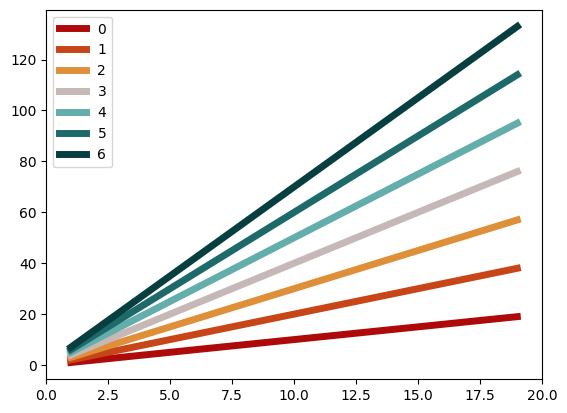

In [41]:
colors_1 = ['#ae0a0a', '#c74517', '#e08f39', '#c7b8b8', '#63adab', '#1e6a6a', '#073f40'] #['#580000', '#974013', '#dba164', '#d6d6d6', '#81bdbb', '#1e6b6a', '#003233']
colors_2 = ['#b35806','#f1a340','#fee0b6','#d8daeb','#998ec3','#542788']
colors_3 = ['#008c5c', '#33b983', '#002f64', '#0050ae', '#9b54f3', '#bf8cfc', '#680000', '#ac0000', '#c85b00', '#f98517']
x=range(1,20)
y=range(1,20)
i=1
for c in colors_1:
    plt.plot(x,np.array(y)*i,color=c, lw=5,label=i-1)
    i+=1

plt.xlim(0,20)
plt.legend()

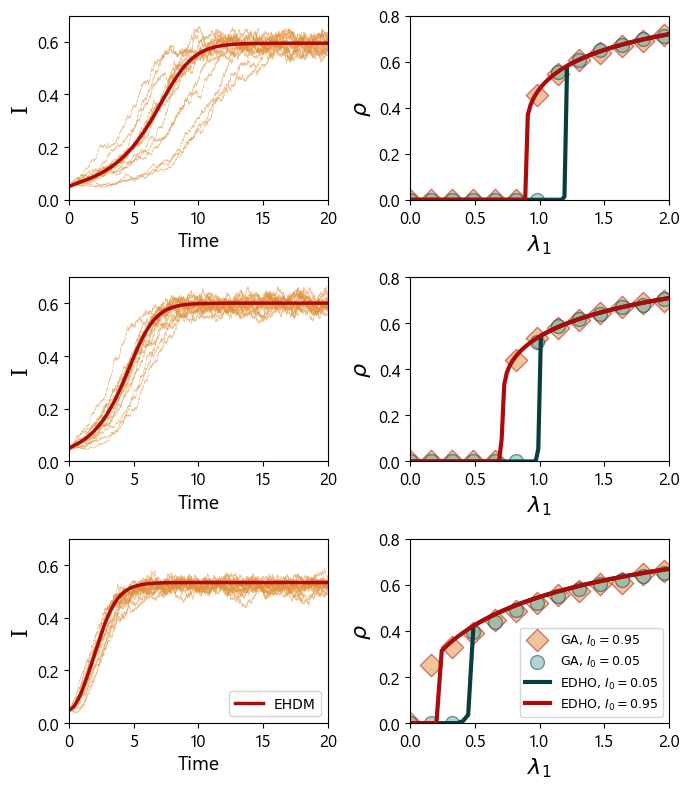

In [76]:
plt.rcParams['font.family'] = 'Segoe UI Variable' 
fig, ax = plt.subplots(3, 2, figsize=(7, 8))


plt.rcParams['font.family'] = 'Segoe UI Variable' 
j=0

N=1000
plt.rcParams['font.family'] = 'sans' 
color_sim=colors_1[2]
color_model=colors_1[0]
alfa=0.5
lws=0.3
rep=2
# Create figure
#fig.suptitle("Compact HO - effectibe degree model", fontsize=16, y=1.02)
lw_1=2.5
# ---------------- First subplot ---------------------------------------------------------------------------------------
#I_steady_states_1,I_steady_states_2,HO_effd1,HO_effd2,comp_HOeffd1,comp_HOeffd2 = Regular_result
i=0
times_runs, I_runs, S_runs =results_sim_reg1
for l in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[l], I_runs[l], S_runs[l]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    ax[i,j].plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa)


#plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
ax[i,j].plot(results_model_reg_compactHO[0],np.array(results_model_reg_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)

ax[i,j].set_xlabel('Time',fontsize=14)
ax[i,j].set_ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
ax[i,j].set_xlim((0,20))
ax[i,j].set_ylim((0,0.7))
ax[i,j].tick_params(axis='both', which='major', labelsize=12)
#plt.legend(fontsize=10)

#ax1.set_title(fr"Regular")#,  $ k_1  = $ {k1}, $ k_2  = $ {k2}")
i=1
# ---------------- Second subplot --------------------------------------------------------------------------------------
times_runs, I_runs, S_runs =results_sim_poi
for l in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim =  times_runs[l], I_runs[l], S_runs[l]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    ax[i,j].plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )


#plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
ax[i,j].plot(results_model_poi_compactHO[0],np.array(results_model_poi_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)
ax[i,j].set_ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
ax[i,j].set_xlabel('Time',fontsize=14)
ax[i,j].set_xlim((0,20))
ax[i,j].set_ylim((0,0.7))
ax[i,j].tick_params(axis='both', which='major', labelsize=12)

#plt.ylabel('Population')

#plt.legend(fontsize=10)
#ax2.set_title(fr"Poisson")#,  $\langle k_1 \rangle =$ {k1}, $\langle k_2 \rangle =$ {k2}")
i=2
# ---------------- Fourth subplot --------------------------------------------------------------------------------------
gam1=2.5; gam2=2.25
times_runs, I_runs, S_runs =results_sim_pow
for l in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[l], I_runs[l], S_runs[l]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    ax[i,j].plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )



#plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
ax[i,j].plot(results_model_pow_compactHO[0],np.array(results_model_pow_compactHO[2])/N,color=color_model, label='EHDM',lw=lw_1)
ax[i,j].set_ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
ax[i,j].set_xlabel('Time',fontsize=14)
ax[i,j].set_xlim((0,20))
ax[i,j].set_ylim((0,0.7))
ax[i,j].tick_params(axis='both', which='major', labelsize=12)
ax[i,j].legend(fontsize=10, loc = 'lower right')
#plt.ylabel('Population')




j=1
titles=['Regular', 'Poisson', 'Power-Law']
mean_sims1=[mean_reg_1,mean_poi_1,mean_pow_1]
mean_sims2=[mean_reg_2,mean_poi_2,mean_pow_2]
mean_fields_1 = [HOc_Reg_1,HOc_Poi_1,HOc_Pow_1]
mean_fields_2 = [HOc_Reg_2,HOc_Poi_2,HOc_Pow_2]
N=1000
nth_sim=4
for i in range(0,3):
    #ax[i].set_title(titles[i], fontsize=16)
    if i ==2:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    else:
        lambdas_sim=np.linspace(0,2,len(mean_sims1[i]))
        lambdas=np.linspace(0,2,len(mean_fields_1[i]))
    ax[i,j].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=130, facecolors=colors_1[2], alpha=0.5, edgecolors=colors_1[0],  label=r'GA, $I_0=0.95$')
    ax[i,j].scatter(lambdas_sim[::nth_sim],mean_sims1[i][::nth_sim]/N, s=100, facecolors=colors_1[4], alpha=0.5, edgecolors=colors_1[6], label=r'GA, $I_0=0.05$')
    #ax[i].scatter(lambdas_sim[::nth_sim],mean_sims2[i][::nth_sim]/N, marker='D',  s=100, facecolors='coral', alpha=0.3, edgecolors='darkred',  label=r'cedHO, $I_0=0.95$')
    ax[i,j].plot(lambdas,mean_fields_1[i]/N,color=colors_1[6],lw=3, label=r'EDHO, $I_0=0.05$')
    ax[i,j].plot(lambdas,mean_fields_2[i]/N,color=colors_1[0],lw=3, label=r'EDHO, $I_0=0.95$')
    ax[i,j].set_xlim((0,2))
    ax[i,j].set_xlabel(r'$\lambda_1$',fontsize=16)
    ax[i,j].set_ylabel(r'$\rho$', fontsize=16)
    ax[i,j].set_xlim((0,2))
    ax[i,j].set_ylim((0,0.8))
    ax[i,j].tick_params(axis='both', which='major', labelsize=12)
                      
    if i==2:
        ax[i,j].legend(fontsize=9)


plt.tight_layout()
plt.savefig('fig1_both.svg')

In [ ]:
plt.rcParams['font.family'] = 'Segoe UI Variable' 

import matplotlib.pyplot as plt
import numpy as np
N=1000
plt.rcParams['font.family'] = 'sans' 
color_sim=colors_1[2]
color_model=colors_1[0]
alfa=0.5
lws=0.3
rep=2
# Create figure
fig = plt.figure(figsize=(4, 8))
#fig.suptitle("Compact HO - effectibe degree model", fontsize=16, y=1.02)
lw_1=2.5
# ---------------- First subplot ---------------------------------------------------------------------------------------
ax1 = plt.subplot(3, 1, 1)
#I_steady_states_1,I_steady_states_2,HO_effd1,HO_effd2,comp_HOeffd1,comp_HOeffd2 = Regular_result

times_runs, I_runs, S_runs =results_sim_reg1
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa)


#plt.plot(results_model_reg_compactHO[0],results_model_reg_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_reg_compactHO[0],np.array(results_model_reg_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)

plt.xlabel('Time',fontsize=14)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.legend(fontsize=10)

#ax1.set_title(fr"Regular")#,  $ k_1  = $ {k1}, $ k_2  = $ {k2}")

# ---------------- Second subplot --------------------------------------------------------------------------------------
ax2 = plt.subplot(3, 1, 2)
times_runs, I_runs, S_runs =results_sim_poi
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )


#plt.plot(results_model_poi_compactHO[0],results_model_poi_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_poi_compactHO[0],np.array(results_model_poi_compactHO[2])/N,color=color_model, label='EDHO',lw=lw_1)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlabel('Time',fontsize=14)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#plt.ylabel('Population')

#plt.legend(fontsize=10)
#ax2.set_title(fr"Poisson")#,  $\langle k_1 \rangle =$ {k1}, $\langle k_2 \rangle =$ {k2}")

# ---------------- Fourth subplot --------------------------------------------------------------------------------------
ax4 = plt.subplot(3, 1, 3)
gam1=2.5; gam2=2.25
times_runs, I_runs, S_runs =results_sim_pow
for i in range(0,len(times_runs),rep):
    t_sim, I_sim, S_sim = times_runs[i], I_runs[i], S_runs[i]
    #plt.plot(t_sim,S_sim, color='skyblue', lw=0.3, alpha=0.2 )
    plt.plot(t_sim,np.array(I_sim)/N, color=color_sim, lw=lws, alpha=alfa )



#plt.plot(results_model_pow_compactHO[0],results_model_pow_compactHO[1],color='darkblue', label='HO comapct effd - S') 
plt.plot(results_model_pow_compactHO[0],np.array(results_model_pow_compactHO[2])/N,color=color_model, label='EHDM',lw=lw_1)
plt.ylabel(r'I',rotation=90,fontname='serif', fontsize=16)
plt.xlabel('Time',fontsize=14)
plt.xlim((0,20))
plt.ylim((0,0.7))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
#plt.ylabel('Population')


#ax4.set_title(fr"Power Law")#, $\gamma_1 = ${gam1}, $\gamma_2= ${gam2}")

# ---------------- One global legend ----------------------------------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()  # use labels from first plot
#fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.09, 0.5), fontsize=11)

# Adjust layout so legend fits
plt.tight_layout()